In [1]:
import pandas as pd

files = {
    "STATION HOURLY STATUS": "data/station_hourly_status.csv",
    "SWAP EVENTS": "data/swap_events.csv"
}

for name, path in files.items():

    print("\n" + "=" * 80)
    print(name)
    print("=" * 80)

    # Read only 5 rows — NOT the entire file
    df = pd.read_csv(path, nrows=5)

    print("\nNumber of columns:", len(df.columns))

    print("\nCOLUMN NAMES:")
    for i, col in enumerate(df.columns, 1):
        print(i, "->", col)

    print("\nSAMPLE DATA:")
    print(df.to_string(index=False))

    print("\nDATA TYPES:")
    print(df.dtypes)
    


STATION HOURLY STATUS

Number of columns: 14

COLUMN NAMES:
1 -> station_id
2 -> hour_start
3 -> charged_2w_avg
4 -> charged_2w_min
5 -> charged_3w_min
6 -> packs_charging
7 -> packs_quarantined
8 -> chargers_online
9 -> ambient_temp_c
10 -> cabinet_temp_c
11 -> avg_charge_minutes
12 -> outage_minutes
13 -> grid_kwh
14 -> telemetry_status

SAMPLE DATA:
 station_id          hour_start  charged_2w_avg  charged_2w_min  charged_3w_min  packs_charging  packs_quarantined  chargers_online  ambient_temp_c  cabinet_temp_c  avg_charge_minutes  outage_minutes  grid_kwh telemetry_status
STN-BLR-001 2024-01-01 00:00:00            6.29               6               4               1                  0               18             8.2            13.5                92.6               0      1.86               ok
STN-BLR-001 2024-01-01 01:00:00            8.10               8               4               8                  0               18             8.2            11.5                88.0       

In [2]:
import pandas as pd
import os

files = [
    "data/stations.csv",
    "data/riders.csv",
    "data/batteries.csv",
    "data/fleet_partners.csv",
    "data/support_tickets.csv",
    "data/city_daily_context.csv"
]

for path in files:

    print("\n" + "=" * 80)
    print(os.path.basename(path))
    print("=" * 80)

    df = pd.read_csv(path)

    print("Rows:", len(df))
    print("Columns:", len(df.columns))

    print("\nMissing values:")
    print(df.isnull().sum()[df.isnull().sum() > 0])

    print("\nDuplicate rows:", df.duplicated().sum())

    print("\nColumn types:")
    print(df.dtypes)

    print("\n" + "-" * 80)


stations.csv
Rows: 152
Columns: 22

Missing values:
decommissioned_date              151
competitor_within_1_5km_since    142
dtype: int64

Duplicate rows: 0

Column types:
station_id                        object
city                              object
zone                              object
latitude                         float64
longitude                        float64
location_type                     object
host_type                         object
commissioned_date                 object
decommissioned_date               object
expansion_wave                    object
charger_generation                object
slots_2w                           int64
slots_3w                           int64
inventory_target_2w                int64
inventory_target_3w                int64
monthly_rent_inr                   int64
monthly_maintenance_inr            int64
grid_tariff_inr_kwh              float64
connectivity_tier                 object
firmware_version                  object
firmwa

In [4]:
import pandas as pd
from collections import Counter

path = "data/swap_events.csv"

total_rows = 0
missing_counts = Counter()
event_types = Counter()
tariff_types = Counter()
payment_modes = Counter()
sync_modes = Counter()

min_date = None
max_date = None

duplicate_event_ids = 0
seen_event_ids = set()

for chunk in pd.read_csv(path, chunksize=100000):

    total_rows += len(chunk)

    # Missing values
    missing = chunk.isna().sum()
    missing_counts.update(chunk.isna().sum().to_dict())

    # Categories
    event_types.update(chunk["event_type"].dropna())
    tariff_types.update(chunk["tariff_code"].dropna())
    payment_modes.update(chunk["payment_mode"].dropna())
    sync_modes.update(chunk["sync_mode"].dropna())

    # Dates
    dates = pd.to_datetime(chunk["event_ts"], format="%Y-%m-%d %H:%M:%S", errors="coerce")

    chunk_min = dates.min()
    chunk_max = dates.max()

    if min_date is None or chunk_min < min_date:
        min_date = chunk_min

    if max_date is None or chunk_max > max_date:
        max_date = chunk_max

    # Duplicate event IDs
    event_ids = chunk["event_id"].dropna()
    duplicate_event_ids += len(event_ids) - len(set(event_ids) - seen_event_ids)
    seen_event_ids.update(event_ids)

print("\n" + "=" * 70)
print("SWAP EVENTS DATA QUALITY")
print("=" * 70)

print("\nTotal rows:", total_rows)

print("\nDate range:")
print("Minimum:", min_date)
print("Maximum:", max_date)

print("\nEvent types:")
print(event_types)

print("\nTariff types:")
print(tariff_types)

print("\nPayment modes:")
print(payment_modes)

print("\nSync modes:")
print(sync_modes)

print("\nMissing values:")
for col, count in missing_counts.items():
    if count > 0:
        percentage = count / total_rows * 100
        print(f"{col}: {count:,} ({percentage:.2f}%)")

print("\nDuplicate event IDs:", duplicate_event_ids)

C:\Users\himan\AppData\Local\Temp\ipykernel_19260\798640949.py:35: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dates = pd.to_datetime(chunk["event_ts"], errors="coerce")



SWAP EVENTS DATA QUALITY

Total rows: 3877013

Date range:
Minimum: 2024-01-01 00:00:33
Maximum: 2025-06-30 23:59:23

Event types:
Counter({'swap_completed': 3645809, 'failed_no_charged_battery': 134389, 'abandoned_queue': 68533, 'cancelled_by_rider': 16712, 'failed_system_error': 11570})

Tariff types:
Counter({'PARTNER': 2565478, 'STD': 1095936, 'PEAK': 177879, 'OFFPEAK': 37720})

Payment modes:
Counter({'partner_invoice': 3877013})

Sync modes:
Counter({'realtime': 3285899, 'offline_batch': 591114})

Missing values:
battery_in_id: 28,282 (0.73%)
battery_out_id: 231,204 (5.96%)
soc_in_pct: 28,282 (0.73%)
soh_in_pct: 28,282 (0.73%)
soc_out_pct: 231,204 (5.96%)
soh_out_pct: 231,204 (5.96%)
km_since_last_swap: 28,282 (0.73%)
energy_to_recharge_kwh: 231,204 (5.96%)

Duplicate event IDs: 0


In [5]:
import pandas as pd
from collections import Counter

path = "data/station_hourly_status.csv"

total_rows = 0
missing_counts = Counter()
telemetry_status = Counter()

min_date = None
max_date = None

for chunk in pd.read_csv(path, chunksize=100000):

    total_rows += len(chunk)

    # Missing values
    missing = chunk.isna().sum()
    for col, count in missing.items():
        missing_counts[col] += count

    # Telemetry status
    telemetry_status.update(
        chunk["telemetry_status"].dropna()
    )

    # Dates
    dates = pd.to_datetime(
        chunk["hour_start"],
        format="%Y-%m-%d %H:%M:%S",
        errors="coerce"
    )

    chunk_min = dates.min()
    chunk_max = dates.max()

    if min_date is None or chunk_min < min_date:
        min_date = chunk_min

    if max_date is None or chunk_max > max_date:
        max_date = chunk_max


print("\n" + "=" * 70)
print("STATION HOURLY STATUS DATA QUALITY")
print("=" * 70)

print("\nTotal rows:", total_rows)

print("\nDate range:")
print("Minimum:", min_date)
print("Maximum:", max_date)

print("\nTelemetry status:")
print(telemetry_status)

print("\nMissing values:")

for col, count in missing_counts.items():

    if count > 0:
        percentage = count / total_rows * 100
        print(f"{col}: {count:,} ({percentage:.2f}%)")


STATION HOURLY STATUS DATA QUALITY

Total rows: 1487712

Date range:
Minimum: 2024-01-01 00:00:00
Maximum: 2025-06-30 23:00:00

Telemetry status:
Counter({'ok': 1441341, 'partial': 36987, 'missing': 9384})

Missing values:
charged_2w_avg: 9,384 (0.63%)
charged_2w_min: 9,384 (0.63%)
charged_3w_min: 821,808 (55.24%)
packs_charging: 9,384 (0.63%)
packs_quarantined: 9,384 (0.63%)
ambient_temp_c: 9,384 (0.63%)
cabinet_temp_c: 9,384 (0.63%)
avg_charge_minutes: 9,384 (0.63%)
grid_kwh: 9,384 (0.63%)


In [6]:
import pandas as pd
from collections import Counter

base = r"C:\Users\himan\Downloads"

# ---------------------------------------------------------
# 1. LOAD MASTER / LOOKUP IDs
# ---------------------------------------------------------

riders = pd.read_csv(
    base + r"\riders.csv",
    usecols=["rider_id", "partner_id"]
)

stations = pd.read_csv(
    base + r"\stations.csv",
    usecols=["station_id"]
)

batteries = pd.read_csv(
    base + r"\batteries.csv",
    usecols=["battery_id"]
)

fleet_partners = pd.read_csv(
    base + r"\fleet_partners.csv",
    usecols=["partner_id"]
)

support = pd.read_csv(
    base + r"\support_tickets.csv",
    usecols=["rider_id", "station_id", "battery_id"]
)

# Convert IDs to sets for fast checking
rider_ids = set(riders["rider_id"].dropna())
station_ids = set(stations["station_id"].dropna())
battery_ids = set(batteries["battery_id"].dropna())
partner_ids = set(fleet_partners["partner_id"].dropna())

print("MASTER ID COUNTS")
print("----------------")
print("Riders:", len(rider_ids))
print("Stations:", len(station_ids))
print("Batteries:", len(battery_ids))
print("Fleet partners:", len(partner_ids))


# ---------------------------------------------------------
# 2. CHECK RIDERS -> FLEET PARTNERS
# ---------------------------------------------------------

rider_partner_values = set(
    riders["partner_id"].dropna()
)

missing_partners = rider_partner_values - partner_ids

print("\nRIDER -> PARTNER CHECK")
print("----------------------")
print("Unique partner IDs in riders:", len(rider_partner_values))
print("Partner IDs not found in fleet_partners:",
      len(missing_partners))

if missing_partners:
    print("Examples:", list(missing_partners)[:10])


# ---------------------------------------------------------
# 3. CHECK SUPPORT TICKETS
# ---------------------------------------------------------

print("\nSUPPORT TICKET RELATIONSHIPS")
print("----------------------------")

support_riders = set(support["rider_id"].dropna())
support_stations = set(support["station_id"].dropna())
support_batteries = set(support["battery_id"].dropna())

print("Unknown rider IDs:",
      len(support_riders - rider_ids))

print("Unknown station IDs:",
      len(support_stations - station_ids))

print("Unknown battery IDs:",
      len(support_batteries - battery_ids))


# ---------------------------------------------------------
# 4. CHECK SWAP EVENTS IN CHUNKS
# ---------------------------------------------------------

swap_path = base + r"\swap_events.csv"

unknown_riders = 0
unknown_stations = 0
unknown_battery_in = 0
unknown_battery_out = 0

total_swap_rows = 0

for chunk in pd.read_csv(
    swap_path,
    chunksize=100000,
    usecols=[
        "rider_id",
        "station_id",
        "battery_in_id",
        "battery_out_id"
    ]
):

    total_swap_rows += len(chunk)

    unknown_riders += (
        ~chunk["rider_id"].isin(rider_ids)
    ).sum()

    unknown_stations += (
        ~chunk["station_id"].isin(station_ids)
    ).sum()

    # Only check non-null battery IDs
    battery_in_mask = chunk["battery_in_id"].notna()

    unknown_battery_in += (
        battery_in_mask &
        ~chunk["battery_in_id"].isin(battery_ids)
    ).sum()

    battery_out_mask = chunk["battery_out_id"].notna()

    unknown_battery_out += (
        battery_out_mask &
        ~chunk["battery_out_id"].isin(battery_ids)
    ).sum()


print("\nSWAP EVENT RELATIONSHIPS")
print("------------------------")
print("Swap rows checked:", total_swap_rows)

print("Unknown rider references:",
      unknown_riders)

print("Unknown station references:",
      unknown_stations)

print("Unknown battery_in references:",
      unknown_battery_in)

print("Unknown battery_out references:",
      unknown_battery_out)


# ---------------------------------------------------------
# 5. CHECK STATION HOURLY STATUS
# ---------------------------------------------------------

status_path = base + r"\station_hourly_status.csv"

unknown_status_stations = 0
total_status_rows = 0

for chunk in pd.read_csv(
    status_path,
    chunksize=100000,
    usecols=["station_id"]
):

    total_status_rows += len(chunk)

    unknown_status_stations += (
        ~chunk["station_id"].isin(station_ids)
    ).sum()


print("\nSTATION HOURLY STATUS RELATIONSHIP")
print("----------------------------------")
print("Rows checked:", total_status_rows)

print("Unknown station references:",
      unknown_status_stations)

MASTER ID COUNTS
----------------
Riders: 20000
Stations: 152
Batteries: 6500
Fleet partners: 12

RIDER -> PARTNER CHECK
----------------------
Unique partner IDs in riders: 12
Partner IDs not found in fleet_partners: 0

SUPPORT TICKET RELATIONSHIPS
----------------------------
Unknown rider IDs: 0
Unknown station IDs: 0
Unknown battery IDs: 0

SWAP EVENT RELATIONSHIPS
------------------------
Swap rows checked: 3877013
Unknown rider references: 0
Unknown station references: 0
Unknown battery_in references: 0
Unknown battery_out references: 0

STATION HOURLY STATUS RELATIONSHIP
----------------------------------
Rows checked: 1487712
Unknown station references: 0


In [7]:
import pandas as pd

base = r"C:\Users\himan\Downloads"

stations = pd.read_csv(base + r"\stations.csv")
batteries = pd.read_csv(base + r"\batteries.csv")

print("STATION ECONOMICS")
print("=================")

print(stations[
    [
        "station_id",
        "monthly_rent_inr",
        "monthly_maintenance_inr",
        "grid_tariff_inr_kwh"
    ]
].head(10).to_string(index=False))

print("\n\nBATTERY ECONOMICS")
print("=================")

print(batteries[
    [
        "battery_id",
        "pack_type",
        "supplier",
        "purchase_cost_inr",
        "rated_capacity_kwh",
        "initial_soh_pct",
        "current_soh_pct"
    ]
].head(10).to_string(index=False))

STATION ECONOMICS
 station_id  monthly_rent_inr  monthly_maintenance_inr  grid_tariff_inr_kwh
STN-BLR-001             23247                     5436                 9.29
STN-BLR-002             23201                     5249                 8.41
STN-BLR-003             10281                     4516                 8.66
STN-BLR-004             12322                     5802                 9.19
STN-BLR-005             24194                     7134                 8.68
STN-BLR-006              9862                     5894                 8.66
STN-BLR-007             11986                     6669                 9.92
STN-BLR-008             10714                     6394                 8.74
STN-BLR-009             20679                     6553                 9.34
STN-BLR-010             18240                     6780                 9.22


BATTERY ECONOMICS
   battery_id pack_type supplier  purchase_cost_inr  rated_capacity_kwh  initial_soh_pct  current_soh_pct
BAT-2W-100000 2W_2.1

In [9]:
import pandas as pd

base = r"C:\Users\himan\Downloads"

# Load station electricity tariffs
stations = pd.read_csv(
    base + r"\stations.csv",
    usecols=["station_id", "grid_tariff_inr_kwh"]
)

# Make station_id the index for fast lookup
station_tariff = stations.set_index("station_id")["grid_tariff_inr_kwh"]

# Store monthly results here
monthly = []

swap_path = base + r"\swap_events.csv"

for chunk in pd.read_csv(
    swap_path,
    chunksize=100000,
    usecols=[
        "event_id",
        "station_id",
        "event_ts",
        "event_type",
        "amount_charged_inr",
        "energy_to_recharge_kwh"
    ]
):

    # Convert timestamp
    

    # Create month
    chunk["month"] = chunk["event_ts"].str[:7]

    # Add station electricity tariff
    chunk["grid_tariff_inr_kwh"] = (
        chunk["station_id"].map(station_tariff)
    )

    # Direct energy cost
    chunk["energy_cost_inr"] = (
        chunk["energy_to_recharge_kwh"] *
        chunk["grid_tariff_inr_kwh"]
    )

    # Event flags
    chunk["completed"] = (
        chunk["event_type"] == "swap_completed"
    )

    chunk["no_battery_failure"] = (
        chunk["event_type"] == "failed_no_charged_battery"
    )

    chunk["system_failure"] = (
        chunk["event_type"] == "failed_system_error"
    )

    chunk["abandoned"] = (
        chunk["event_type"] == "abandoned_queue"
    )

    chunk["cancelled"] = (
        chunk["event_type"] == "cancelled_by_rider"
    )

    # Contribution
    chunk["contribution_inr"] = (
        chunk["amount_charged_inr"].fillna(0)
        - chunk["energy_cost_inr"].fillna(0)
    )

    # Aggregate this chunk by month
    result = chunk.groupby("month").agg(
        attempts=("event_id", "count"),
        completed_swaps=("completed", "sum"),
        no_battery_failures=("no_battery_failure", "sum"),
        system_failures=("system_failure", "sum"),
        abandoned_swaps=("abandoned", "sum"),
        cancelled_swaps=("cancelled", "sum"),
        revenue_inr=("amount_charged_inr", "sum"),
        energy_cost_inr=("energy_cost_inr", "sum"),
        contribution_inr=("contribution_inr", "sum")
    )

    monthly.append(result)

# Combine all chunks
monthly = pd.concat(monthly)

# Combine months again because each month appears in multiple chunks
monthly = monthly.groupby(monthly.index).sum()

# Calculate rates
monthly["no_battery_failure_rate_pct"] = (
    monthly["no_battery_failures"] /
    monthly["attempts"] * 100
)

monthly["system_failure_rate_pct"] = (
    monthly["system_failures"] /
    monthly["attempts"] * 100
)

monthly["abandonment_rate_pct"] = (
    monthly["abandoned_swaps"] /
    monthly["attempts"] * 100
)

monthly["cancellation_rate_pct"] = (
    monthly["cancelled_swaps"] /
    monthly["attempts"] * 100
)

monthly["contribution_per_completed_swap_inr"] = (
    monthly["contribution_inr"] /
    monthly["completed_swaps"]
)

# Sort chronologically
monthly = monthly.sort_index()

# Display
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

print(monthly.round(2).to_string())

         attempts  completed_swaps  no_battery_failures  system_failures  abandoned_swaps  cancelled_swaps  revenue_inr  energy_cost_inr  contribution_inr  no_battery_failure_rate_pct  system_failure_rate_pct  abandonment_rate_pct  cancellation_rate_pct  contribution_per_completed_swap_inr
month                                                                                                                                                                                                                                                                                             
2024-01    110348           105490                 2690              318             1405              445   6318995.20       2320971.24        3998023.96                         2.44                     0.29                  1.27                   0.40                                37.90
2024-02    111531           106582                 2681              346             1451              471   6387614.80       2

In [10]:
import pandas as pd

base = r"C:\Users\himan\Downloads"

# Load station -> city mapping
stations = pd.read_csv(
    base + r"\stations.csv",
    usecols=["station_id", "city"]
)

station_city = stations.set_index("station_id")["city"]

monthly_city = []

for chunk in pd.read_csv(
    base + r"\swap_events.csv",
    chunksize=100000,
    usecols=[
        "station_id",
        "event_ts",
        "event_type"
    ]
):

    

    chunk["month"] = chunk["event_ts"].str[:7]

    # Map station to city
    chunk["city"] = chunk["station_id"].map(station_city)

    # Event flags
    chunk["completed"] = (
        chunk["event_type"] == "swap_completed"
    )

    chunk["no_battery_failure"] = (
        chunk["event_type"] == "failed_no_charged_battery"
    )

    chunk["system_failure"] = (
        chunk["event_type"] == "failed_system_error"
    )

    chunk["abandoned"] = (
        chunk["event_type"] == "abandoned_queue"
    )

    # Aggregate
    result = chunk.groupby(
        ["month", "city"]
    ).agg(
        attempts=("event_type", "size"),
        completed=("completed", "sum"),
        no_battery_failures=("no_battery_failure", "sum"),
        system_failures=("system_failure", "sum"),
        abandoned=("abandoned", "sum")
    )

    monthly_city.append(result)

# Combine chunks
monthly_city = pd.concat(monthly_city)

monthly_city = (
    monthly_city
    .groupby(["month", "city"])
    .sum()
)

# Calculate rates
monthly_city["no_battery_failure_rate_pct"] = (
    monthly_city["no_battery_failures"]
    / monthly_city["attempts"]
    * 100
)

monthly_city["system_failure_rate_pct"] = (
    monthly_city["system_failures"]
    / monthly_city["attempts"]
    * 100
)

monthly_city["abandonment_rate_pct"] = (
    monthly_city["abandoned"]
    / monthly_city["attempts"]
    * 100
)

# Sort
monthly_city = monthly_city.sort_index()

print(
    monthly_city.round(2).to_string()
)

                   attempts  completed  no_battery_failures  system_failures  abandoned  no_battery_failure_rate_pct  system_failure_rate_pct  abandonment_rate_pct
month   city                                                                                                                                                       
2024-01 Bengaluru     23153      22151                  554               65        305                         2.39                     0.28                  1.32
        Delhi NCR     20145      19271                  465               62        262                         2.31                     0.31                  1.30
        Hyderabad     19798      18912                  507               54        245                         2.56                     0.27                  1.24
        Jaipur        13594      13022                  320               41        159                         2.35                     0.30                  1.17
        Mumbai  

In [11]:
import pandas as pd

base = r"C:\Users\himan\Downloads"

# Station metadata
stations = pd.read_csv(
    base + r"\stations.csv"
)

# Keep useful station information
station_info = stations[
    [
        "station_id",
        "city",
        "zone",
        "location_type",
        "host_type",
        "commissioned_date",
        "expansion_wave",
        "charger_generation",
        "slots_2w",
        "slots_3w",
        "inventory_target_2w",
        "inventory_target_3w"
    ]
].copy()

station_results = []

for chunk in pd.read_csv(
    base + r"\swap_events.csv",
    chunksize=100000,
    usecols=[
        "station_id",
        "event_type",
        "queue_wait_sec"
    ]
):

    chunk["completed"] = (
        chunk["event_type"] == "swap_completed"
    )

    chunk["no_battery_failure"] = (
        chunk["event_type"] == "failed_no_charged_battery"
    )

    chunk["system_failure"] = (
        chunk["event_type"] == "failed_system_error"
    )

    chunk["abandoned"] = (
        chunk["event_type"] == "abandoned_queue"
    )

    result = chunk.groupby("station_id").agg(
        attempts=("event_type", "size"),
        completed_swaps=("completed", "sum"),
        no_battery_failures=("no_battery_failure", "sum"),
        system_failures=("system_failure", "sum"),
        abandoned_swaps=("abandoned", "sum"),
        avg_queue_wait_sec=("queue_wait_sec", "mean")
    )

    station_results.append(result)

# Combine chunks
station_results = pd.concat(station_results)

station_results = (
    station_results
    .groupby("station_id")
    .agg({
        "attempts": "sum",
        "completed_swaps": "sum",
        "no_battery_failures": "sum",
        "system_failures": "sum",
        "abandoned_swaps": "sum",
        "avg_queue_wait_sec": "mean"
    })
)

# Calculate rates
station_results["no_battery_failure_rate_pct"] = (
    station_results["no_battery_failures"]
    / station_results["attempts"]
    * 100
)

station_results["abandonment_rate_pct"] = (
    station_results["abandoned_swaps"]
    / station_results["attempts"]
    * 100
)

# Join station metadata
station_results = station_results.reset_index()

station_results = station_results.merge(
    station_info,
    on="station_id",
    how="left"
)

# Sort by failure rate
station_results = station_results.sort_values(
    "no_battery_failure_rate_pct",
    ascending=False
)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 250)

print(
    station_results.head(30).round(2).to_string(index=False)
)

 station_id  attempts  completed_swaps  no_battery_failures  system_failures  abandoned_swaps  avg_queue_wait_sec  no_battery_failure_rate_pct  abandonment_rate_pct      city               zone  location_type     host_type commissioned_date expansion_wave charger_generation  slots_2w  slots_3w  inventory_target_2w  inventory_target_3w
STN-DEL-037     30838            28039                 1728               95              854              242.96                         5.60                  2.77 Delhi NCR          DEL-Noida commercial_hub     owned_lot        2023-06-12         Launch               Gen1        16         0                   22                    0
STN-DEL-048     34646            31535                 1894               97              962              243.86                         5.47                  2.78 Delhi NCR           DEL-West         market     owned_lot        2023-09-07         Launch               Gen1        16         0                   27           

In [12]:
 # ============================================================
# STATION CHARACTERISTIC ANALYSIS
# ============================================================

group_columns = [
    "city",
    "charger_generation",
    "expansion_wave",
    "location_type",
    "host_type"
]

for col in group_columns:

    print("\n" + "=" * 80)
    print(f"FAILURE RATE BY {col.upper()}")
    print("=" * 80)

    result = (
        station_results
        .groupby(col)
        .agg(
            stations=("station_id", "nunique"),
            attempts=("attempts", "sum"),
            no_battery_failures=("no_battery_failures", "sum"),
            abandoned=("abandoned_swaps", "sum"),
            avg_queue_wait_sec=("avg_queue_wait_sec", "mean")
        )
    )

    result["no_battery_failure_rate_pct"] = (
        result["no_battery_failures"]
        / result["attempts"]
        * 100
    )

    result["abandonment_rate_pct"] = (
        result["abandoned"]
        / result["attempts"]
        * 100
    )

    print(result.round(2).sort_values(
        "no_battery_failure_rate_pct",
        ascending=False
    ).to_string())


FAILURE RATE BY CITY
           stations  attempts  no_battery_failures  abandoned  avg_queue_wait_sec  no_battery_failure_rate_pct  abandonment_rate_pct
city                                                                                                                                
Jaipur           18    487634                23303      11518              243.49                         4.78                  2.36
Delhi NCR        30    768913                33892      17030              242.81                         4.41                  2.21
Hyderabad        26    711930                28274      14158              242.95                         3.97                  1.99
Pune             22    552910                15480       8081              243.15                         2.80                  1.46
Bengaluru        34    825327                20602      10919              242.92                         2.50                  1.32
Mumbai           22    530299                12

In [13]:
print("\n" + "=" * 80)
print("CITY × CHARGER GENERATION")
print("=" * 80)

city_gen = (
    station_results
    .groupby(["city", "charger_generation"])
    .agg(
        stations=("station_id", "nunique"),
        attempts=("attempts", "sum"),
        no_battery_failures=("no_battery_failures", "sum"),
        abandoned=("abandoned_swaps", "sum"),
        avg_queue_wait_sec=("avg_queue_wait_sec", "mean")
    )
)

city_gen["no_battery_failure_rate_pct"] = (
    city_gen["no_battery_failures"]
    / city_gen["attempts"]
    * 100
)

city_gen["abandonment_rate_pct"] = (
    city_gen["abandoned"]
    / city_gen["attempts"]
    * 100
)

print(
    city_gen.round(2).to_string()
)


CITY × CHARGER GENERATION
                              stations  attempts  no_battery_failures  abandoned  avg_queue_wait_sec  no_battery_failure_rate_pct  abandonment_rate_pct
city      charger_generation                                                                                                                           
Bengaluru Gen1                       9    307640                 7875       4178              242.85                         2.56                  1.36
          Gen2                      18    470533                11561       6127              243.00                         2.46                  1.30
          Gen3                       7     47154                 1166        614              242.79                         2.47                  1.30
Delhi NCR Gen1                      13    456390                23853      11741              242.68                         5.23                  2.57
          Gen2                      10    236060             

In [16]:
import pandas as pd

station_file = "data/station_hourly_status.csv"
swap_file = "data/swap_events.csv"

# ============================================================
# 1. HOURLY STATION DATA
# ============================================================

hourly_parts = []

for chunk in pd.read_csv(
    station_file,
    usecols=[
        "station_id",
        "hour_start",
        "charged_2w_min",
        "charged_2w_avg",
        "packs_charging",
        "packs_quarantined",
        "chargers_online"
    ],
    chunksize=200_000
):
    chunk["is_low_battery"] = chunk["charged_2w_min"] <= 2

    chunk["month"] = chunk["hour_start"].str[:7]

    hourly_parts.append(chunk)

hourly = pd.concat(hourly_parts, ignore_index=True)

print("Hourly rows loaded:", len(hourly))


# ============================================================
# 2. SWAP EVENTS
# ============================================================

swap_parts = []

for chunk in pd.read_csv(
    swap_file,
    usecols=["station_id", "event_ts", "event_type"],
    chunksize=200_000
):
    

    chunk["month"] = chunk["event_ts"].str[:7].astype(str)

    # Only keep failed-no-battery events
    chunk = chunk[
        chunk["event_type"] == "failed_no_charged_battery"
    ]

    swap_parts.append(
        chunk[["station_id", "month"]]
    )

no_battery = pd.concat(swap_parts, ignore_index=True)

print("No-battery failures loaded:", len(no_battery))


# ============================================================
# 3. COUNT NO-BATTERY FAILURES
# ============================================================

failure_counts = (
    no_battery
    .groupby(["station_id", "month"])
    .size()
    .reset_index(name="no_battery_failures")
)


# ============================================================
# 4. SUMMARIZE BATTERY AVAILABILITY
# ============================================================

hourly_summary = (
    hourly
    .groupby(["station_id", "month"])
    .agg(
        avg_charged_2w_min=("charged_2w_min", "mean"),
        min_charged_2w_min=("charged_2w_min", "min"),
        avg_charged_2w=("charged_2w_avg", "mean"),
        avg_packs_charging=("packs_charging", "mean"),
        avg_packs_quarantined=("packs_quarantined", "mean"),
        avg_chargers_online=("chargers_online", "mean"),
        low_battery_hours=("is_low_battery", "sum"),
        total_hours=(
            "charged_2w_min",
            "count"
        )
    )
    .reset_index()
)

hourly_summary["low_battery_hour_pct"] = (
    hourly_summary["low_battery_hours"]
    / hourly_summary["total_hours"]
    * 100
)


# ============================================================
# 5. MERGE
# ============================================================

analysis = hourly_summary.merge(
    failure_counts,
    on=["station_id", "month"],
    how="left"
)

analysis["no_battery_failures"] = (
    analysis["no_battery_failures"]
    .fillna(0)
)


# ============================================================
# 6. SHOW RESULT
# ============================================================

print("\n" + "=" * 90)
print("BATTERY AVAILABILITY vs NO-BATTERY FAILURES")
print("=" * 90)

print(
    analysis.sort_values(
        "no_battery_failures",
        ascending=False
    ).head(30).to_string(index=False)
)

Hourly rows loaded: 1487712
No-battery failures loaded: 134389

BATTERY AVAILABILITY vs NO-BATTERY FAILURES
 station_id   month  avg_charged_2w_min  min_charged_2w_min  avg_charged_2w  avg_packs_charging  avg_packs_quarantined  avg_chargers_online  low_battery_hours  total_hours  low_battery_hour_pct  no_battery_failures
STN-HYD-072 2025-05            5.280914                 0.0        6.773065            3.633065               0.002688            11.990591                173          744             23.252688                629.0
STN-DEL-050 2025-05            4.575672                 0.0        5.925516            3.715700               0.001414            11.989247                237          707             33.521924                494.0
STN-HYD-070 2025-05            7.321237                 0.0        8.766532            6.569892               0.010753            21.990591                114          744             15.322581                474.0
STN-DEL-043 2025-06            5

In [17]:
print("\n" + "=" * 90)
print("CORRELATION ANALYSIS")
print("=" * 90)

cols = [
    "avg_charged_2w_min",
    "avg_charged_2w",
    "avg_packs_charging",
    "avg_packs_quarantined",
    "avg_chargers_online",
    "low_battery_hour_pct",
    "no_battery_failures"
]

print(
    analysis[cols]
    .corr()["no_battery_failures"]
    .sort_values(ascending=False)
)


CORRELATION ANALYSIS
no_battery_failures      1.000000
avg_packs_quarantined    0.549811
low_battery_hour_pct     0.429135
avg_packs_charging       0.024884
avg_chargers_online      0.022322
avg_charged_2w_min      -0.141256
avg_charged_2w          -0.147388
Name: no_battery_failures, dtype: float64


In [18]:
# ============================================================
# STEP 7 — FAILURE RATE vs BATTERY AVAILABILITY
# ============================================================

# Count ALL swap attempts by station and month
attempt_parts = []

for chunk in pd.read_csv(
    swap_file,
    usecols=["station_id", "event_ts"],
    chunksize=200_000
):
    

    chunk["month"] = chunk["event_ts"].str[:7].astype(str)

    attempts = (
        chunk
        .groupby(["station_id", "month"])
        .size()
        .reset_index(name="attempts")
    )

    attempt_parts.append(attempts)


attempt_counts = (
    pd.concat(attempt_parts, ignore_index=True)
    .groupby(["station_id", "month"])["attempts"]
    .sum()
    .reset_index()
)


# ------------------------------------------------------------
# Merge attempts with our previous analysis
# ------------------------------------------------------------

failure_rate_analysis = analysis.merge(
    attempt_counts,
    on=["station_id", "month"],
    how="left"
)


# Calculate failure rate
failure_rate_analysis["no_battery_failure_rate_pct"] = (
    failure_rate_analysis["no_battery_failures"]
    / failure_rate_analysis["attempts"]
    * 100
)


# ------------------------------------------------------------
# Show highest failure-rate station/month combinations
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("HIGHEST NO-BATTERY FAILURE RATE")
print("=" * 100)

cols = [
    "station_id",
    "month",
    "attempts",
    "no_battery_failures",
    "no_battery_failure_rate_pct",
    "avg_charged_2w_min",
    "avg_charged_2w",
    "low_battery_hour_pct",
    "avg_packs_charging",
    "avg_packs_quarantined",
    "avg_chargers_online"
]

print(
    failure_rate_analysis
    .sort_values(
        "no_battery_failure_rate_pct",
        ascending=False
    )
    [cols]
    .head(30)
    .to_string(index=False)
)


HIGHEST NO-BATTERY FAILURE RATE
 station_id   month  attempts  no_battery_failures  no_battery_failure_rate_pct  avg_charged_2w_min  avg_charged_2w  low_battery_hour_pct  avg_packs_charging  avg_packs_quarantined  avg_chargers_online
STN-DEL-049 2024-05      1003                152.0                    15.154536            2.665323        3.949987             49.059140            4.135753               0.005376            13.975806
STN-DEL-039 2024-05      1429                200.0                    13.995801            4.629032        5.969140             33.870968            3.611559               0.001344            11.987903
STN-JAI-139 2024-05      1645                230.0                    13.981763            6.426003        7.796722             29.598893            4.731674               0.000000            15.977151
STN-HYD-073 2025-05      1961                273.0                    13.921469            5.198925        6.651492             23.790323            4.806452  

In [19]:
# ============================================================
# STEP 8 — FAILURE RATE vs CITY CONTEXT
# ============================================================

context_file = "data/city_daily_context.csv"

context = pd.read_csv(context_file)

context["date"] = pd.to_datetime(
    context["date"],
    format="%Y-%m-%d",
    errors="coerce"
)

context["month"] = context["date"].dt.to_period("M").astype(str)

monthly_context = (
    context
    .groupby(["city", "month"])
    .agg(
        avg_max_temp_c=("max_temp_c", "mean"),
        total_rainfall_mm=("rainfall_mm", "sum"),
        heat_alert_days=("heat_alert", "sum"),
        flood_days=("flood_disruption", "sum"),
        public_holiday_days=("is_public_holiday", "sum"),
        grid_outage_hours=("grid_outage_hours", "sum"),
        competitor_promo_days=("competitor_promo_active", "sum"),
        ecommerce_sale_days=("ecommerce_sale_event", "sum"),
        festival_days=("festival_or_event", lambda x: x.notna().sum())
    )
    .reset_index()
)

print("\n" + "=" * 100)
print("MONTHLY CITY CONTEXT")
print("=" * 100)

print(
    monthly_context[
        monthly_context["month"].isin(
            ["2024-05", "2024-06", "2025-05", "2025-06"]
        )
    ].to_string(index=False)
)


MONTHLY CITY CONTEXT
     city   month  avg_max_temp_c  total_rainfall_mm  heat_alert_days  flood_days  public_holiday_days  grid_outage_hours  competitor_promo_days  ecommerce_sale_days  festival_days
Bengaluru 2024-05       34.741935               11.4                0           0                    0                2.1                      0                    0              0
Bengaluru 2024-06       31.726667              410.5                0           0                    0                1.5                      0                    0              0
Bengaluru 2025-05       34.467742               13.2                0           0                    0                2.9                      0                    0              0
Bengaluru 2025-06       32.466667              245.7                0           0                    0                2.4                      0                    0              0
Delhi NCR 2024-05       44.922581               18.3               30    

In [29]:
# ============================================================
# STEP 9 — ADD CITY TO FAILURE DATA
# ============================================================

station_city = station_info[
    ["station_id", "city"]
].drop_duplicates()

city_failure = failure_rate_analysis.merge(
    station_city,
    on="station_id",
    how="left"
)

# Make month format identical
city_failure["month"] = city_failure["month"].astype(str)
monthly_context["month"] = monthly_context["month"].astype(str)

print("City added successfully!")
print(city_failure.columns.tolist())

print("\nFirst 5 rows:")
print(city_failure.head())

City added successfully!
['station_id', 'month', 'avg_charged_2w_min', 'min_charged_2w_min', 'avg_charged_2w', 'avg_packs_charging', 'avg_packs_quarantined', 'avg_chargers_online', 'low_battery_hours', 'total_hours', 'low_battery_hour_pct', 'no_battery_failures', 'attempts', 'no_battery_failure_rate_pct', 'city']

First 5 rows:
    station_id    month  avg_charged_2w_min  min_charged_2w_min  avg_charged_2w  avg_packs_charging  avg_packs_quarantined  avg_chargers_online  low_battery_hours  total_hours  low_battery_hour_pct  no_battery_failures  attempts  \
0  STN-BLR-001  2024-01            6.168011                 0.0        7.733266            5.220430                    0.0            17.983871                 41          744              5.510753                 20.0       762   
1  STN-BLR-001  2024-02            6.186782                 0.0        7.723118            5.415230                    0.0            17.987069                 34          696              4.885057         

In [21]:
# Show all DataFrames currently available
[df_name for df_name, df_obj in globals().items()
 if isinstance(df_obj, pd.DataFrame)]

['df',
 'chunk',
 'riders',
 'stations',
 'batteries',
 'fleet_partners',
 'support',
 'monthly',
 'result',
 'monthly_city',
 'station_info',
 'station_results',
 'city_gen',
 'hourly',
 'no_battery',
 'failure_counts',
 'hourly_summary',
 'analysis',
 'attempts',
 'attempt_counts',
 'failure_rate_analysis',
 'context',
 'monthly_context']

In [23]:
print("failure_rate_analysis columns:")
print(failure_rate_analysis.columns.tolist())

print("\nIndex:")
print(failure_rate_analysis.index)

print("\nFirst 5 rows:")
print(failure_rate_analysis.head())

failure_rate_analysis columns:
['station_id', 'month', 'avg_charged_2w_min', 'min_charged_2w_min', 'avg_charged_2w', 'avg_packs_charging', 'avg_packs_quarantined', 'avg_chargers_online', 'low_battery_hours', 'total_hours', 'low_battery_hour_pct', 'no_battery_failures', 'attempts', 'no_battery_failure_rate_pct']

Index:
RangeIndex(start=0, stop=2073, step=1)

First 5 rows:
    station_id    month  avg_charged_2w_min  min_charged_2w_min  avg_charged_2w  avg_packs_charging  avg_packs_quarantined  avg_chargers_online  low_battery_hours  total_hours  low_battery_hour_pct  no_battery_failures  attempts  \
0  STN-BLR-001  2024-01            6.168011                 0.0        7.733266            5.220430                    0.0            17.983871                 41          744              5.510753                 20.0       762   
1  STN-BLR-001  2024-02            6.186782                 0.0        7.723118            5.415230                    0.0            17.987069                 3

In [24]:
# ============================================================
# STEP 9 — ADD CITY TO FAILURE DATA
# ============================================================

# Check station_info columns first
print(station_info.columns.tolist())

['station_id', 'city', 'zone', 'location_type', 'host_type', 'commissioned_date', 'expansion_wave', 'charger_generation', 'slots_2w', 'slots_3w', 'inventory_target_2w', 'inventory_target_3w']


In [25]:
# Keep only station_id and city
station_city = station_info[["station_id", "city"]].drop_duplicates()

# Add city to failure_rate_analysis
city_failure = failure_rate_analysis.merge(
    station_city,
    on="station_id",
    how="left"
)

# Make sure month formats match
city_failure["month"] = city_failure["month"].astype(str)
monthly_context["month"] = monthly_context["month"].astype(str)

print(city_failure.columns.tolist())
print(city_failure.head())

['station_id', 'month', 'avg_charged_2w_min', 'min_charged_2w_min', 'avg_charged_2w', 'avg_packs_charging', 'avg_packs_quarantined', 'avg_chargers_online', 'low_battery_hours', 'total_hours', 'low_battery_hour_pct', 'no_battery_failures', 'attempts', 'no_battery_failure_rate_pct', 'city']
    station_id    month  avg_charged_2w_min  min_charged_2w_min  avg_charged_2w  avg_packs_charging  avg_packs_quarantined  avg_chargers_online  low_battery_hours  total_hours  low_battery_hour_pct  no_battery_failures  attempts  \
0  STN-BLR-001  2024-01            6.168011                 0.0        7.733266            5.220430                    0.0            17.983871                 41          744              5.510753                 20.0       762   
1  STN-BLR-001  2024-02            6.186782                 0.0        7.723118            5.415230                    0.0            17.987069                 34          696              4.885057                 18.0       792   
2  STN-BLR-001

In [32]:
# ============================================================
# STEP 10 — COMBINE FAILURE DATA WITH CITY CONTEXT
# ============================================================

failure_context = city_failure.merge(
    monthly_context,
    on=["city", "month"],
    how="left"
)

print("Merged successfully!")

print("\nColumns:")
print(failure_context.columns.tolist())

print("\nFirst 10 rows:")
print(
    failure_context[
        [
            "station_id",
            "city",
            "month",
            "no_battery_failure_rate_pct",
            "low_battery_hour_pct",
            "avg_max_temp_c",
            "total_rainfall_mm",
            "heat_alert_days",
            "flood_days",
            "grid_outage_hours"
        ]
    ].head(10).to_string(index=False)
)

Merged successfully!

Columns:
['station_id', 'month', 'avg_charged_2w_min', 'min_charged_2w_min', 'avg_charged_2w', 'avg_packs_charging', 'avg_packs_quarantined', 'avg_chargers_online', 'low_battery_hours', 'total_hours', 'low_battery_hour_pct', 'no_battery_failures', 'attempts', 'no_battery_failure_rate_pct', 'city', 'avg_max_temp_c', 'total_rainfall_mm', 'heat_alert_days', 'flood_days', 'public_holiday_days', 'grid_outage_hours', 'competitor_promo_days', 'ecommerce_sale_days', 'festival_days']

First 10 rows:
 station_id      city   month  no_battery_failure_rate_pct  low_battery_hour_pct  avg_max_temp_c  total_rainfall_mm  heat_alert_days  flood_days  grid_outage_hours
STN-BLR-001 Bengaluru 2024-01                     2.624672              5.510753       16.780645               31.7                0           0                3.3
STN-BLR-001 Bengaluru 2024-02                     2.272727              4.885057       18.586207               18.5                0           0          

In [30]:
print(city_failure["city"].isna().sum())

0


In [33]:
# Check whether city context matched successfully

print(
    failure_context[
        [
            "avg_max_temp_c",
            "total_rainfall_mm",
            "heat_alert_days",
            "grid_outage_hours"
        ]
    ].isna().sum()
)

avg_max_temp_c       0
total_rainfall_mm    0
heat_alert_days      0
grid_outage_hours    0
dtype: int64


In [34]:
# ============================================================
# STEP 11 — FAILURE RATE vs CITY CONTEXT CORRELATION
# ============================================================

context_columns = [
    "avg_max_temp_c",
    "total_rainfall_mm",
    "heat_alert_days",
    "flood_days",
    "grid_outage_hours"
]

correlation = failure_context[
    ["no_battery_failure_rate_pct"] + context_columns
].corr()["no_battery_failure_rate_pct"].sort_values(
    ascending=False
)

print("\n" + "=" * 90)
print("FAILURE RATE vs CITY CONTEXT — CORRELATION")
print("=" * 90)

print(correlation)


FAILURE RATE vs CITY CONTEXT — CORRELATION
no_battery_failure_rate_pct    1.000000
avg_max_temp_c                 0.645156
grid_outage_hours              0.588315
heat_alert_days                0.566507
total_rainfall_mm             -0.053920
flood_days                    -0.061684
Name: no_battery_failure_rate_pct, dtype: float64


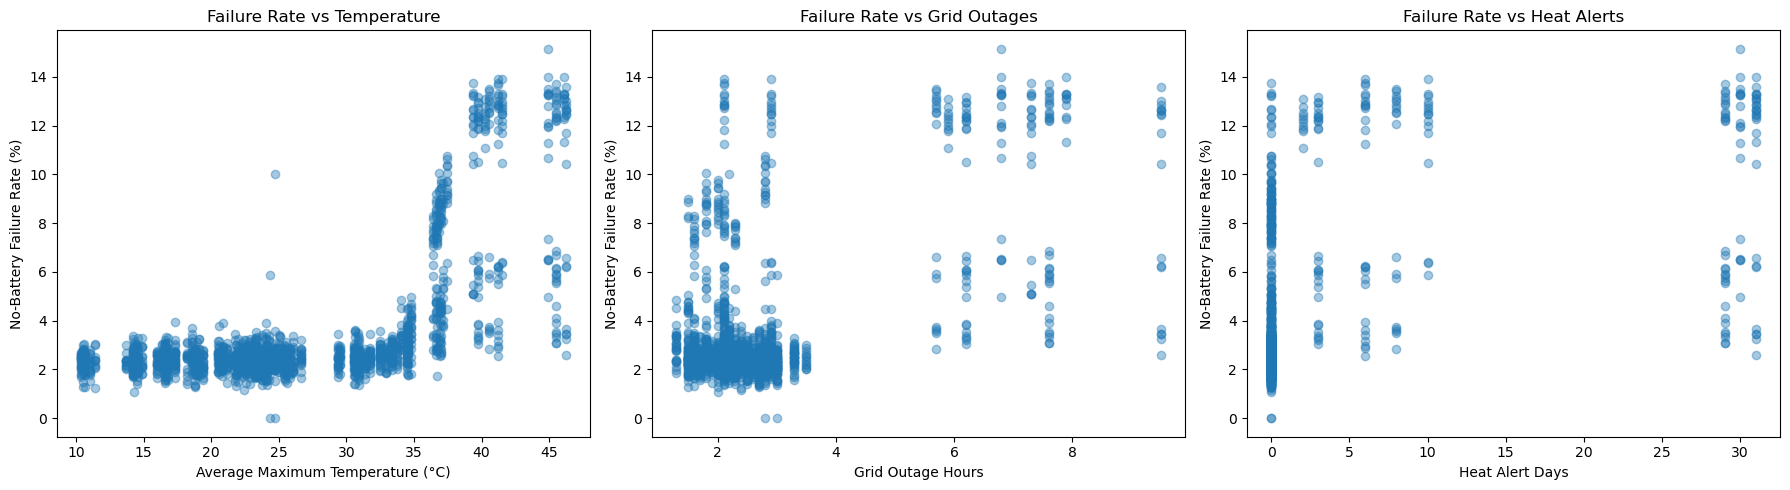

In [35]:
# ============================================================
# STEP 12 — FAILURE RATE vs CITY CONTEXT GRAPHS
# ============================================================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Temperature
axes[0].scatter(
    failure_context["avg_max_temp_c"],
    failure_context["no_battery_failure_rate_pct"],
    alpha=0.4
)
axes[0].set_xlabel("Average Maximum Temperature (°C)")
axes[0].set_ylabel("No-Battery Failure Rate (%)")
axes[0].set_title("Failure Rate vs Temperature")

# 2. Grid outages
axes[1].scatter(
    failure_context["grid_outage_hours"],
    failure_context["no_battery_failure_rate_pct"],
    alpha=0.4
)
axes[1].set_xlabel("Grid Outage Hours")
axes[1].set_ylabel("No-Battery Failure Rate (%)")
axes[1].set_title("Failure Rate vs Grid Outages")

# 3. Heat alerts
axes[2].scatter(
    failure_context["heat_alert_days"],
    failure_context["no_battery_failure_rate_pct"],
    alpha=0.4
)
axes[2].set_xlabel("Heat Alert Days")
axes[2].set_ylabel("No-Battery Failure Rate (%)")
axes[2].set_title("Failure Rate vs Heat Alerts")

plt.tight_layout()
plt.show()

In [36]:
# ============================================================
# STEP 13 — CITY-MONTH FAILURE RATE WITH CONTEXT
# ============================================================

city_month_analysis = (
    failure_context
    .groupby(["city", "month"])
    .agg(
        avg_failure_rate=("no_battery_failure_rate_pct", "mean"),
        total_failures=("no_battery_failures", "sum"),
        total_attempts=("attempts", "sum"),
        avg_temperature=("avg_max_temp_c", "first"),
        rainfall_mm=("total_rainfall_mm", "first"),
        heat_alert_days=("heat_alert_days", "first"),
        grid_outage_hours=("grid_outage_hours", "first")
    )
    .reset_index()
)

# Recalculate city-month failure rate from totals
city_month_analysis["failure_rate_pct"] = (
    city_month_analysis["total_failures"]
    / city_month_analysis["total_attempts"]
    * 100
)

print("\n" + "=" * 110)
print("CITY-MONTH FAILURE ANALYSIS")
print("=" * 110)

print(
    city_month_analysis[
        [
            "city",
            "month",
            "failure_rate_pct",
            "avg_temperature",
            "heat_alert_days",
            "grid_outage_hours",
            "rainfall_mm",
            "total_attempts",
            "total_failures"
        ]
    ]
    .sort_values("failure_rate_pct", ascending=False)
    .to_string(index=False)
)


CITY-MONTH FAILURE ANALYSIS
     city   month  failure_rate_pct  avg_temperature  heat_alert_days  grid_outage_hours  rainfall_mm  total_attempts  total_failures
   Jaipur 2024-05         12.936469        46.096774               31                7.9         12.0           18243          2360.0
   Jaipur 2024-06         12.246969        40.280000                2                5.9        338.3           18723          2293.0
Hyderabad 2024-05         11.406172        41.506452               10                2.9         20.2           26021          2968.0
Delhi NCR 2024-05         10.971317        44.922581               30                6.8         18.3           26706          2930.0
Delhi NCR 2024-06         10.362639        39.383333                0                7.3        290.3           28072          2909.0
   Jaipur 2025-06          9.115697        40.510000                8                5.7        284.1           42542          3878.0
Hyderabad 2024-06          8.9840

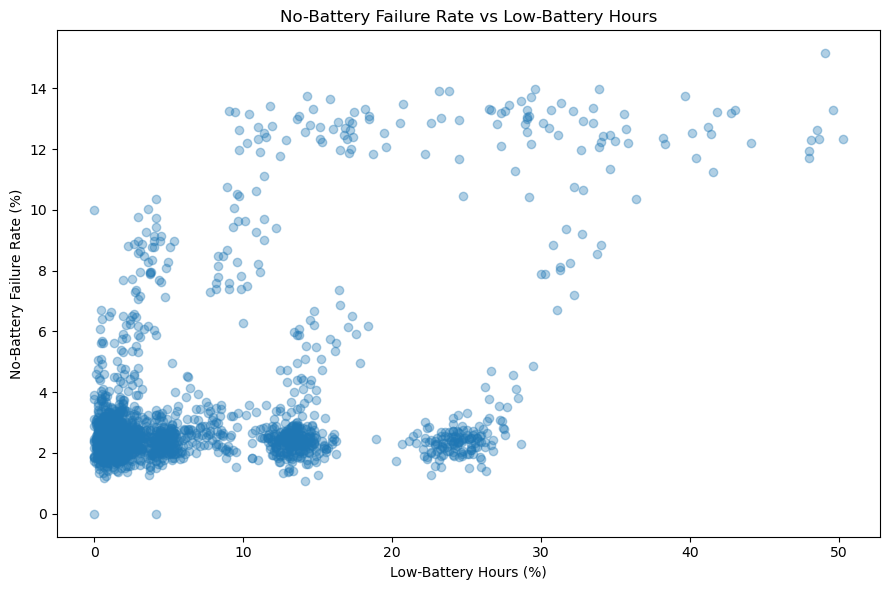

In [37]:
# ============================================================
# STEP 14 — BATTERY AVAILABILITY vs FAILURE RATE
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

plt.scatter(
    failure_rate_analysis["low_battery_hour_pct"],
    failure_rate_analysis["no_battery_failure_rate_pct"],
    alpha=0.35
)

plt.xlabel("Low-Battery Hours (%)")
plt.ylabel("No-Battery Failure Rate (%)")
plt.title("No-Battery Failure Rate vs Low-Battery Hours")

plt.tight_layout()
plt.show()

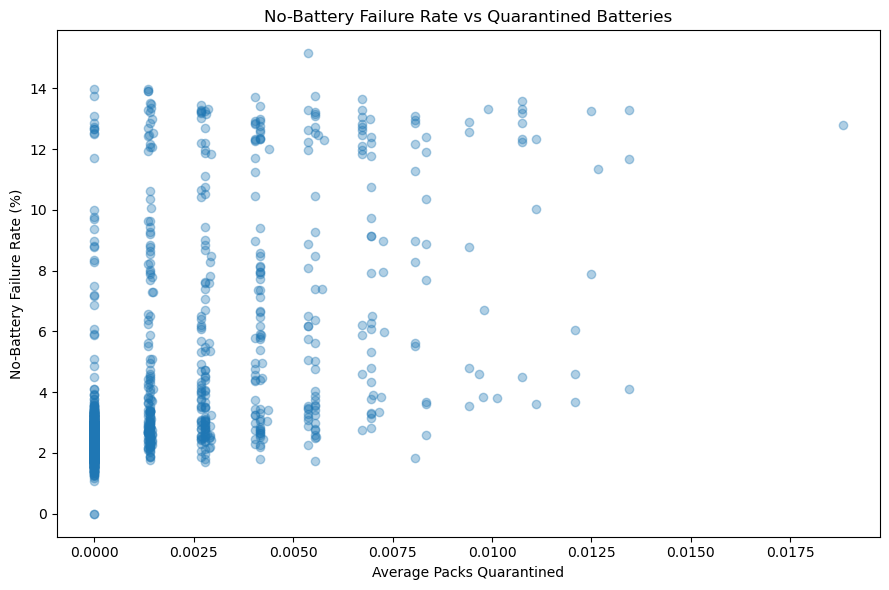

In [38]:
# ============================================================
# QUARANTINED BATTERIES vs FAILURE RATE
# ============================================================

plt.figure(figsize=(9, 6))

plt.scatter(
    failure_rate_analysis["avg_packs_quarantined"],
    failure_rate_analysis["no_battery_failure_rate_pct"],
    alpha=0.35
)

plt.xlabel("Average Packs Quarantined")
plt.ylabel("No-Battery Failure Rate (%)")
plt.title("No-Battery Failure Rate vs Quarantined Batteries")

plt.tight_layout()
plt.show()

In [39]:
# ============================================================
# STEP 15 — IDENTIFY MAJOR FAILURE DRIVERS
# ============================================================

# Correlation values already calculated from your analysis

driver_correlations = {
    "Average Maximum Temperature": 0.645156,
    "Grid Outage Hours": 0.588315,
    "Heat Alert Days": 0.566507,
    "Average Packs Quarantined": 0.549811,
    "Low-Battery Hour %": 0.429135,
    "Average Packs Charging": 0.024884,
    "Average Chargers Online": 0.022322,
    "Total Rainfall": -0.053920,
    "Flood Days": -0.061684
}

# Convert to DataFrame
driver_analysis = pd.DataFrame(
    list(driver_correlations.items()),
    columns=["driver", "correlation"]
)

# Absolute correlation = strength of relationship
driver_analysis["absolute_correlation"] = (
    driver_analysis["correlation"].abs()
)

# Sort strongest relationship first
driver_analysis = driver_analysis.sort_values(
    "absolute_correlation",
    ascending=False
).reset_index(drop=True)

# Add interpretation
def interpret_correlation(r):
    if abs(r) >= 0.60:
        strength = "Strong"
    elif abs(r) >= 0.40:
        strength = "Moderate"
    elif abs(r) >= 0.20:
        strength = "Weak"
    else:
        strength = "Very weak"

    direction = "Positive" if r > 0 else "Negative"

    return f"{strength} {direction}"

driver_analysis["relationship"] = (
    driver_analysis["correlation"]
    .apply(interpret_correlation)
)

print("\n" + "=" * 100)
print("STEP 15 — MAJOR FAILURE DRIVERS")
print("=" * 100)

print(
    driver_analysis[
        ["driver", "correlation", "relationship"]
    ].to_string(index=False)
)


STEP 15 — MAJOR FAILURE DRIVERS
                     driver  correlation       relationship
Average Maximum Temperature     0.645156    Strong Positive
          Grid Outage Hours     0.588315  Moderate Positive
            Heat Alert Days     0.566507  Moderate Positive
  Average Packs Quarantined     0.549811  Moderate Positive
         Low-Battery Hour %     0.429135  Moderate Positive
                 Flood Days    -0.061684 Very weak Negative
             Total Rainfall    -0.053920 Very weak Negative
     Average Packs Charging     0.024884 Very weak Positive
    Average Chargers Online     0.022322 Very weak Positive


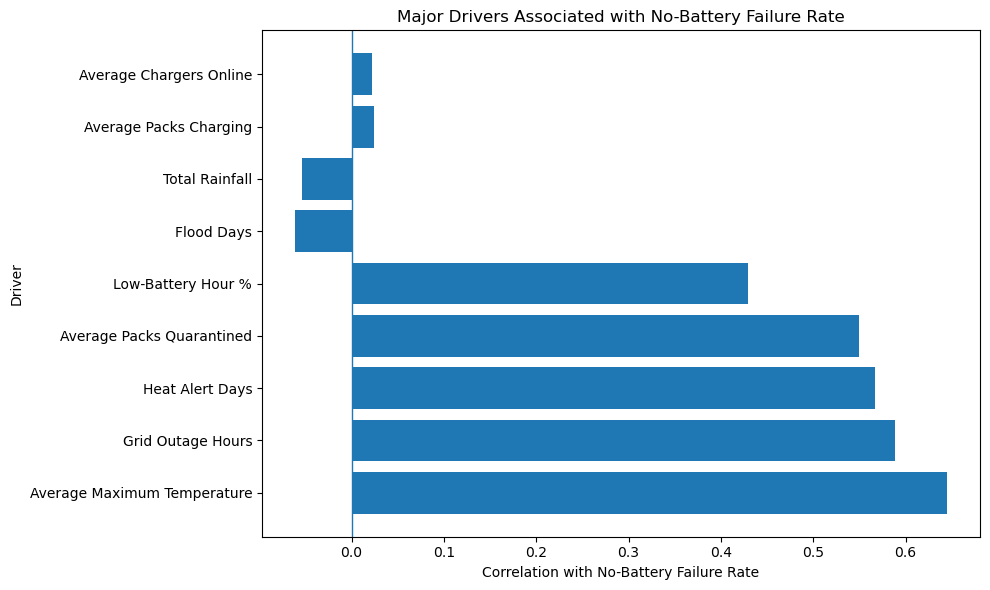

In [40]:
# ============================================================
# STEP 15B — VISUALIZE FAILURE DRIVERS
# ============================================================

plt.figure(figsize=(10, 6))

plt.barh(
    driver_analysis["driver"],
    driver_analysis["correlation"]
)

plt.axvline(0, linewidth=1)

plt.xlabel("Correlation with No-Battery Failure Rate")
plt.ylabel("Driver")
plt.title("Major Drivers Associated with No-Battery Failure Rate")

plt.tight_layout()
plt.show()

In [41]:
# ============================================================
# STEP 16 — MULTIPLE LINEAR REGRESSION
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Select features and target
# ------------------------------------------------------------

features = [
    "avg_max_temp_c",
    "grid_outage_hours",
    "heat_alert_days",
    "avg_packs_quarantined",
    "low_battery_hour_pct",
    "total_rainfall_mm",
    "flood_days",
    "avg_packs_charging",
    "avg_chargers_online"
]

target = "no_battery_failure_rate_pct"

# Use the merged failure + city-context dataset
model_data = failure_context[features + [target]].dropna().copy()

print("Rows available for modelling:", len(model_data))

# ------------------------------------------------------------
# 2. Split X and y
# ------------------------------------------------------------

X = model_data[features]
y = model_data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# ------------------------------------------------------------
# 3. Train Linear Regression model
# ------------------------------------------------------------

model = LinearRegression()

model.fit(X_train, y_train)

# ------------------------------------------------------------
# 4. Make predictions
# ------------------------------------------------------------

y_pred = model.predict(X_test)

# ------------------------------------------------------------
# 5. Evaluate model
# ------------------------------------------------------------

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n" + "=" * 90)
print("STEP 16 — MULTIPLE LINEAR REGRESSION RESULTS")
print("=" * 90)

print(f"R² Score : {r2:.4f}")
print(f"MAE      : {mae:.4f}")
print(f"RMSE     : {rmse:.4f}")

# ------------------------------------------------------------
# 6. Display coefficients
# ------------------------------------------------------------

coefficients = pd.DataFrame({
    "Driver": features,
    "Coefficient": model.coef_
})

coefficients["Absolute_Coefficient"] = (
    coefficients["Coefficient"].abs()
)

coefficients = coefficients.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

print("\n" + "=" * 90)
print("REGRESSION COEFFICIENTS")
print("=" * 90)

print(
    coefficients[
        ["Driver", "Coefficient"]
    ].to_string(index=False)
)

Rows available for modelling: 2073

STEP 16 — MULTIPLE LINEAR REGRESSION RESULTS
R² Score : 0.6627
MAE      : 1.0192
RMSE     : 1.4863

REGRESSION COEFFICIENTS
               Driver  Coefficient
avg_packs_quarantined   280.590285
    grid_outage_hours     0.422365
   avg_packs_charging     0.386806
 low_battery_hour_pct     0.127362
       avg_max_temp_c     0.088057
           flood_days    -0.081308
  avg_chargers_online     0.021003
      heat_alert_days    -0.013325
    total_rainfall_mm    -0.000421


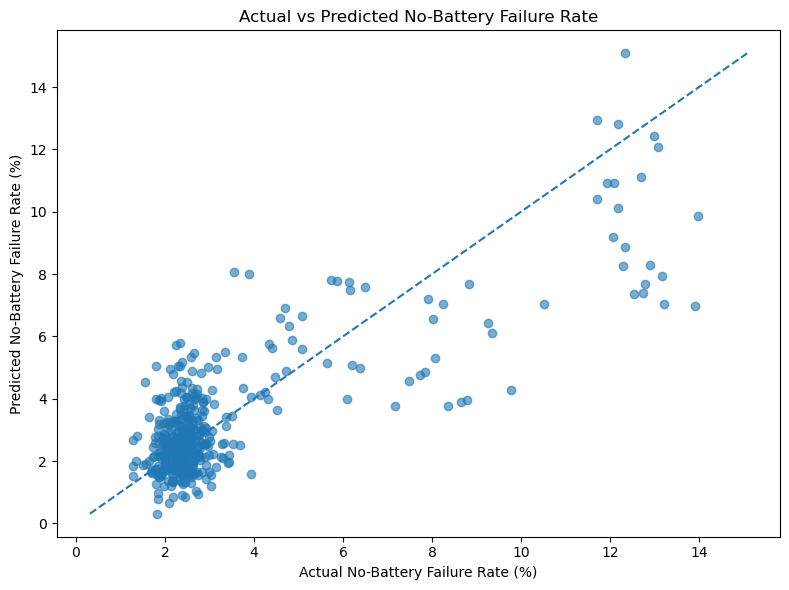

In [42]:
# ============================================================
# STEP 17 — ACTUAL vs PREDICTED FAILURE RATE
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

# Perfect prediction reference line
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual No-Battery Failure Rate (%)")
plt.ylabel("Predicted No-Battery Failure Rate (%)")
plt.title("Actual vs Predicted No-Battery Failure Rate")

plt.tight_layout()
plt.show()


STEP 18 — LARGEST PREDICTION ERRORS
 actual_failure_rate  predicted_failure_rate  residual  absolute_error
           13.921469                6.985873  6.935596        6.935596
           13.211249                7.044337  6.166912        6.166912
            9.781696                4.277940  5.503756        5.503756
           12.739726                7.380002  5.359724        5.359724
           13.167939                7.930325  5.237614        5.237614
           12.539683                7.371503  5.168180        5.168180
           12.776992                7.676026  5.100966        5.100966
            8.792373                3.963118  4.829255        4.829255
            8.647037                3.886890  4.760147        4.760147
           12.899709                8.283146  4.616564        4.616564
            8.366358                3.753773  4.612585        4.612585
            3.551697                8.066789 -4.515092        4.515092
           13.981763                9.86

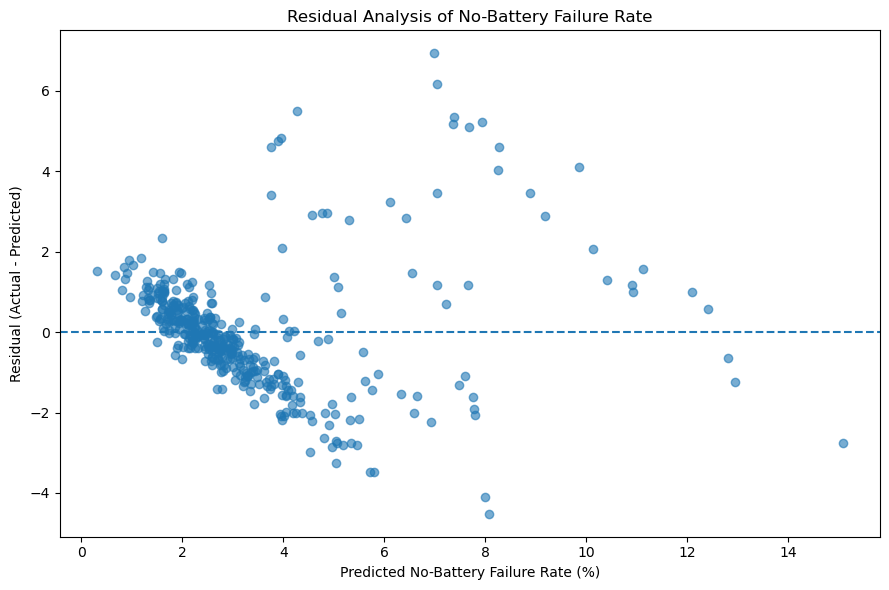

In [43]:
# ============================================================
# STEP 18 — PREDICTION ERROR / RESIDUAL ANALYSIS
# ============================================================

# Create a dataframe containing actual and predicted values
residual_analysis = pd.DataFrame({
    "actual_failure_rate": y_test.values,
    "predicted_failure_rate": y_pred
})

# Calculate residual
residual_analysis["residual"] = (
    residual_analysis["actual_failure_rate"]
    - residual_analysis["predicted_failure_rate"]
)

# Calculate absolute error
residual_analysis["absolute_error"] = (
    residual_analysis["residual"].abs()
)

print("\n" + "=" * 90)
print("STEP 18 — LARGEST PREDICTION ERRORS")
print("=" * 90)

print(
    residual_analysis
    .sort_values("absolute_error", ascending=False)
    .head(15)
    .to_string(index=False)
)

# ------------------------------------------------------------
# Residual plot
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

plt.scatter(
    y_pred,
    residual_analysis["residual"],
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted No-Battery Failure Rate (%)")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Analysis of No-Battery Failure Rate")

plt.tight_layout()
plt.show()

In [44]:
# ============================================================
# STEP 19 — ERROR ANALYSIS BY CITY
# ============================================================

# Create prediction results
test_results = X_test.copy()

test_results["actual_failure_rate"] = y_test.values
test_results["predicted_failure_rate"] = y_pred

# Calculate errors
test_results["absolute_error"] = (
    test_results["actual_failure_rate"]
    - test_results["predicted_failure_rate"]
).abs()

# Bring city/station/month information back
test_results["station_id"] = failure_context.loc[
    test_results.index, "station_id"
].values

test_results["city"] = failure_context.loc[
    test_results.index, "city"
].values

test_results["month"] = failure_context.loc[
    test_results.index, "month"
].values

# ------------------------------------------------------------
# City-level error analysis
# ------------------------------------------------------------

city_error = (
    test_results
    .groupby("city")
    .agg(
        avg_absolute_error=("absolute_error", "mean"),
        max_absolute_error=("absolute_error", "max"),
        avg_actual_failure_rate=("actual_failure_rate", "mean"),
        avg_predicted_failure_rate=("predicted_failure_rate", "mean"),
        observations=("absolute_error", "count")
    )
    .reset_index()
    .sort_values("avg_absolute_error", ascending=False)
)

print("\n" + "=" * 100)
print("STEP 19 — MODEL ERROR BY CITY")
print("=" * 100)

print(city_error.to_string(index=False))


STEP 19 — MODEL ERROR BY CITY
     city  avg_absolute_error  max_absolute_error  avg_actual_failure_rate  avg_predicted_failure_rate  observations
Delhi NCR            1.427823            6.166912                 4.515364                    4.288362            75
   Jaipur            1.298277            5.100966                 4.609614                    4.054687            49
Hyderabad            1.214117            6.935596                 3.662445                    3.493713            64
Bengaluru            0.851502            4.515092                 2.555149                    2.961272            99
     Pune            0.747148            2.780044                 2.722214                    2.782036            63
   Mumbai            0.664690            2.009257                 2.355873                    2.551254            65


In [45]:
# ============================================================
# STEP 20 — FINAL ANALYSIS SUMMARY
# ============================================================

print("\n" + "=" * 100)
print("STEP 20 — FINAL ANALYSIS SUMMARY")
print("=" * 100)

# ------------------------------------------------------------
# 1. Overall failure rate
# ------------------------------------------------------------

overall_failure_rate = (
    failure_context["no_battery_failures"].sum()
    / failure_context["attempts"].sum()
) * 100

print("\n1. OVERALL NO-BATTERY FAILURE RATE")
print(f"Overall Failure Rate: {overall_failure_rate:.2f}%")

# ------------------------------------------------------------
# 2. Highest failure-rate city-month
# ------------------------------------------------------------

city_month_summary = (
    failure_context
    .groupby(["city", "month"])
    .agg(
        total_attempts=("attempts", "sum"),
        total_failures=("no_battery_failures", "sum")
    )
    .reset_index()
)

city_month_summary["failure_rate_pct"] = (
    city_month_summary["total_failures"]
    / city_month_summary["total_attempts"]
) * 100

highest_city_month = city_month_summary.loc[
    city_month_summary["failure_rate_pct"].idxmax()
]

print("\n2. HIGHEST FAILURE-RATE CITY-MONTH")
print(
    f"City: {highest_city_month['city']}\n"
    f"Month: {highest_city_month['month']}\n"
    f"Failure Rate: {highest_city_month['failure_rate_pct']:.2f}%"
)

# ------------------------------------------------------------
# 3. City-level failure rate
# ------------------------------------------------------------

city_summary = (
    failure_context
    .groupby("city")
    .agg(
        total_attempts=("attempts", "sum"),
        total_failures=("no_battery_failures", "sum")
    )
    .reset_index()
)

city_summary["failure_rate_pct"] = (
    city_summary["total_failures"]
    / city_summary["total_attempts"]
) * 100

city_summary = city_summary.sort_values(
    "failure_rate_pct",
    ascending=False
)

print("\n3. FAILURE RATE BY CITY")
print(
    city_summary[
        ["city", "failure_rate_pct", "total_attempts", "total_failures"]
    ].to_string(index=False)
)

# ------------------------------------------------------------
# 4. Highest environmental/context values
# ------------------------------------------------------------

print("\n4. IMPORTANT CONTEXT EXTREMES")

print(
    f"Highest Average Temperature: "
    f"{failure_context['avg_max_temp_c'].max():.2f} °C"
)

print(
    f"Highest Grid Outage Hours: "
    f"{failure_context['grid_outage_hours'].max():.2f} hours"
)

print(
    f"Highest Heat Alert Days: "
    f"{failure_context['heat_alert_days'].max():.0f} days"
)

print(
    f"Highest Low-Battery Hour %: "
    f"{failure_context['low_battery_hour_pct'].max():.2f}%"
)

# ------------------------------------------------------------
# 5. Final conclusion
# ------------------------------------------------------------

print("\n5. KEY FINDINGS")
print("-" * 100)

print(
    "• No-battery failure is strongly associated with operational "
    "and environmental conditions."
)

print(
    "• Temperature, grid outages, heat-alert days and low-battery "
    "hours show important relationships with failure rate."
)

print(
    "• The regression model explains a substantial portion of the "
    "variation in failure rate."
)

print(
    "• Model errors vary by city, indicating that a single model "
    "does not perform equally across all locations."
)

print(
    "• The largest prediction errors indicate that additional "
    "station-level or operational variables may be needed."
)

print("\n" + "=" * 100)
print("END OF ANALYSIS")
print("=" * 100)


STEP 20 — FINAL ANALYSIS SUMMARY

1. OVERALL NO-BATTERY FAILURE RATE
Overall Failure Rate: 3.47%

2. HIGHEST FAILURE-RATE CITY-MONTH
City: Jaipur
Month: 2024-05
Failure Rate: 12.94%

3. FAILURE RATE BY CITY
     city  failure_rate_pct  total_attempts  total_failures
   Jaipur          4.778789          487634         23303.0
Delhi NCR          4.407781          768913         33892.0
Hyderabad          3.971458          711930         28274.0
     Pune          2.799732          552910         15480.0
Bengaluru          2.496223          825327         20602.0
   Mumbai          2.420898          530299         12838.0

4. IMPORTANT CONTEXT EXTREMES
Highest Average Temperature: 46.22 °C
Highest Grid Outage Hours: 9.50 hours
Highest Heat Alert Days: 31 days
Highest Low-Battery Hour %: 50.27%

5. KEY FINDINGS
----------------------------------------------------------------------------------------------------
• No-battery failure is strongly associated with operational and environmental 

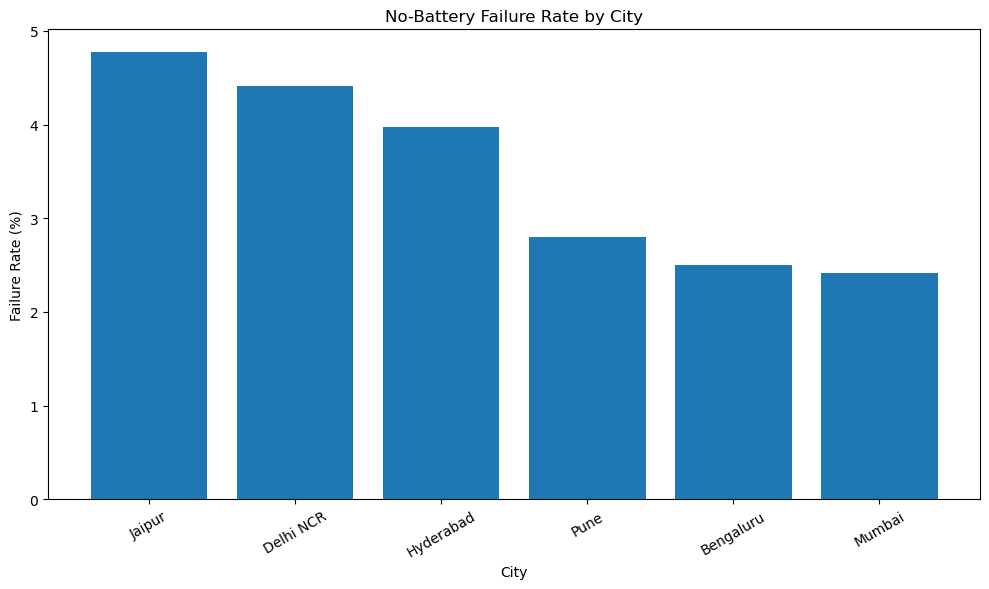

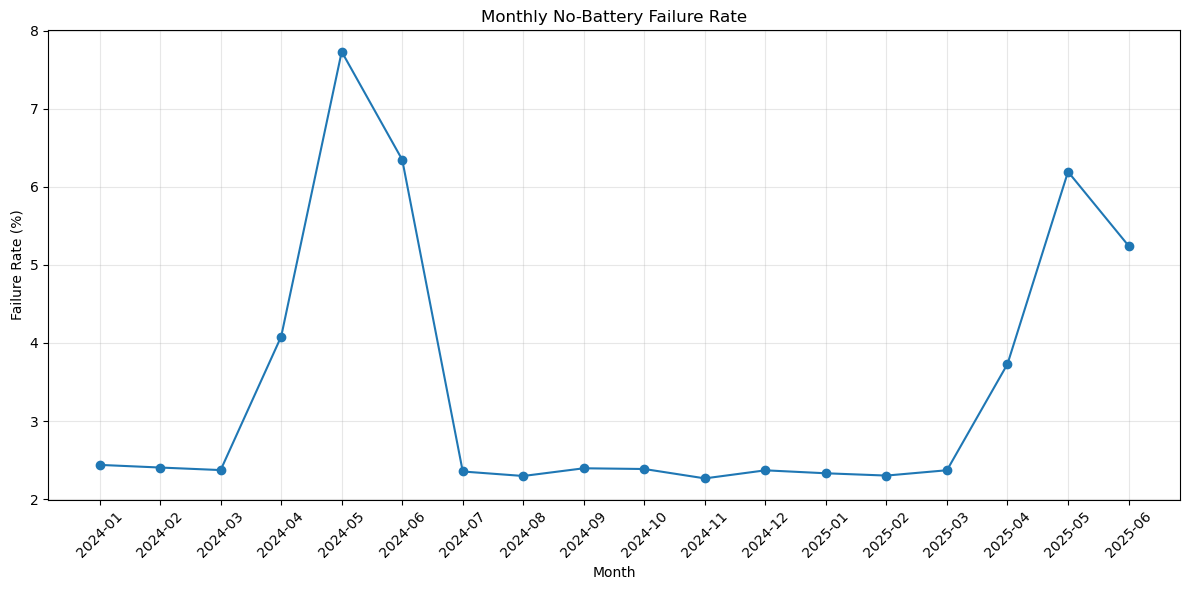

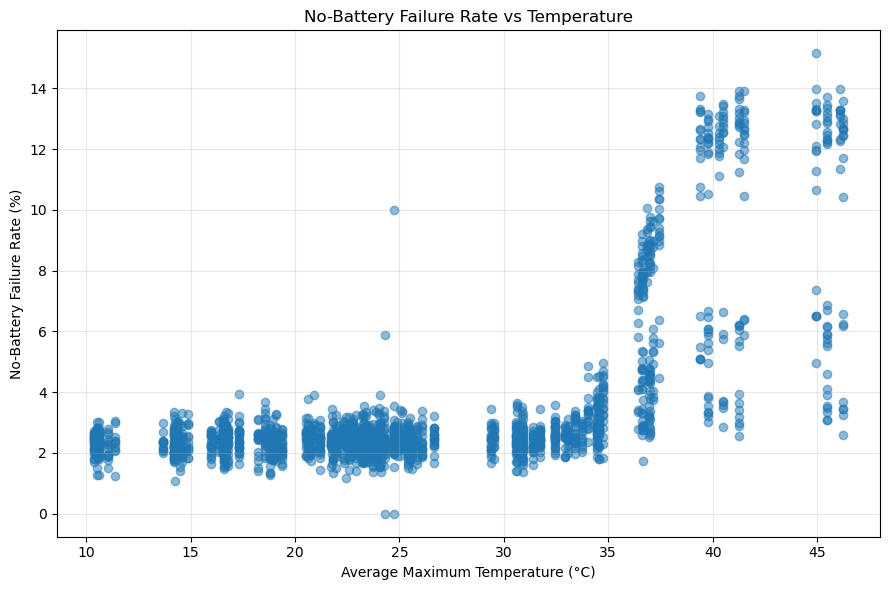

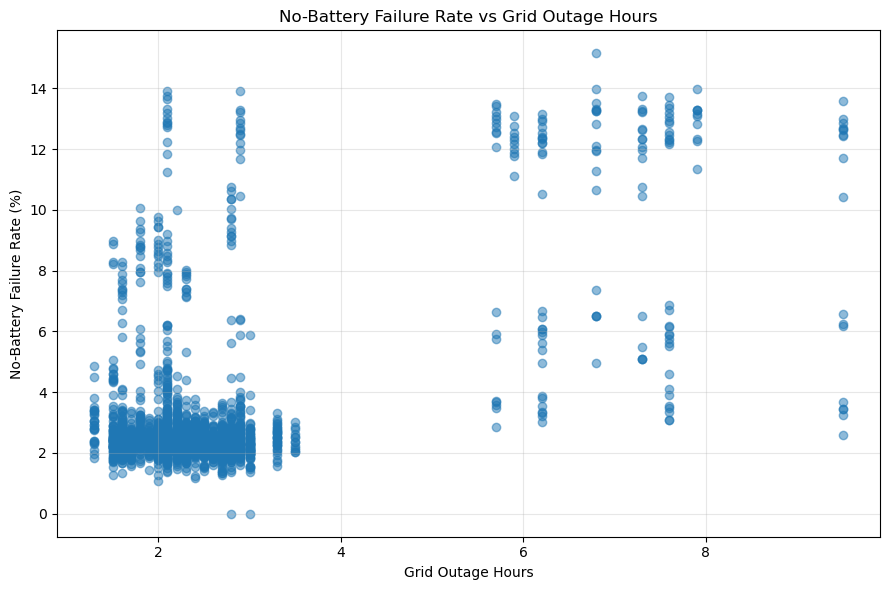

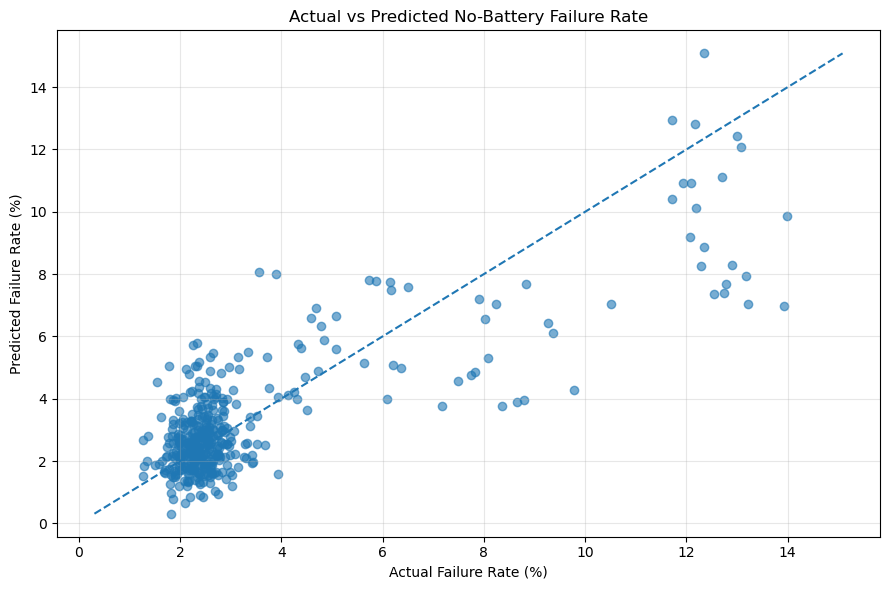

In [46]:
# ============================================================
# STEP 21 — FINAL VISUAL ANALYSIS
# ============================================================

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. FAILURE RATE BY CITY
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

city_plot = city_summary.sort_values(
    "failure_rate_pct",
    ascending=False
)

plt.bar(
    city_plot["city"],
    city_plot["failure_rate_pct"]
)

plt.title("No-Battery Failure Rate by City")
plt.xlabel("City")
plt.ylabel("Failure Rate (%)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 2. FAILURE RATE BY MONTH
# ------------------------------------------------------------

monthly_plot = (
    failure_context
    .groupby("month")
    .agg(
        total_attempts=("attempts", "sum"),
        total_failures=("no_battery_failures", "sum")
    )
    .reset_index()
)

monthly_plot["failure_rate_pct"] = (
    monthly_plot["total_failures"]
    / monthly_plot["total_attempts"]
) * 100

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_plot["month"],
    monthly_plot["failure_rate_pct"],
    marker="o"
)

plt.title("Monthly No-Battery Failure Rate")
plt.xlabel("Month")
plt.ylabel("Failure Rate (%)")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. FAILURE RATE VS TEMPERATURE
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

plt.scatter(
    failure_context["avg_max_temp_c"],
    failure_context["no_battery_failure_rate_pct"],
    alpha=0.5
)

plt.title("No-Battery Failure Rate vs Temperature")
plt.xlabel("Average Maximum Temperature (°C)")
plt.ylabel("No-Battery Failure Rate (%)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. FAILURE RATE VS GRID OUTAGES
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

plt.scatter(
    failure_context["grid_outage_hours"],
    failure_context["no_battery_failure_rate_pct"],
    alpha=0.5
)

plt.title("No-Battery Failure Rate vs Grid Outage Hours")
plt.xlabel("Grid Outage Hours")
plt.ylabel("No-Battery Failure Rate (%)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. ACTUAL VS PREDICTED
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

# Perfect prediction line
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.title("Actual vs Predicted No-Battery Failure Rate")
plt.xlabel("Actual Failure Rate (%)")
plt.ylabel("Predicted Failure Rate (%)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [47]:
# ============================================================
# STEP 21 — EXPANSION WAVE EFFECTIVENESS
# ============================================================

# Add expansion wave to failure analysis
wave_analysis = failure_rate_analysis.merge(
    stations[["station_id", "expansion_wave"]],
    on="station_id",
    how="left"
)

# Aggregate by expansion wave
wave_summary = (
    wave_analysis
    .groupby("expansion_wave")
    .agg(
        stations=("station_id", "nunique"),
        total_attempts=("attempts", "sum"),
        total_failures=("no_battery_failures", "sum"),
        avg_failure_rate=("no_battery_failure_rate_pct", "mean"),
        avg_low_battery_hours=("low_battery_hour_pct", "mean"),
        avg_charged_2w=("avg_charged_2w", "mean"),
        avg_packs_charging=("avg_packs_charging", "mean")
    )
    .reset_index()
)

# Calculate weighted failure rate
wave_summary["weighted_failure_rate_pct"] = (
    wave_summary["total_failures"]
    / wave_summary["total_attempts"]
    * 100
)

# Sort by expansion wave
wave_summary = wave_summary.sort_values(
    "weighted_failure_rate_pct",
    ascending=False
)

print("\n" + "=" * 100)
print("STEP 21 — EXPANSION WAVE EFFECTIVENESS")
print("=" * 100)

print(
    wave_summary.to_string(index=False)
)


STEP 21 — EXPANSION WAVE EFFECTIVENESS
expansion_wave  stations  total_attempts  total_failures  avg_failure_rate  avg_low_battery_hours  avg_charged_2w  avg_packs_charging  weighted_failure_rate_pct
        Launch        92         3130855        113847.0          3.549266               7.716646        8.603996            4.422710                   3.636291
  Wave2_2025H1        30          245060          6868.0          2.717018               3.714215        9.629493            3.925352                   2.802579
  Wave1_2024H2        30          501098         13674.0          2.766818               4.701404        9.102050            4.406962                   2.728808


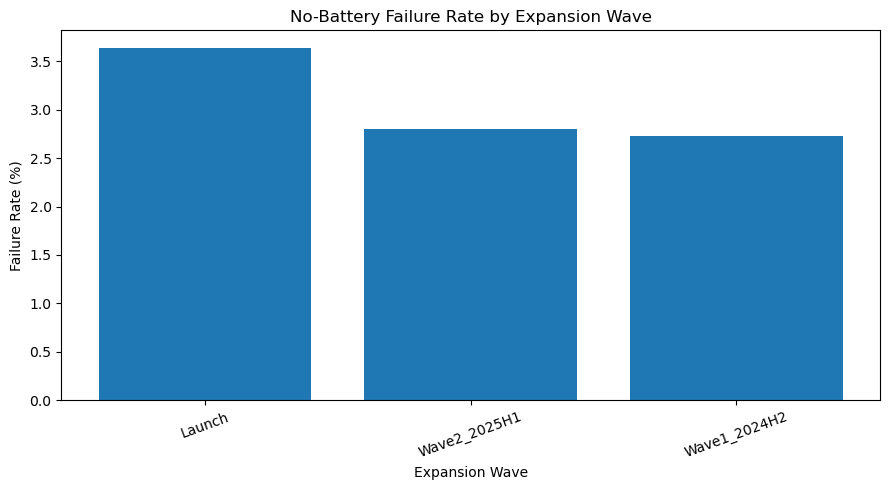

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.bar(
    wave_summary["expansion_wave"],
    wave_summary["weighted_failure_rate_pct"]
)

plt.xlabel("Expansion Wave")
plt.ylabel("Failure Rate (%)")
plt.title("No-Battery Failure Rate by Expansion Wave")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [49]:
# ============================================================
# STEP 22A — BUDGET DECISION: STATIONS vs BATTERIES
# ============================================================

# Station-level summary
station_budget = (
    failure_rate_analysis
    .groupby("station_id")
    .agg(
        avg_failure_rate=("no_battery_failure_rate_pct", "mean"),
        avg_low_battery_hours=("low_battery_hour_pct", "mean"),
        avg_charged_2w=("avg_charged_2w", "mean"),
        avg_packs_charging=("avg_packs_charging", "mean"),
        total_attempts=("attempts", "sum"),
        total_failures=("no_battery_failures", "sum")
    )
    .reset_index()
)

# Add city and station characteristics
station_budget = station_budget.merge(
    stations[
        [
            "station_id",
            "city",
            "location_type",
            "host_type",
            "expansion_wave",
            "charger_generation",
            "slots_2w"
        ]
    ],
    on="station_id",
    how="left"
)

print("\n" + "=" * 100)
print("STEP 22A — BUDGET DECISION: STATIONS vs BATTERIES")
print("=" * 100)

print("\nNETWORK SUMMARY")
print("-" * 100)

print(
    station_budget[
        [
            "avg_failure_rate",
            "avg_low_battery_hours",
            "avg_charged_2w",
            "avg_packs_charging",
            "total_attempts",
            "total_failures"
        ]
    ].mean().to_string()
)

print("\nTOP 15 STATIONS BY FAILURE RATE")
print("-" * 100)

print(
    station_budget
    .sort_values("avg_failure_rate", ascending=False)
    .head(15)
    .to_string(index=False)
)

print("\nTOP 15 STATIONS BY LOW-BATTERY HOURS")
print("-" * 100)

print(
    station_budget
    .sort_values("avg_low_battery_hours", ascending=False)
    .head(15)
    .to_string(index=False)
)


STEP 22A — BUDGET DECISION: STATIONS vs BATTERIES

NETWORK SUMMARY
----------------------------------------------------------------------------------------------------
avg_failure_rate             3.231096
avg_low_battery_hours        6.320093
avg_charged_2w               8.905944
avg_packs_charging           4.318560
total_attempts           25506.664474
total_failures             884.138158

TOP 15 STATIONS BY FAILURE RATE
----------------------------------------------------------------------------------------------------
 station_id  avg_failure_rate  avg_low_battery_hours  avg_charged_2w  avg_packs_charging  total_attempts  total_failures      city  location_type     host_type expansion_wave charger_generation  slots_2w
STN-JAI-138          5.519251              10.305273        7.442045            3.587528           48945          2635.0    Jaipur         market        kirana         Launch               Gen1        12
STN-DEL-037          5.366320               5.362916        9

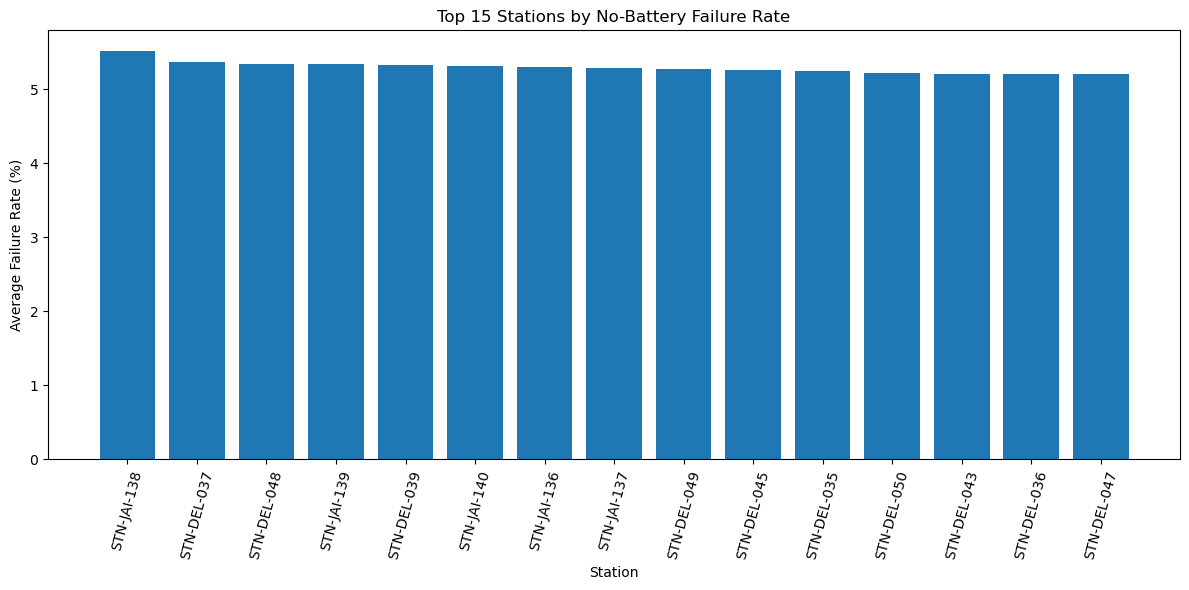

In [50]:
# ============================================================
# STEP 22B — HIGH-RISK STATIONS
# ============================================================

top_risk = (
    station_budget
    .sort_values("avg_failure_rate", ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 6))

plt.bar(
    top_risk["station_id"],
    top_risk["avg_failure_rate"]
)

plt.xlabel("Station")
plt.ylabel("Average Failure Rate (%)")
plt.title("Top 15 Stations by No-Battery Failure Rate")

plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

In [51]:
print("Fleet partners columns:")
print(fleet_partners.columns.tolist())

print("\nRiders columns:")
print(riders.columns.tolist())

print("\nAttempts columns:")
print(attempts.columns.tolist())

print("\nMonthly columns:")
print(monthly.columns.tolist())

Fleet partners columns:
['partner_id']

Riders columns:
['rider_id', 'partner_id']

Attempts columns:
['station_id', 'month', 'attempts']

Monthly columns:
['attempts', 'completed_swaps', 'no_battery_failures', 'system_failures', 'abandoned_swaps', 'cancelled_swaps', 'revenue_inr', 'energy_cost_inr', 'contribution_inr', 'no_battery_failure_rate_pct', 'system_failure_rate_pct', 'abandonment_rate_pct', 'cancellation_rate_pct', 'contribution_per_completed_swap_inr']


In [52]:
# ============================================================
# STEP 22B — BUDGET DECISION: PRICING & CONTRIBUTION
# ============================================================

pricing_summary = pd.DataFrame({
    "Metric": [
        "Total Revenue (INR)",
        "Total Energy Cost (INR)",
        "Total Contribution (INR)",
        "Average Contribution per Completed Swap (INR)",
        "Total Attempts",
        "Total Completed Swaps",
        "Overall Failure Rate (%)",
        "Overall Abandonment Rate (%)"
    ],
    "Value": [
        monthly["revenue_inr"].sum(),
        monthly["energy_cost_inr"].sum(),
        monthly["contribution_inr"].sum(),
        monthly["contribution_per_completed_swap_inr"].mean(),
        monthly["attempts"].sum(),
        monthly["completed_swaps"].sum(),
        monthly["no_battery_failures"].sum() / monthly["attempts"].sum() * 100,
        monthly["abandoned_swaps"].sum() / monthly["attempts"].sum() * 100
    ]
})

print("\n" + "=" * 100)
print("STEP 22B — PRICING & CONTRIBUTION ANALYSIS")
print("=" * 100)

print(pricing_summary.to_string(index=False))

# Monthly financial trend
monthly_financial = (
    monthly
    .reset_index()
    if isinstance(monthly.index, pd.MultiIndex)
    else monthly.copy()
)

print("\nMONTHLY FINANCIAL DATA")
print("-" * 100)

print(
    monthly_financial[
        [
            "revenue_inr",
            "energy_cost_inr",
            "contribution_inr",
            "contribution_per_completed_swap_inr"
        ]
    ].describe().to_string()
)


STEP 22B — PRICING & CONTRIBUTION ANALYSIS
                                       Metric        Value
                          Total Revenue (INR) 2.331261e+08
                      Total Energy Cost (INR) 7.108713e+07
                     Total Contribution (INR) 1.620389e+08
Average Contribution per Completed Swap (INR) 4.324592e+01
                               Total Attempts 3.877013e+06
                        Total Completed Swaps 3.645809e+06
                     Overall Failure Rate (%) 3.466303e+00
                 Overall Abandonment Rate (%) 1.767675e+00

MONTHLY FINANCIAL DATA
----------------------------------------------------------------------------------------------------
        revenue_inr  energy_cost_inr  contribution_inr  contribution_per_completed_swap_inr
count  1.800000e+01     1.800000e+01      1.800000e+01                            18.000000
mean   1.295145e+07     3.949285e+06      9.002163e+06                            43.245918
std    5.093169e+06     

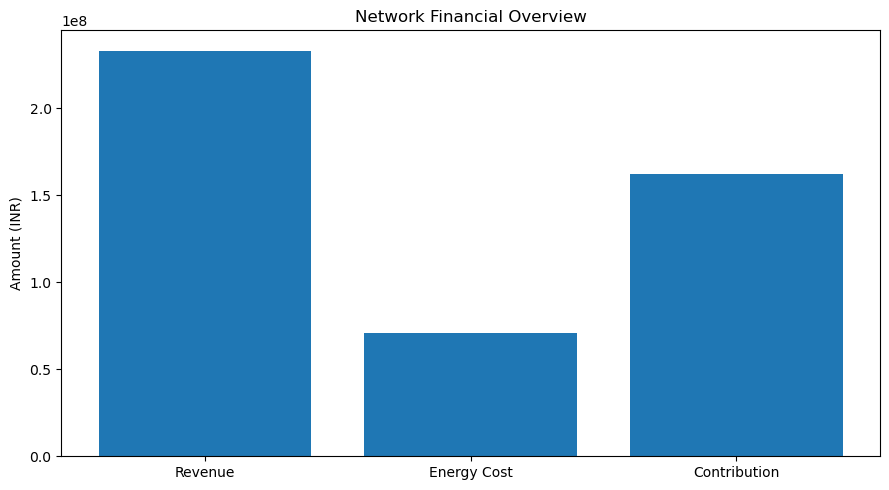

In [56]:
# ============================================================
# STEP 22C — REVENUE VS COST VS CONTRIBUTION
# ============================================================

financial_totals = [
    monthly["revenue_inr"].sum(),
    monthly["energy_cost_inr"].sum(),
    monthly["contribution_inr"].sum()
]

labels = [
    "Revenue",
    "Energy Cost",
    "Contribution"
]

plt.figure(figsize=(9, 5))

plt.bar(labels, financial_totals)

plt.ylabel("Amount (INR)")
plt.title("Network Financial Overview")

plt.tight_layout()
plt.show()

In [57]:
# ============================================================
# STEP 22D — STATION ANOMALY DETECTION
# ============================================================

print("\n" + "=" * 100)
print("STEP 22D — STATION ANOMALY DETECTION")
print("=" * 100)

# Work from station-level monthly analysis
anomaly_data = failure_rate_analysis.copy()

# Calculate station-level averages
station_anomaly = (
    anomaly_data
    .groupby("station_id")
    .agg(
        avg_failure_rate=("no_battery_failure_rate_pct", "mean"),
        max_failure_rate=("no_battery_failure_rate_pct", "max"),
        avg_low_battery_hours=("low_battery_hours", "mean"),
        avg_low_battery_pct=("low_battery_hour_pct", "mean"),
        avg_charged_2w=("avg_charged_2w", "mean"),
        avg_packs_charging=("avg_packs_charging", "mean"),
        total_attempts=("attempts", "sum"),
        total_failures=("no_battery_failures", "sum")
    )
    .reset_index()
)

# Add city information
station_anomaly = station_anomaly.merge(
    station_info[["station_id", "city", "location_type",
                  "host_type", "expansion_wave",
                  "charger_generation", "slots_2w"]],
    on="station_id",
    how="left"
)

# ------------------------------------------------------------
# Z-SCORES FOR ANOMALY DETECTION
# ------------------------------------------------------------

metrics = [
    "avg_failure_rate",
    "avg_low_battery_hours",
    "avg_low_battery_pct"
]

for col in metrics:
    mean_val = station_anomaly[col].mean()
    std_val = station_anomaly[col].std()

    station_anomaly[col + "_z"] = (
        (station_anomaly[col] - mean_val) / std_val
    )

# Overall anomaly score
station_anomaly["anomaly_score"] = (
    station_anomaly["avg_failure_rate_z"].abs()
    + station_anomaly["avg_low_battery_hours_z"].abs()
    + station_anomaly["avg_low_battery_pct_z"].abs()
)

# Sort by strongest anomalies
top_anomalies = station_anomaly.sort_values(
    "anomaly_score",
    ascending=False
)

print("\nTOP 15 STATION ANOMALIES")
print("-" * 100)

print(
    top_anomalies[
        [
            "station_id",
            "city",
            "avg_failure_rate",
            "avg_low_battery_hours",
            "avg_low_battery_pct",
            "avg_charged_2w",
            "avg_packs_charging",
            "total_attempts",
            "anomaly_score",
            "expansion_wave",
            "charger_generation"
        ]
    ]
    .head(15)
    .to_string(index=False)
)


STEP 22D — STATION ANOMALY DETECTION

TOP 15 STATION ANOMALIES
----------------------------------------------------------------------------------------------------
 station_id      city  avg_failure_rate  avg_low_battery_hours  avg_low_battery_pct  avg_charged_2w  avg_packs_charging  total_attempts  anomaly_score expansion_wave charger_generation
STN-JAI-137    Jaipur          5.281995             216.722222            29.703033        4.940502            2.379675           44371       8.599125         Launch               Gen1
STN-DEL-049 Delhi NCR          5.271585             215.388889            29.496028        4.969970            4.147084           21665       8.534211         Launch               Gen1
STN-JAI-136    Jaipur          5.304183             212.611111            29.129267        4.951939            4.195004           29340       8.461548         Launch               Gen1
STN-DEL-038 Delhi NCR          4.961338             211.944444            29.045094        4.97

In [66]:
# ============================================================
# STEP 23 — LOAD SWAP EVENTS FOR CHURN ANALYSIS
# ============================================================

swap_events = pd.read_csv(
    "data/swap_events.csv"
)

print("=" * 100)
print("STEP 23 — SWAP EVENTS LOADED")
print("=" * 100)

print("\nShape:")
print(swap_events.shape)

print("\nColumns:")
print(swap_events.columns.tolist())

print("\nFirst 5 rows:")
display(swap_events.head())

STEP 23 — SWAP EVENTS LOADED

Shape:
(3877013, 22)

Columns:
['event_id', 'rider_id', 'station_id', 'event_ts', 'event_type', 'attempt_seq', 'queue_wait_sec', 'battery_in_id', 'battery_out_id', 'soc_in_pct', 'soh_in_pct', 'soc_out_pct', 'soh_out_pct', 'km_since_last_swap', 'tariff_code', 'list_price_inr', 'discount_inr', 'amount_charged_inr', 'payment_mode', 'energy_to_recharge_kwh', 'station_firmware', 'sync_mode']

First 5 rows:


,event_id,rider_id,station_id,event_ts,event_type,attempt_seq,queue_wait_sec,battery_in_id,battery_out_id,soc_in_pct,soh_in_pct,soc_out_pct,soh_out_pct,km_since_last_swap,tariff_code,list_price_inr,discount_inr,amount_charged_inr,payment_mode,energy_to_recharge_kwh,station_firmware,sync_mode
0,SW-000000001,RD-1000003,STN-MUM-115,2024-01-01 11:10:56,swap_completed,1,88,BAT-2W-103542,BAT-2W-102547,15.0,100.6,98.7,98.9,80.4,PARTNER,60.0,6.0,54.0,partner_invoice,2.035,v3.2.1,realtime
1,SW-000000002,RD-1000004,STN-HYD-070,2024-01-01 17:13:06,swap_completed,1,148,BAT-2W-105296,BAT-2W-101923,8.3,98.3,97.3,98.2,66.1,PARTNER,60.0,9.0,51.0,partner_invoice,2.157,v3.2.0,realtime
2,SW-000000003,RD-1000005,STN-DEL-046,2024-01-01 20:15:14,swap_completed,1,307,BAT-2W-104732,BAT-2W-102492,11.5,99.1,99.8,99.1,66.6,STD,60.0,0.0,60.0,partner_invoice,2.039,v3.2.0,realtime
3,SW-000000004,RD-1000006,STN-JAI-135,2024-01-01 20:26:07,swap_completed,1,399,BAT-2W-103839,BAT-2W-103267,7.9,99.6,98.4,98.2,65.4,STD,60.0,0.0,60.0,partner_invoice,2.194,v3.2.0,realtime
4,SW-000000005,RD-1000012,STN-PUN-100,2024-01-01 21:13:07,swap_completed,1,201,BAT-2W-104056,BAT-2W-106218,10.5,99.2,95.6,99.9,73.8,STD,60.0,0.0,60.0,partner_invoice,1.971,v3.2.1,realtime


In [67]:
# ============================================================
# STEP 24 — RIDER ACTIVITY PROFILE FOR CHURN ANALYSIS
# ============================================================

swap_events["event_ts"] = pd.to_datetime(swap_events["event_ts"])

print("=" * 100)
print("STEP 24 — RIDER ACTIVITY PROFILE")
print("=" * 100)

# Overall observation period
print("\nOBSERVATION PERIOD:")
print("First event:", swap_events["event_ts"].min())
print("Last event :", swap_events["event_ts"].max())

# Activity per rider
rider_activity = (
    swap_events
    .groupby("rider_id")
    .agg(
        first_activity=("event_ts", "min"),
        last_activity=("event_ts", "max"),
        total_attempts=("event_id", "count")
    )
    .reset_index()
)

print("\nRIDER ACTIVITY SUMMARY:")
print("Unique riders:", len(rider_activity))

print("\nActivity count statistics:")
print(rider_activity["total_attempts"].describe())

print("\nSample:")
display(rider_activity.head(10))

STEP 24 — RIDER ACTIVITY PROFILE

OBSERVATION PERIOD:
First event: 2024-01-01 00:00:33
Last event : 2025-06-30 23:59:23

RIDER ACTIVITY SUMMARY:
Unique riders: 19950

Activity count statistics:
count    19950.000000
mean       194.336491
std        164.262678
min          1.000000
25%         59.000000
50%        151.000000
75%        291.000000
max        936.000000
Name: total_attempts, dtype: float64

Sample:


,rider_id,first_activity,last_activity,total_attempts
0,RD-1000000,2024-01-03 10:51:42,2024-08-10 17:38:38,235
1,RD-1000001,2024-01-02 19:26:59,2024-10-06 20:17:53,165
2,RD-1000002,2024-01-03 09:24:12,2025-06-30 08:45:06,787
3,RD-1000003,2024-01-01 11:10:56,2024-05-05 19:39:08,121
4,RD-1000004,2024-01-01 17:13:06,2025-03-08 18:40:29,440
5,RD-1000005,2024-01-01 20:15:14,2024-12-15 12:30:20,329
6,RD-1000006,2024-01-01 20:26:07,2025-06-28 07:55:58,510
7,RD-1000007,2024-01-02 18:26:13,2024-05-18 18:15:25,106
8,RD-1000008,2024-01-02 16:57:03,2025-06-30 19:19:23,475
9,RD-1000009,2024-01-02 21:42:31,2024-09-01 09:57:28,279


In [68]:
# ============================================================
# STEP 25 — RIDER CHURN FLAG
# ============================================================

import pandas as pd

# End of observation period
observation_end = swap_events["event_ts"].max()

# Start of churn window = final 60 days
churn_cutoff = observation_end - pd.Timedelta(days=60)

print("=" * 100)
print("STEP 25 — RIDER CHURN ANALYSIS")
print("=" * 100)

print("\nObservation end:", observation_end)
print("Churn cutoff   :", churn_cutoff)

# Create rider-level activity table
rider_churn = (
    swap_events
    .groupby("rider_id")
    .agg(
        first_activity=("event_ts", "min"),
        last_activity=("event_ts", "max"),
        total_attempts=("event_id", "count")
    )
    .reset_index()
)

# Only riders who were active BEFORE the final 60-day window
rider_churn["eligible_for_churn"] = (
    rider_churn["last_activity"] < churn_cutoff
)

# Churn flag
rider_churn["churned"] = (
    rider_churn["last_activity"] < churn_cutoff
).astype(int)

print("\nCHURN SUMMARY")
print("-" * 100)

print("Total active riders:", len(rider_churn))
print("Churned riders:", rider_churn["churned"].sum())
print(
    "Churn rate among observed riders:",
    round(rider_churn["churned"].mean() * 100, 2),
    "%"
)

print("\nCHURN COUNTS:")
print(rider_churn["churned"].value_counts())

print("\nSAMPLE:")
display(rider_churn.head(10))

STEP 25 — RIDER CHURN ANALYSIS

Observation end: 2025-06-30 23:59:23
Churn cutoff   : 2025-05-01 23:59:23

CHURN SUMMARY
----------------------------------------------------------------------------------------------------
Total active riders: 19950
Churned riders: 6760
Churn rate among observed riders: 33.88 %

CHURN COUNTS:
churned
0    13190
1     6760
Name: count, dtype: int64

SAMPLE:


,rider_id,first_activity,last_activity,total_attempts,eligible_for_churn,churned
0,RD-1000000,2024-01-03 10:51:42,2024-08-10 17:38:38,235,True,1
1,RD-1000001,2024-01-02 19:26:59,2024-10-06 20:17:53,165,True,1
2,RD-1000002,2024-01-03 09:24:12,2025-06-30 08:45:06,787,False,0
3,RD-1000003,2024-01-01 11:10:56,2024-05-05 19:39:08,121,True,1
4,RD-1000004,2024-01-01 17:13:06,2025-03-08 18:40:29,440,True,1
5,RD-1000005,2024-01-01 20:15:14,2024-12-15 12:30:20,329,True,1
6,RD-1000006,2024-01-01 20:26:07,2025-06-28 07:55:58,510,False,0
7,RD-1000007,2024-01-02 18:26:13,2024-05-18 18:15:25,106,True,1
8,RD-1000008,2024-01-02 16:57:03,2025-06-30 19:19:23,475,False,0
9,RD-1000009,2024-01-02 21:42:31,2024-09-01 09:57:28,279,True,1


In [70]:
# ============================================================
# STEP 26 — CHURN BY FLEET VS INDEPENDENT
# ============================================================

print("=" * 100)
print("STEP 26 — CHURN BY FLEET STATUS")
print("=" * 100)

# Merge churn data with available rider data
rider_churn_full = rider_churn.merge(
    riders[["rider_id", "partner_id"]],
    on="rider_id",
    how="left"
)

# Identify fleet vs independent riders
rider_churn_full["fleet_status"] = rider_churn_full["partner_id"].apply(
    lambda x: "Fleet Partner"
    if pd.notna(x) and str(x).strip() != ""
    else "Independent"
)

# Calculate churn statistics
fleet_churn = (
    rider_churn_full
    .groupby("fleet_status")
    .agg(
        riders=("rider_id", "count"),
        churned_riders=("churned", "sum"),
        churn_rate_pct=("churned", "mean")
    )
    .reset_index()
)

fleet_churn["churn_rate_pct"] = (
    fleet_churn["churn_rate_pct"] * 100
).round(2)

print("\nCHURN BY FLEET STATUS")
print("-" * 100)

display(fleet_churn)

STEP 26 — CHURN BY FLEET STATUS

CHURN BY FLEET STATUS
----------------------------------------------------------------------------------------------------


,fleet_status,riders,churned_riders,churn_rate_pct
0,Fleet Partner,12348,4192,33.95
1,Independent,7602,2568,33.78


In [72]:
# ============================================================
# STEP 27 — RIDER SERVICE EXPERIENCE — CORRECTED
# ============================================================

print("=" * 100)
print("STEP 27 — RIDER SERVICE EXPERIENCE")
print("=" * 100)

# Create outcome flags
swap_events["no_battery"] = (
    swap_events["event_type"] == "failed_no_charged_battery"
).astype(int)

swap_events["system_failure"] = (
    swap_events["event_type"] == "failed_system_error"
).astype(int)

swap_events["abandoned"] = (
    swap_events["event_type"] == "abandoned_queue"
).astype(int)

swap_events["cancelled"] = (
    swap_events["event_type"] == "cancelled_by_rider"
).astype(int)

swap_events["failed"] = (
    swap_events["event_type"] != "swap_completed"
).astype(int)


# ------------------------------------------------------------
# RIDER-LEVEL SERVICE EXPERIENCE
# ------------------------------------------------------------

rider_experience = (
    swap_events
    .groupby("rider_id")
    .agg(
        service_attempts=("event_id", "count"),
        failed_attempts=("failed", "sum"),
        no_battery_failures=("no_battery", "sum"),
        system_failures=("system_failure", "sum"),
        abandoned_attempts=("abandoned", "sum"),
        cancelled_attempts=("cancelled", "sum"),
        avg_queue_wait_sec=("queue_wait_sec", "mean")
    )
    .reset_index()
)

# Failure rate
rider_experience["failure_rate_pct"] = (
    rider_experience["failed_attempts"]
    / rider_experience["service_attempts"]
    * 100
)

# ------------------------------------------------------------
# MERGE WITH CHURN
# ------------------------------------------------------------

churn_experience = rider_churn.merge(
    rider_experience,
    on="rider_id",
    how="left"
)

# ------------------------------------------------------------
# DISPLAY
# ------------------------------------------------------------

print("\nRIDER EXPERIENCE SUMMARY")
print("-" * 100)

display(
    churn_experience[
        [
            "rider_id",
            "service_attempts",
            "failed_attempts",
            "no_battery_failures",
            "system_failures",
            "abandoned_attempts",
            "cancelled_attempts",
            "failure_rate_pct",
            "avg_queue_wait_sec",
            "churned"
        ]
    ].head(10)
)

print("\nRows:", len(churn_experience))

STEP 27 — RIDER SERVICE EXPERIENCE

RIDER EXPERIENCE SUMMARY
----------------------------------------------------------------------------------------------------


,rider_id,service_attempts,failed_attempts,no_battery_failures,system_failures,abandoned_attempts,cancelled_attempts,failure_rate_pct,avg_queue_wait_sec,churned
0,RD-1000000,235,26,17,0,9,0,11.063830,255.382979,1
1,RD-1000001,165,13,9,1,3,0,7.878788,222.436364,1
2,RD-1000002,787,47,24,1,10,12,5.972046,242.168996,0
3,RD-1000003,121,4,1,0,3,0,3.305785,246.917355,1
4,RD-1000004,440,18,11,0,5,2,4.090909,250.022727,1
5,RD-1000005,329,11,5,0,5,1,3.343465,243.902736,1
6,RD-1000006,510,41,27,2,10,2,8.039216,237.345098,0
7,RD-1000007,106,6,4,0,2,0,5.660377,226.216981,1
8,RD-1000008,475,43,29,2,11,1,9.052632,243.882105,0
9,RD-1000009,279,19,16,0,3,0,6.810036,239.089606,1



Rows: 19950


In [73]:
# ============================================================
# STEP 28 — CHURNED VS RETAINED SERVICE EXPERIENCE
# ============================================================

print("=" * 100)
print("STEP 28 — CHURNED VS RETAINED SERVICE EXPERIENCE")
print("=" * 100)

churn_experience_summary = (
    churn_experience
    .groupby("churned")
    .agg(
        riders=("rider_id", "count"),
        avg_attempts=("service_attempts", "mean"),
        avg_failed_attempts=("failed_attempts", "mean"),
        avg_no_battery_failures=("no_battery_failures", "mean"),
        avg_system_failures=("system_failures", "mean"),
        avg_abandoned_attempts=("abandoned_attempts", "mean"),
        avg_cancelled_attempts=("cancelled_attempts", "mean"),
        avg_failure_rate_pct=("failure_rate_pct", "mean"),
        avg_queue_wait_sec=("avg_queue_wait_sec", "mean")
    )
    .reset_index()
)

# Replace 0/1 with readable labels
churn_experience_summary["churn_status"] = (
    churn_experience_summary["churned"]
    .map({
        0: "Retained",
        1: "Churned"
    })
)

# Put readable label first
churn_experience_summary = churn_experience_summary[
    [
        "churn_status",
        "riders",
        "avg_attempts",
        "avg_failed_attempts",
        "avg_no_battery_failures",
        "avg_system_failures",
        "avg_abandoned_attempts",
        "avg_cancelled_attempts",
        "avg_failure_rate_pct",
        "avg_queue_wait_sec"
    ]
]

# Round numerical values
churn_experience_summary = churn_experience_summary.round(2)

display(churn_experience_summary)

STEP 28 — CHURNED VS RETAINED SERVICE EXPERIENCE


,churn_status,riders,avg_attempts,avg_failed_attempts,avg_no_battery_failures,avg_system_failures,avg_abandoned_attempts,avg_cancelled_attempts,avg_failure_rate_pct,avg_queue_wait_sec
0,Retained,13190,223.32,13.53,7.89,0.68,3.99,0.97,6.95,242.91
1,Churned,6760,137.78,7.81,4.49,0.39,2.35,0.58,6.24,243.50


In [74]:
# ============================================================
# STEP 29 — CHURN RATE BY SERVICE FAILURE LEVEL
# ============================================================

print("=" * 100)
print("STEP 29 — CHURN RATE BY SERVICE FAILURE LEVEL")
print("=" * 100)

churn_bands = churn_experience.copy()

# Create failure-rate bands
churn_bands["failure_rate_band"] = pd.cut(
    churn_bands["failure_rate_pct"],
    bins=[-0.01, 2, 4, 6, 8, 10, 15, 100],
    labels=[
        "0–2%",
        "2–4%",
        "4–6%",
        "6–8%",
        "8–10%",
        "10–15%",
        "15%+"
    ]
)

churn_by_failure_band = (
    churn_bands
    .groupby("failure_rate_band", observed=False)
    .agg(
        riders=("rider_id", "count"),
        churned_riders=("churned", "sum"),
        churn_rate_pct=("churned", "mean")
    )
    .reset_index()
)

churn_by_failure_band["churn_rate_pct"] = (
    churn_by_failure_band["churn_rate_pct"] * 100
).round(2)

display(churn_by_failure_band)

STEP 29 — CHURN RATE BY SERVICE FAILURE LEVEL


,failure_rate_band,riders,churned_riders,churn_rate_pct
0,0–2%,2055,1012,49.25
1,2–4%,4261,1515,35.56
2,4–6%,4992,1548,31.01
3,6–8%,3117,1031,33.08
4,8–10%,2031,606,29.84
5,10–15%,2235,685,30.65
6,15%+,1259,363,28.83


In [75]:
# ============================================================
# STEP 30 — CHURN BY RIDER ACTIVITY LEVEL
# ============================================================

print("=" * 100)
print("STEP 30 — CHURN BY RIDER ACTIVITY LEVEL")
print("=" * 100)

activity_churn = churn_experience.copy()

# Create activity bands
activity_churn["activity_band"] = pd.cut(
    activity_churn["service_attempts"],
    bins=[0, 25, 50, 100, 200, 400, 1000, float("inf")],
    labels=[
        "1–25",
        "26–50",
        "51–100",
        "101–200",
        "201–400",
        "401–1000",
        "1000+"
    ],
    include_lowest=True
)

activity_summary = (
    activity_churn
    .groupby("activity_band", observed=False)
    .agg(
        riders=("rider_id", "count"),
        churned_riders=("churned", "sum"),
        churn_rate_pct=("churned", "mean")
    )
    .reset_index()
)

activity_summary["churn_rate_pct"] = (
    activity_summary["churn_rate_pct"] * 100
).round(2)

display(activity_summary)

STEP 30 — CHURN BY RIDER ACTIVITY LEVEL


,activity_band,riders,churned_riders,churn_rate_pct
0,1–25,2478,1174,47.38
1,26–50,1983,870,43.87
2,51–100,2929,1217,41.55
3,101–200,4683,1781,38.03
4,201–400,5201,1440,27.69
5,401–1000,2676,278,10.39
6,1000+,0,0,NaN


In [77]:
# ============================================================
# STEP 31 — CHURN BY FLEET PARTNER
# ============================================================

print("=" * 100)
print("STEP 31 — CHURN BY FLEET PARTNER")
print("=" * 100)

partner_churn = (
    rider_churn_full[
        rider_churn_full["partner_id"].notna()
    ]
    .groupby("partner_id")
    .agg(
        riders=("rider_id", "count"),
        churned_riders=("churned", "sum"),
        churn_rate_pct=("churned", "mean")
    )
    .reset_index()
)

partner_churn["churn_rate_pct"] = (
    partner_churn["churn_rate_pct"] * 100
).round(2)

partner_churn = partner_churn.sort_values(
    "churn_rate_pct",
    ascending=False
)

display(partner_churn)

print("\nFleet partners analyzed:", len(partner_churn))

STEP 31 — CHURN BY FLEET PARTNER


,partner_id,riders,churned_riders,churn_rate_pct
8,FP-09,370,148,40.00
6,FP-07,531,186,35.03
11,FP-12,374,131,35.03
2,FP-03,2380,819,34.41
7,FP-08,488,167,34.22
4,FP-05,1253,427,34.08
1,FP-02,1762,600,34.05
3,FP-04,866,292,33.72
0,FP-01,2704,904,33.43
10,FP-11,495,164,33.13



Fleet partners analyzed: 12


In [79]:
# ============================================================
# STEP 32 — ADD RIDER PLAN TYPE TO CHURN DATA
# ============================================================

print("=" * 100)
print("STEP 32 — PREPARING PLAN TYPE DATA")
print("=" * 100)

# Check what is actually available
print("\nRiders columns:")
print(riders.columns.tolist())

print("\nRider churn columns:")
print(rider_churn_full.columns.tolist())

STEP 32 — PREPARING PLAN TYPE DATA

Riders columns:
['rider_id', 'partner_id']

Rider churn columns:
['rider_id', 'first_activity', 'last_activity', 'total_attempts', 'eligible_for_churn', 'churned', 'partner_id', 'fleet_status']


In [80]:
# ============================================================
# STEP 32A — LOAD RIDER PROFILE DATA
# ============================================================

riders_full = pd.read_csv(
    "data/riders.csv"
)

print("=" * 100)
print("RIDER PROFILE DATA LOADED")
print("=" * 100)

print("\nShape:")
print(riders_full.shape)

print("\nColumns:")
print(riders_full.columns.tolist())

print("\nRequired columns:")
print(
    riders_full[
        ["rider_id", "vehicle_class", "plan_type", "partner_id"]
    ].head()
)

RIDER PROFILE DATA LOADED

Shape:
(20000, 12)

Columns:
['rider_id', 'partner_id', 'vehicle_class', 'vehicle_model', 'home_zone', 'signup_date', 'signup_channel', 'plan_type', 'declared_shift', 'age_band', 'kyc_verified', 'home_city']

Required columns:
     rider_id vehicle_class       plan_type partner_id
0  RD-1000000            3W  partner_billed      FP-04
1  RD-1000001            2W  partner_billed      FP-05
2  RD-1000002            2W  partner_billed      FP-06
3  RD-1000003            2W  partner_billed      FP-01
4  RD-1000004            2W  partner_billed      FP-02


In [81]:
# ============================================================
# STEP 32B — MERGE RIDER PROFILE INTO CHURN DATA
# ============================================================

rider_churn_plan = rider_churn_full.merge(
    riders_full[
        ["rider_id", "vehicle_class", "plan_type"]
    ],
    on="rider_id",
    how="left"
)

print("=" * 100)
print("STEP 32B — CHURN DATA + RIDER PROFILE")
print("=" * 100)

print("\nShape:", rider_churn_plan.shape)

print("\nMissing values:")
print(
    rider_churn_plan[
        ["vehicle_class", "plan_type"]
    ].isna().sum()
)

STEP 32B — CHURN DATA + RIDER PROFILE

Shape: (19950, 10)

Missing values:
vehicle_class    0
plan_type        0
dtype: int64


In [82]:
# ============================================================
# STEP 32C — CHURN BY PLAN TYPE
# ============================================================

plan_churn = (
    rider_churn_plan
    .groupby("plan_type")
    .agg(
        riders=("rider_id", "count"),
        churned_riders=("churned", "sum"),
        churn_rate_pct=("churned", "mean")
    )
    .reset_index()
)

plan_churn["churn_rate_pct"] = (
    plan_churn["churn_rate_pct"] * 100
).round(2)

print("\n" + "=" * 100)
print("STEP 32C — CHURN BY PLAN TYPE")
print("=" * 100)

display(plan_churn)


STEP 32C — CHURN BY PLAN TYPE


,plan_type,riders,churned_riders,churn_rate_pct
0,partner_billed,12348,4192,33.95
1,pay_as_you_go,5285,1796,33.98
2,prepaid_pack,2317,772,33.32


In [83]:
# ============================================================
# STEP 32D — CHURN BY VEHICLE CLASS
# ============================================================

vehicle_churn = (
    rider_churn_plan
    .groupby("vehicle_class")
    .agg(
        riders=("rider_id", "count"),
        churned_riders=("churned", "sum"),
        churn_rate_pct=("churned", "mean")
    )
    .reset_index()
)

vehicle_churn["churn_rate_pct"] = (
    vehicle_churn["churn_rate_pct"] * 100
).round(2)

print("\n" + "=" * 100)
print("STEP 32D — CHURN BY VEHICLE CLASS")
print("=" * 100)

display(vehicle_churn)


STEP 32D — CHURN BY VEHICLE CLASS


,vehicle_class,riders,churned_riders,churn_rate_pct
0,2W,17070,5727,33.55
1,3W,2880,1033,35.87


In [84]:
# ============================================================
# STEP 33A — LOAD FULL SUPPORT TICKET DATA
# ============================================================

support_full = pd.read_csv(
    "data/support_tickets.csv"
)

print("=" * 100)
print("STEP 33A — SUPPORT TICKETS LOADED")
print("=" * 100)

print("\nShape:")
print(support_full.shape)

print("\nColumns:")
print(support_full.columns.tolist())

print("\nFirst 5 rows:")
display(support_full.head())

STEP 33A — SUPPORT TICKETS LOADED

Shape:
(44000, 12)

Columns:
['ticket_id', 'rider_id', 'station_id', 'battery_id', 'created_ts', 'channel', 'category', 'rider_comment', 'priority', 'resolution_status', 'resolution_hours', 'csat_score']

First 5 rows:


,ticket_id,rider_id,station_id,battery_id,created_ts,channel,category,rider_comment,priority,resolution_status,resolution_hours,csat_score
0,TK-0000001,RD-1001097,STN-BLR-016,NaN,2024-01-01 17:44:05,call_center,billing_dispute,amount galat kata hai is baar,low,duplicate,NaN,NaN
1,TK-0000002,RD-1001216,STN-BLR-020,BAT-2W-104489,2024-01-01 22:59:14,partner_escalation,long_queue,queue itna lamba tha ki late ho gaya delivery ...,medium,resolved,5.2,NaN
2,TK-0000003,RD-1001631,STN-JAI-140,BAT-2W-102867,2024-01-01 19:20:12,app_chat,long_queue,queue itna lamba tha ki late ho gaya delivery ...,medium,resolved,16.3,NaN
3,TK-0000004,RD-1002086,STN-DEL-039,BAT-2W-102727,2024-01-01 03:14:33,partner_escalation,long_queue,queue itna lamba tha ki late ho gaya delivery ...,high,resolved,4.4,3.0
4,TK-0000005,RD-1002308,STN-BLR-004,BAT-2W-105975,2024-01-02 01:47:49,app_chat,other,scooter weak lag raha hai aajkal,low,resolved,23.3,1.0


In [85]:
# ============================================================
# STEP 33B — RIDER SUPPORT EXPERIENCE
# ============================================================

support_full["created_ts"] = pd.to_datetime(
    support_full["created_ts"],
    errors="coerce"
)

# Create ticket-level indicators
support_full["is_resolved"] = (
    support_full["resolution_status"] == "resolved"
).astype(int)

support_full["is_unresolved"] = (
    support_full["resolution_status"] == "unresolved"
).astype(int)

support_full["is_duplicate"] = (
    support_full["resolution_status"] == "duplicate"
).astype(int)

# Rider-level aggregation
rider_support = (
    support_full
    .groupby("rider_id")
    .agg(
        support_tickets=("ticket_id", "count"),
        resolved_tickets=("is_resolved", "sum"),
        unresolved_tickets=("is_unresolved", "sum"),
        duplicate_tickets=("is_duplicate", "sum"),
        avg_resolution_hours=("resolution_hours", "mean"),
        high_priority_tickets=(
            "priority",
            lambda x: (x == "high").sum()
        )
    )
    .reset_index()
)

# Merge with churn
churn_support = rider_churn_full.merge(
    rider_support,
    on="rider_id",
    how="left"
)

# Riders with no tickets = zero tickets
count_cols = [
    "support_tickets",
    "resolved_tickets",
    "unresolved_tickets",
    "duplicate_tickets",
    "high_priority_tickets"
]

churn_support[count_cols] = (
    churn_support[count_cols]
    .fillna(0)
)

print("=" * 100)
print("STEP 33B — RIDER SUPPORT EXPERIENCE")
print("=" * 100)

print("\nRows:", len(churn_support))

display(
    churn_support[
        [
            "rider_id",
            "support_tickets",
            "resolved_tickets",
            "unresolved_tickets",
            "duplicate_tickets",
            "avg_resolution_hours",
            "high_priority_tickets",
            "churned"
        ]
    ].head(10)
)

STEP 33B — RIDER SUPPORT EXPERIENCE

Rows: 19950


,rider_id,support_tickets,resolved_tickets,unresolved_tickets,duplicate_tickets,avg_resolution_hours,high_priority_tickets,churned
0,RD-1000000,2.0,1.0,1.0,0.0,76.500000,0.0,1
1,RD-1000001,1.0,1.0,0.0,0.0,5.900000,0.0,1
2,RD-1000002,6.0,6.0,0.0,0.0,16.616667,0.0,0
3,RD-1000003,0.0,0.0,0.0,0.0,NaN,0.0,1
4,RD-1000004,3.0,3.0,0.0,0.0,25.233333,0.0,1
5,RD-1000005,2.0,2.0,0.0,0.0,17.250000,0.0,1
6,RD-1000006,7.0,7.0,0.0,0.0,17.271429,3.0,0
7,RD-1000007,1.0,1.0,0.0,0.0,14.100000,0.0,1
8,RD-1000008,5.0,5.0,0.0,0.0,10.360000,0.0,0
9,RD-1000009,4.0,3.0,1.0,0.0,15.033333,1.0,1


In [86]:
# ============================================================
# STEP 33C — CHURNED VS RETAINED SUPPORT EXPERIENCE
# ============================================================

support_churn_summary = (
    churn_support
    .assign(
        churn_status=lambda x: x["churned"].map({
            0: "Retained",
            1: "Churned"
        })
    )
    .groupby("churn_status")
    .agg(
        riders=("rider_id", "count"),
        avg_support_tickets=("support_tickets", "mean"),
        avg_resolved_tickets=("resolved_tickets", "mean"),
        avg_unresolved_tickets=("unresolved_tickets", "mean"),
        avg_duplicate_tickets=("duplicate_tickets", "mean"),
        avg_resolution_hours=("avg_resolution_hours", "mean"),
        avg_high_priority_tickets=("high_priority_tickets", "mean")
    )
    .reset_index()
)

print("=" * 100)
print("STEP 33C — CHURNED VS RETAINED SUPPORT EXPERIENCE")
print("=" * 100)

display(support_churn_summary.round(2))

STEP 33C — CHURNED VS RETAINED SUPPORT EXPERIENCE


,churn_status,riders,avg_support_tickets,avg_resolved_tickets,avg_unresolved_tickets,avg_duplicate_tickets,avg_resolution_hours,avg_high_priority_tickets
0,Churned,6760,1.33,1.14,0.16,0.03,15.92,0.19
1,Retained,13190,2.65,2.29,0.31,0.06,16.03,0.39


In [87]:
# ============================================================
# STEP 33D — SUPPORT CATEGORY AND CHURN
# ============================================================

# Attach churn status to every support ticket
support_with_churn = support_full.merge(
    rider_churn_full[["rider_id", "churned"]],
    on="rider_id",
    how="inner"
)

category_churn = (
    support_with_churn
    .groupby("category")
    .agg(
        tickets=("ticket_id", "count"),
        unique_riders=("rider_id", "nunique"),
        churned_riders=("churned", "sum"),
        churn_rate_pct=("churned", "mean")
    )
    .reset_index()
)

category_churn["churn_rate_pct"] = (
    category_churn["churn_rate_pct"] * 100
).round(2)

category_churn = category_churn.sort_values(
    "churn_rate_pct",
    ascending=False
)

print("=" * 100)
print("STEP 33D — SUPPORT CATEGORY AND CHURN")
print("=" * 100)

display(category_churn)

STEP 33D — SUPPORT CATEGORY AND CHURN


,category,tickets,unique_riders,churned_riders,churn_rate_pct
1,billing_dispute,4715,3630,1495,31.71
2,long_queue,5731,4600,1319,23.02
4,no_battery_available,11647,7411,2610,22.41
0,app_issue,5787,4372,975,16.85
3,low_range,6636,4804,1086,16.37
5,other,9484,6138,1521,16.04


In [88]:
# ============================================================
# STEP 34 — REVENUE & PRICING OVERVIEW
# ============================================================

print("=" * 100)
print("STEP 34 — REVENUE & PRICING OVERVIEW")
print("=" * 100)

# Only completed swaps generate actual delivered service/revenue
completed = swap_events[
    swap_events["event_type"] == "swap_completed"
].copy()

print("\nCompleted swaps:", len(completed))
print("Total attempts:", len(swap_events))

# Overall financial metrics
total_revenue = completed["amount_charged_inr"].sum()
total_list_value = completed["list_price_inr"].sum()
total_discount = completed["discount_inr"].sum()

avg_revenue = completed["amount_charged_inr"].mean()
avg_discount = completed["discount_inr"].mean()

discount_pct = (
    total_discount / total_list_value * 100
)

print("\nFINANCIAL SUMMARY")
print("-" * 100)
print(f"Total revenue:       ₹{total_revenue:,.2f}")
print(f"Total list value:    ₹{total_list_value:,.2f}")
print(f"Total discounts:     ₹{total_discount:,.2f}")
print(f"Average revenue/swap: ₹{avg_revenue:,.2f}")
print(f"Average discount/swap: ₹{avg_discount:,.2f}")
print(f"Discount rate:       {discount_pct:.2f}%")

# Pricing by tariff
tariff_summary = (
    completed
    .groupby("tariff_code")
    .agg(
        swaps=("event_id", "count"),
        revenue=("amount_charged_inr", "sum"),
        avg_revenue=("amount_charged_inr", "mean"),
        avg_discount=("discount_inr", "mean")
    )
    .reset_index()
)

tariff_summary["revenue"] = tariff_summary["revenue"].round(2)
tariff_summary["avg_revenue"] = tariff_summary["avg_revenue"].round(2)
tariff_summary["avg_discount"] = tariff_summary["avg_discount"].round(2)

print("\nREVENUE BY TARIFF")
print("-" * 100)

display(tariff_summary.sort_values(
    "revenue",
    ascending=False
))

STEP 34 — REVENUE & PRICING OVERVIEW

Completed swaps: 3645809
Total attempts: 3877013

FINANCIAL SUMMARY
----------------------------------------------------------------------------------------------------
Total revenue:       ₹233,126,055.55
Total list value:    ₹250,108,300.00
Total discounts:     ₹21,228,532.45
Average revenue/swap: ₹63.94
Average discount/swap: ₹5.82
Discount rate:       8.49%

REVENUE BY TARIFF
----------------------------------------------------------------------------------------------------


,tariff_code,swaps,revenue,avg_revenue,avg_discount
1,PARTNER,2409841,1.487535e+08,61.73,8.81
3,STD,1030037,6.820330e+07,66.21,0.00
2,PEAK,169833,1.401990e+07,82.55,0.00
0,OFFPEAK,36098,2.149346e+06,59.54,0.00


In [89]:
# ============================================================
# STEP 35 — REVENUE BY RIDER SEGMENT
# ============================================================

print("=" * 100)
print("STEP 35 — REVENUE BY RIDER SEGMENT")
print("=" * 100)

# ------------------------------------------------------------
# 1. LOAD RIDER PROFILE INFORMATION
# ------------------------------------------------------------

rider_profile = pd.read_csv(
    "data/riders.csv"
)

print("\nRIDER PROFILE SHAPE:")
print(rider_profile.shape)

print("\nRIDER PROFILE COLUMNS:")
print(rider_profile.columns.tolist())


# ------------------------------------------------------------
# 2. MERGE RIDER PROFILE WITH COMPLETED SWAPS
# ------------------------------------------------------------

revenue_rider = completed.merge(
    rider_profile[
        [
            "rider_id",
            "vehicle_class",
            "plan_type",
            "partner_id"
        ]
    ],
    on="rider_id",
    how="left"
)

print("\nMERGED DATA SHAPE:")
print(revenue_rider.shape)

print("\nMISSING SEGMENT VALUES:")
print(
    revenue_rider[
        ["vehicle_class", "plan_type", "partner_id"]
    ].isna().sum()
)


# ------------------------------------------------------------
# 3. REVENUE BY VEHICLE CLASS
# ------------------------------------------------------------

print("\n1. REVENUE BY VEHICLE CLASS")
print("-" * 100)

vehicle_revenue = (
    revenue_rider
    .groupby("vehicle_class")
    .agg(
        swaps=("event_id", "count"),
        unique_riders=("rider_id", "nunique"),
        revenue=("amount_charged_inr", "sum"),
        avg_revenue_per_swap=("amount_charged_inr", "mean"),
        avg_discount=("discount_inr", "mean")
    )
    .reset_index()
)

vehicle_revenue["revenue"] = vehicle_revenue["revenue"].round(2)
vehicle_revenue["avg_revenue_per_swap"] = (
    vehicle_revenue["avg_revenue_per_swap"].round(2)
)
vehicle_revenue["avg_discount"] = (
    vehicle_revenue["avg_discount"].round(2)
)

display(vehicle_revenue)


# ------------------------------------------------------------
# 4. REVENUE BY PLAN TYPE
# ------------------------------------------------------------

print("\n2. REVENUE BY PLAN TYPE")
print("-" * 100)

plan_revenue = (
    revenue_rider
    .groupby("plan_type")
    .agg(
        swaps=("event_id", "count"),
        unique_riders=("rider_id", "nunique"),
        revenue=("amount_charged_inr", "sum"),
        avg_revenue_per_swap=("amount_charged_inr", "mean"),
        avg_discount=("discount_inr", "mean")
    )
    .reset_index()
)

plan_revenue["revenue"] = plan_revenue["revenue"].round(2)
plan_revenue["avg_revenue_per_swap"] = (
    plan_revenue["avg_revenue_per_swap"].round(2)
)
plan_revenue["avg_discount"] = (
    plan_revenue["avg_discount"].round(2)
)

display(plan_revenue.sort_values(
    "revenue",
    ascending=False
))


# ------------------------------------------------------------
# 5. REVENUE BY PARTNER
# ------------------------------------------------------------

print("\n3. REVENUE BY FLEET PARTNER")
print("-" * 100)

partner_revenue = (
    revenue_rider
    .groupby("partner_id")
    .agg(
        swaps=("event_id", "count"),
        unique_riders=("rider_id", "nunique"),
        revenue=("amount_charged_inr", "sum"),
        avg_revenue_per_swap=("amount_charged_inr", "mean")
    )
    .reset_index()
)

partner_revenue["revenue"] = (
    partner_revenue["revenue"].round(2)
)

partner_revenue["avg_revenue_per_swap"] = (
    partner_revenue["avg_revenue_per_swap"].round(2)
)

display(
    partner_revenue.sort_values(
        "revenue",
        ascending=False
    )
)


# ------------------------------------------------------------
# 6. REVENUE PER RIDER
# ------------------------------------------------------------

print("\n4. REVENUE PER RIDER")
print("-" * 100)

rider_revenue = (
    revenue_rider
    .groupby("rider_id")
    .agg(
        swaps=("event_id", "count"),
        total_revenue=("amount_charged_inr", "sum")
    )
    .reset_index()
)

print("\nRIDER REVENUE STATISTICS:")
print(
    rider_revenue[
        ["swaps", "total_revenue"]
    ].describe()
)


print("\nSTEP 35 COMPLETE")
print("=" * 100)

STEP 35 — REVENUE BY RIDER SEGMENT

RIDER PROFILE SHAPE:
(20000, 12)

RIDER PROFILE COLUMNS:
['rider_id', 'partner_id', 'vehicle_class', 'vehicle_model', 'home_zone', 'signup_date', 'signup_channel', 'plan_type', 'declared_shift', 'age_band', 'kyc_verified', 'home_city']

MERGED DATA SHAPE:
(3645809, 30)

MISSING SEGMENT VALUES:
vehicle_class          0
plan_type              0
partner_id       1235968
dtype: int64

1. REVENUE BY VEHICLE CLASS
----------------------------------------------------------------------------------------------------


,vehicle_class,swaps,unique_riders,revenue,avg_revenue_per_swap,avg_discount
0,2W,3265675,17068,1.952430e+08,59.79,5.47
1,3W,380134,2880,3.788301e+07,99.66,8.86



2. REVENUE BY PLAN TYPE
----------------------------------------------------------------------------------------------------


,plan_type,swaps,unique_riders,revenue,avg_revenue_per_swap,avg_discount
0,partner_billed,2409841,12346,1.487535e+08,61.73,8.81
1,pay_as_you_go,858403,5285,5.861347e+07,68.28,0.00
2,prepaid_pack,377565,2317,2.575908e+07,68.22,0.00



3. REVENUE BY FLEET PARTNER
----------------------------------------------------------------------------------------------------


,partner_id,swaps,unique_riders,revenue,avg_revenue_per_swap
0,FP-01,526620,2704,32696006.00,62.09
2,FP-03,557172,2379,29015711.20,52.08
1,FP-02,302506,1761,17113714.75,56.57
4,FP-05,241689,1253,14336840.65,59.32
3,FP-04,134085,866,13333431.20,99.44
6,FP-07,129967,531,8062439.00,62.03
5,FP-06,120695,607,7569963.90,62.72
7,FP-08,93376,488,5953223.20,63.76
8,FP-09,54274,370,5445913.90,100.34
11,FP-12,83854,374,5322144.75,63.47



4. REVENUE PER RIDER
----------------------------------------------------------------------------------------------------

RIDER REVENUE STATISTICS:
              swaps  total_revenue
count  19948.000000   19948.000000
mean     182.765641   11686.688167
std      155.393010    9699.364515
min        1.000000      46.800000
25%       54.000000    3569.000000
50%      142.000000    9295.000000
75%      274.000000   17705.037500
max      879.000000   55232.600000

STEP 35 COMPLETE


In [90]:
# ============================================================
# STEP 36 — CHURN VS REVENUE
# ============================================================

print("=" * 100)
print("STEP 36 — CHURN VS REVENUE")
print("=" * 100)

# ------------------------------------------------------------
# 1. MERGE CHURN STATUS WITH RIDER REVENUE
# ------------------------------------------------------------

rider_value_churn = rider_revenue.merge(
    rider_churn_full[
        [
            "rider_id",
            "churned"
        ]
    ],
    on="rider_id",
    how="left"
)

# ------------------------------------------------------------
# 2. CHURNED VS RETAINED
# ------------------------------------------------------------

print("\nCHURNED VS RETAINED REVENUE")
print("-" * 100)

revenue_churn_summary = (
    rider_value_churn
    .groupby("churned")
    .agg(
        riders=("rider_id", "count"),
        avg_swaps=("swaps", "mean"),
        avg_revenue=("total_revenue", "mean"),
        median_revenue=("total_revenue", "median"),
        total_revenue=("total_revenue", "sum")
    )
    .reset_index()
)

revenue_churn_summary["churn_status"] = (
    revenue_churn_summary["churned"]
    .map({
        0: "Retained",
        1: "Churned"
    })
)

revenue_churn_summary = revenue_churn_summary[
    [
        "churned",
        "churn_status",
        "riders",
        "avg_swaps",
        "avg_revenue",
        "median_revenue",
        "total_revenue"
    ]
]

revenue_churn_summary[
    [
        "avg_swaps",
        "avg_revenue",
        "median_revenue",
        "total_revenue"
    ]
] = revenue_churn_summary[
    [
        "avg_swaps",
        "avg_revenue",
        "median_revenue",
        "total_revenue"
    ]
].round(2)

display(revenue_churn_summary)


# ------------------------------------------------------------
# 3. REVENUE CONTRIBUTION
# ------------------------------------------------------------

print("\nREVENUE CONTRIBUTION")
print("-" * 100)

total_revenue_all = rider_value_churn["total_revenue"].sum()

revenue_churn_summary["revenue_share_pct"] = (
    revenue_churn_summary["total_revenue"]
    / total_revenue_all
    * 100
).round(2)

display(
    revenue_churn_summary[
        [
            "churn_status",
            "riders",
            "total_revenue",
            "revenue_share_pct"
        ]
    ]
)


# ------------------------------------------------------------
# 4. HIGH-VALUE CHURNED RIDERS
# ------------------------------------------------------------

print("\nHIGH-VALUE CHURNED RIDERS")
print("-" * 100)

high_value_churn = (
    rider_value_churn[
        rider_value_churn["churned"] == 1
    ]
    .sort_values(
        "total_revenue",
        ascending=False
    )
)

display(
    high_value_churn[
        [
            "rider_id",
            "swaps",
            "total_revenue",
            "churned"
        ]
    ].head(20)
)


print("\nSTEP 36 COMPLETE")
print("=" * 100)

STEP 36 — CHURN VS REVENUE

CHURNED VS RETAINED REVENUE
----------------------------------------------------------------------------------------------------


,churned,churn_status,riders,avg_swaps,avg_revenue,median_revenue,total_revenue
0,0,Retained,13189,209.81,13475.03,11380.0,1.777221e+08
1,1,Churned,6759,129.99,8197.06,6360.0,5.540395e+07



REVENUE CONTRIBUTION
----------------------------------------------------------------------------------------------------


,churn_status,riders,total_revenue,revenue_share_pct
0,Retained,13189,1.777221e+08,76.23
1,Churned,6759,5.540395e+07,23.77



HIGH-VALUE CHURNED RIDERS
----------------------------------------------------------------------------------------------------


,rider_id,swaps,total_revenue,churned
2487,RD-1002487,432,42621.9,1
1286,RD-1001286,417,41918.3,1
4017,RD-1004019,421,41824.2,1
3483,RD-1003483,415,40502.6,1
345,RD-1000345,381,37287.6,1
2749,RD-1002749,709,36848.8,1
630,RD-1000630,375,36749.0,1
1759,RD-1001759,373,36711.8,1
2428,RD-1002428,371,36568.3,1
2226,RD-1002226,373,36312.4,1



STEP 36 COMPLETE


In [92]:
# ============================================================
# STEP 37 — BUILD CHURN MODELING DATASET
# ============================================================

print("=" * 100)
print("STEP 37 — BUILD CHURN MODELING DATASET")
print("=" * 100)

# Start with churn labels
model_data = rider_churn_full.copy()

# ------------------------------------------------------------
# 1. SERVICE EXPERIENCE FEATURES
# ------------------------------------------------------------

service_features = churn_experience[
    [
        "rider_id",
        "service_attempts",
        "failed_attempts",
        "no_battery_failures",
        "system_failures",
        "abandoned_attempts",
        "cancelled_attempts",
        "failure_rate_pct",
        "avg_queue_wait_sec"
    ]
].copy()

model_data = model_data.merge(
    service_features,
    on="rider_id",
    how="left"
)

# ------------------------------------------------------------
# 2. SUPPORT EXPERIENCE FEATURES
# ------------------------------------------------------------

support_features = rider_support[
    [
        "rider_id",
        "support_tickets",
        "resolved_tickets",
        "unresolved_tickets",
        "duplicate_tickets",
        "avg_resolution_hours",
        "high_priority_tickets"
    ]
].copy()

model_data = model_data.merge(
    support_features,
    on="rider_id",
    how="left"
)

# ------------------------------------------------------------
# 3. REVENUE FEATURES
# ------------------------------------------------------------

revenue_features = rider_revenue[
    [
        "rider_id",
        "swaps",
        "total_revenue"
    ]
].copy()

model_data = model_data.merge(
    revenue_features,
    on="rider_id",
    how="left"
)

# ------------------------------------------------------------
# 4. RIDER PROFILE FEATURES
# ------------------------------------------------------------

profile_features = rider_profile[
    [
        "rider_id",
        "vehicle_class",
        "plan_type",
        "partner_id"
    ]
].copy()

model_data = model_data.merge(
    profile_features,
    on="rider_id",
    how="left"
)

# ------------------------------------------------------------
# 5. REMOVE DUPLICATE COLUMNS IF CREATED
# ------------------------------------------------------------

model_data = model_data.loc[
    :, ~model_data.columns.duplicated()
]

# ------------------------------------------------------------
# 6. CHECK RESULT
# ------------------------------------------------------------

print("\nMODEL DATASET SHAPE:")
print(model_data.shape)

print("\nMODEL DATASET COLUMNS:")
print(model_data.columns.tolist())

print("\nCHURN DISTRIBUTION:")
print(model_data["churned"].value_counts())

print("\nMISSING VALUES:")
print(
    model_data.isna()
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

print("\nSAMPLE:")
display(model_data.head(10))

print("\nSTEP 37 COMPLETE")
print("=" * 100)

STEP 37 — BUILD CHURN MODELING DATASET

MODEL DATASET SHAPE:
(19950, 27)

MODEL DATASET COLUMNS:
['rider_id', 'first_activity', 'last_activity', 'total_attempts', 'eligible_for_churn', 'churned', 'partner_id_x', 'fleet_status', 'service_attempts', 'failed_attempts', 'no_battery_failures', 'system_failures', 'abandoned_attempts', 'cancelled_attempts', 'failure_rate_pct', 'avg_queue_wait_sec', 'support_tickets', 'resolved_tickets', 'unresolved_tickets', 'duplicate_tickets', 'avg_resolution_hours', 'high_priority_tickets', 'swaps', 'total_revenue', 'vehicle_class', 'plan_type', 'partner_id_y']

CHURN DISTRIBUTION:
churned
0    13190
1     6760
Name: count, dtype: int64

MISSING VALUES:
partner_id_y             7602
partner_id_x             7602
avg_resolution_hours     6611
high_priority_tickets    5971
duplicate_tickets        5971
unresolved_tickets       5971
resolved_tickets         5971
support_tickets          5971
total_revenue               2
swaps                       2
failure_

,rider_id,first_activity,last_activity,total_attempts,eligible_for_churn,churned,partner_id_x,fleet_status,service_attempts,failed_attempts,no_battery_failures,system_failures,abandoned_attempts,cancelled_attempts,failure_rate_pct,avg_queue_wait_sec,support_tickets,resolved_tickets,unresolved_tickets,duplicate_tickets,avg_resolution_hours,high_priority_tickets,swaps,total_revenue,vehicle_class,plan_type,partner_id_y
0,RD-1000000,2024-01-03 10:51:42,2024-08-10 17:38:38,235,True,1,FP-04,Fleet Partner,235,26,17,0,9,0,11.063830,255.382979,2.0,1.0,1.0,0.0,76.500000,0.0,209.0,19651.2,3W,partner_billed,FP-04
1,RD-1000001,2024-01-02 19:26:59,2024-10-06 20:17:53,165,True,1,FP-05,Fleet Partner,165,13,9,1,3,0,7.878788,222.436364,1.0,1.0,0.0,0.0,5.900000,0.0,152.0,8463.9,2W,partner_billed,FP-05
2,RD-1000002,2024-01-03 09:24:12,2025-06-30 08:45:06,787,False,0,FP-06,Fleet Partner,787,47,24,1,10,12,5.972046,242.168996,6.0,6.0,0.0,0.0,16.616667,0.0,740.0,44292.8,2W,partner_billed,FP-06
3,RD-1000003,2024-01-01 11:10:56,2024-05-05 19:39:08,121,True,1,FP-01,Fleet Partner,121,4,1,0,3,0,3.305785,246.917355,NaN,NaN,NaN,NaN,NaN,NaN,117.0,6318.0,2W,partner_billed,FP-01
4,RD-1000004,2024-01-01 17:13:06,2025-03-08 18:40:29,440,True,1,FP-02,Fleet Partner,440,18,11,0,5,2,4.090909,250.022727,3.0,3.0,0.0,0.0,25.233333,0.0,422.0,22661.0,2W,partner_billed,FP-02
5,RD-1000005,2024-01-01 20:15:14,2024-12-15 12:30:20,329,True,1,NaN,Independent,329,11,5,0,5,1,3.343465,243.902736,2.0,2.0,0.0,0.0,17.250000,0.0,318.0,19945.0,2W,pay_as_you_go,NaN
6,RD-1000006,2024-01-01 20:26:07,2025-06-28 07:55:58,510,False,0,NaN,Independent,510,41,27,2,10,2,8.039216,237.345098,7.0,7.0,0.0,0.0,17.271429,3.0,469.0,29805.0,2W,pay_as_you_go,NaN
7,RD-1000007,2024-01-02 18:26:13,2024-05-18 18:15:25,106,True,1,NaN,Independent,106,6,4,0,2,0,5.660377,226.216981,1.0,1.0,0.0,0.0,14.100000,0.0,100.0,6005.0,2W,pay_as_you_go,NaN
8,RD-1000008,2024-01-02 16:57:03,2025-06-30 19:19:23,475,False,0,FP-04,Fleet Partner,475,43,29,2,11,1,9.052632,243.882105,5.0,5.0,0.0,0.0,10.360000,0.0,432.0,42494.8,3W,partner_billed,FP-04
9,RD-1000009,2024-01-02 21:42:31,2024-09-01 09:57:28,279,True,1,FP-03,Fleet Partner,279,19,16,0,3,0,6.810036,239.089606,4.0,3.0,1.0,0.0,15.033333,1.0,260.0,14022.8,2W,partner_billed,FP-03



STEP 37 COMPLETE


In [93]:
# ============================================================
# STEP 38 — CLEAN & PREPARE CHURN MODEL DATASET
# ============================================================

print("=" * 100)
print("STEP 38 — CLEAN & PREPARE CHURN MODEL DATASET")
print("=" * 100)

# Work on a copy
model_clean = model_data.copy()

# ------------------------------------------------------------
# 1. REMOVE DUPLICATE PARTNER COLUMN
# ------------------------------------------------------------

# partner_id_x came from churn data and partner_id_y from profile.
# Keep the profile partner information where available.
model_clean["partner_id"] = (
    model_clean["partner_id_x"]
    .combine_first(model_clean["partner_id_y"])
)

model_clean.drop(
    columns=["partner_id_x", "partner_id_y"],
    inplace=True
)

# ------------------------------------------------------------
# 2. SUPPORT FEATURES
# ------------------------------------------------------------

# Missing support counts mean the rider had no recorded ticket.
support_count_cols = [
    "support_tickets",
    "resolved_tickets",
    "unresolved_tickets",
    "duplicate_tickets",
    "high_priority_tickets"
]

for col in support_count_cols:
    model_clean[col] = model_clean[col].fillna(0)

# Riders with no support tickets do not have a resolution time.
# Use 0 to represent no support interaction.
model_clean["avg_resolution_hours"] = (
    model_clean["avg_resolution_hours"].fillna(0)
)

# ------------------------------------------------------------
# 3. REVENUE / SWAP FEATURES
# ------------------------------------------------------------

model_clean["swaps"] = model_clean["swaps"].fillna(0)
model_clean["total_revenue"] = model_clean["total_revenue"].fillna(0)

# ------------------------------------------------------------
# 4. CREATE A FEW USEFUL DERIVED FEATURES
# ------------------------------------------------------------

# Average revenue generated per swap
model_clean["revenue_per_swap"] = (
    model_clean["total_revenue"]
    / model_clean["swaps"].replace(0, np.nan)
)

model_clean["revenue_per_swap"] = (
    model_clean["revenue_per_swap"].fillna(0)
)

# Support ticket rate relative to service activity
model_clean["support_ticket_rate"] = (
    model_clean["support_tickets"]
    / model_clean["service_attempts"].replace(0, np.nan)
)

model_clean["support_ticket_rate"] = (
    model_clean["support_ticket_rate"].fillna(0)
)

# ------------------------------------------------------------
# 5. DROP IDENTIFIER / NON-MODELING COLUMNS
# ------------------------------------------------------------

drop_cols = [
    "rider_id",
    "first_activity",
    "last_activity",
    "eligible_for_churn"
]

model_clean = model_clean.drop(
    columns=drop_cols,
    errors="ignore"
)

# ------------------------------------------------------------
# 6. CHECK MISSING VALUES
# ------------------------------------------------------------

print("\nMISSING VALUES AFTER CLEANING:")
missing = model_clean.isna().sum()
print(missing[missing > 0])

# ------------------------------------------------------------
# 7. CHECK DATA TYPES
# ------------------------------------------------------------

print("\nDATA TYPES:")
print(model_clean.dtypes)

# ------------------------------------------------------------
# 8. CHURN DISTRIBUTION
# ------------------------------------------------------------

print("\nCHURN DISTRIBUTION:")
print(model_clean["churned"].value_counts())

print("\nCHURN RATE:")
print(
    round(model_clean["churned"].mean() * 100, 2),
    "%"
)

# ------------------------------------------------------------
# 9. FINAL SHAPE
# ------------------------------------------------------------

print("\nFINAL MODELING DATASET SHAPE:")
print(model_clean.shape)

print("\nFINAL MODELING COLUMNS:")
print(model_clean.columns.tolist())

print("\nSAMPLE:")
display(model_clean.head(10))

print("\nSTEP 38 COMPLETE")
print("=" * 100)

STEP 38 — CLEAN & PREPARE CHURN MODEL DATASET

MISSING VALUES AFTER CLEANING:
partner_id    7602
dtype: int64

DATA TYPES:
total_attempts             int64
churned                    int64
fleet_status              object
service_attempts           int64
failed_attempts            int64
no_battery_failures        int64
system_failures            int64
abandoned_attempts         int64
cancelled_attempts         int64
failure_rate_pct         float64
avg_queue_wait_sec       float64
support_tickets          float64
resolved_tickets         float64
unresolved_tickets       float64
duplicate_tickets        float64
avg_resolution_hours     float64
high_priority_tickets    float64
swaps                    float64
total_revenue            float64
vehicle_class             object
plan_type                 object
partner_id                object
revenue_per_swap         float64
support_ticket_rate      float64
dtype: object

CHURN DISTRIBUTION:
churned
0    13190
1     6760
Name: count, dtype: 

,total_attempts,churned,fleet_status,service_attempts,failed_attempts,no_battery_failures,system_failures,abandoned_attempts,cancelled_attempts,failure_rate_pct,avg_queue_wait_sec,support_tickets,resolved_tickets,unresolved_tickets,duplicate_tickets,avg_resolution_hours,high_priority_tickets,swaps,total_revenue,vehicle_class,plan_type,partner_id,revenue_per_swap,support_ticket_rate
0,235,1,Fleet Partner,235,26,17,0,9,0,11.063830,255.382979,2.0,1.0,1.0,0.0,76.500000,0.0,209.0,19651.2,3W,partner_billed,FP-04,94.024880,0.008511
1,165,1,Fleet Partner,165,13,9,1,3,0,7.878788,222.436364,1.0,1.0,0.0,0.0,5.900000,0.0,152.0,8463.9,2W,partner_billed,FP-05,55.683553,0.006061
2,787,0,Fleet Partner,787,47,24,1,10,12,5.972046,242.168996,6.0,6.0,0.0,0.0,16.616667,0.0,740.0,44292.8,2W,partner_billed,FP-06,59.855135,0.007624
3,121,1,Fleet Partner,121,4,1,0,3,0,3.305785,246.917355,0.0,0.0,0.0,0.0,0.000000,0.0,117.0,6318.0,2W,partner_billed,FP-01,54.000000,0.000000
4,440,1,Fleet Partner,440,18,11,0,5,2,4.090909,250.022727,3.0,3.0,0.0,0.0,25.233333,0.0,422.0,22661.0,2W,partner_billed,FP-02,53.699052,0.006818
5,329,1,Independent,329,11,5,0,5,1,3.343465,243.902736,2.0,2.0,0.0,0.0,17.250000,0.0,318.0,19945.0,2W,pay_as_you_go,NaN,62.720126,0.006079
6,510,0,Independent,510,41,27,2,10,2,8.039216,237.345098,7.0,7.0,0.0,0.0,17.271429,3.0,469.0,29805.0,2W,pay_as_you_go,NaN,63.550107,0.013725
7,106,1,Independent,106,6,4,0,2,0,5.660377,226.216981,1.0,1.0,0.0,0.0,14.100000,0.0,100.0,6005.0,2W,pay_as_you_go,NaN,60.050000,0.009434
8,475,0,Fleet Partner,475,43,29,2,11,1,9.052632,243.882105,5.0,5.0,0.0,0.0,10.360000,0.0,432.0,42494.8,3W,partner_billed,FP-04,98.367593,0.010526
9,279,1,Fleet Partner,279,19,16,0,3,0,6.810036,239.089606,4.0,3.0,1.0,0.0,15.033333,1.0,260.0,14022.8,2W,partner_billed,FP-03,53.933846,0.014337



STEP 38 COMPLETE


In [94]:
# ============================================================
# STEP 39 — TRAIN / TEST SPLIT + PREPROCESSING
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

print("=" * 100)
print("STEP 39 — TRAIN / TEST SPLIT + PREPROCESSING")
print("=" * 100)

# ------------------------------------------------------------
# 1. SEPARATE TARGET AND FEATURES
# ------------------------------------------------------------

X = model_clean.drop(columns=["churned"])
y = model_clean["churned"]

print("\nFEATURE SHAPE:")
print(X.shape)

print("\nTARGET SHAPE:")
print(y.shape)

# ------------------------------------------------------------
# 2. IDENTIFY COLUMN TYPES
# ------------------------------------------------------------

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numeric_features = X.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("\nCATEGORICAL FEATURES:")
print(categorical_features)

print("\nNUMERIC FEATURES:")
print(numeric_features)

# ------------------------------------------------------------
# 3. TRAIN / TEST SPLIT
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTRAINING SET:")
print(X_train.shape)

print("\nTEST SET:")
print(X_test.shape)

print("\nTRAIN CHURN DISTRIBUTION:")
print(y_train.value_counts())

print("\nTEST CHURN DISTRIBUTION:")
print(y_test.value_counts())

# ------------------------------------------------------------
# 4. NUMERIC PIPELINE
# ------------------------------------------------------------

numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

# ------------------------------------------------------------
# 5. CATEGORICAL PIPELINE
# ------------------------------------------------------------

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

# ------------------------------------------------------------
# 6. COMBINE PREPROCESSING
# ------------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

# ------------------------------------------------------------
# 7. FIT ONLY ON TRAINING DATA
# ------------------------------------------------------------

X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("\nPROCESSED TRAINING SHAPE:")
print(X_train_processed.shape)

print("\nPROCESSED TEST SHAPE:")
print(X_test_processed.shape)

print("\nSTEP 39 COMPLETE")
print("=" * 100)

STEP 39 — TRAIN / TEST SPLIT + PREPROCESSING

FEATURE SHAPE:
(19950, 23)

TARGET SHAPE:
(19950,)

CATEGORICAL FEATURES:
['fleet_status', 'vehicle_class', 'plan_type', 'partner_id']

NUMERIC FEATURES:
['total_attempts', 'service_attempts', 'failed_attempts', 'no_battery_failures', 'system_failures', 'abandoned_attempts', 'cancelled_attempts', 'failure_rate_pct', 'avg_queue_wait_sec', 'support_tickets', 'resolved_tickets', 'unresolved_tickets', 'duplicate_tickets', 'avg_resolution_hours', 'high_priority_tickets', 'swaps', 'total_revenue', 'revenue_per_swap', 'support_ticket_rate']

TRAINING SET:
(15960, 23)

TEST SET:
(3990, 23)

TRAIN CHURN DISTRIBUTION:
churned
0    10552
1     5408
Name: count, dtype: int64

TEST CHURN DISTRIBUTION:
churned
0    2638
1    1352
Name: count, dtype: int64

PROCESSED TRAINING SHAPE:
(15960, 38)

PROCESSED TEST SHAPE:
(3990, 38)

STEP 39 COMPLETE


In [95]:
# ============================================================
# STEP 40 — TRAIN CHURN MODELS
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

print("=" * 100)
print("STEP 40 — TRAIN CHURN MODELS")
print("=" * 100)

# ------------------------------------------------------------
# 1. LOGISTIC REGRESSION
# ------------------------------------------------------------

print("\nTraining Logistic Regression...")

logistic_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

logistic_model.fit(
    X_train_processed,
    y_train
)

print("Logistic Regression trained.")

# ------------------------------------------------------------
# 2. RANDOM FOREST
# ------------------------------------------------------------

print("\nTraining Random Forest...")

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_processed,
    y_train
)

print("Random Forest trained.")

# ------------------------------------------------------------
# 3. GRADIENT BOOSTING
# ------------------------------------------------------------

print("\nTraining Gradient Boosting...")

gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

gb_model.fit(
    X_train_processed,
    y_train
)

print("Gradient Boosting trained.")

# ------------------------------------------------------------
# 4. GENERATE PREDICTIONS
# ------------------------------------------------------------

logistic_pred = logistic_model.predict(X_test_processed)
logistic_prob = logistic_model.predict_proba(
    X_test_processed
)[:, 1]

rf_pred = rf_model.predict(X_test_processed)
rf_prob = rf_model.predict_proba(
    X_test_processed
)[:, 1]

gb_pred = gb_model.predict(X_test_processed)
gb_prob = gb_model.predict_proba(
    X_test_processed
)[:, 1]

print("\nPredictions generated successfully.")

print("\nSTEP 40 COMPLETE")
print("=" * 100)

STEP 40 — TRAIN CHURN MODELS

Training Logistic Regression...


C:\Users\himan\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression trained.

Training Random Forest...
Random Forest trained.

Training Gradient Boosting...
Gradient Boosting trained.

Predictions generated successfully.

STEP 40 COMPLETE


In [98]:
# Show variables created in Step 40
print([
    name for name in globals()
    if any(word in name.lower() for word in ["logistic", "forest", "gradient", "model"])
])

['model_data', 'model', 'model_clean', 'LogisticRegression', 'RandomForestClassifier', 'GradientBoostingClassifier', 'logistic_model', 'rf_model', 'gb_model', 'logistic_pred', 'logistic_prob']


In [99]:
print("X test:", X_test_processed.shape)
print("y test:", y_test.shape)

X test: (3990, 38)
y test: (3990,)


In [100]:
# ============================================================
# STEP 41 — MODEL EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import pandas as pd

print("=" * 100)
print("STEP 41 — MODEL EVALUATION")
print("=" * 100)


# ------------------------------------------------------------
# 1. GENERATE PREDICTIONS
# ------------------------------------------------------------

# Logistic Regression already generated in Step 40
lr_pred = logistic_pred
lr_prob = logistic_prob

# Random Forest
rf_pred = rf_model.predict(X_test_processed)
rf_prob = rf_model.predict_proba(X_test_processed)[:, 1]

# Gradient Boosting
gb_pred = gb_model.predict(X_test_processed)
gb_prob = gb_model.predict_proba(X_test_processed)[:, 1]


# ------------------------------------------------------------
# 2. STORE PREDICTIONS
# ------------------------------------------------------------

model_predictions = {
    "Logistic Regression": lr_pred,
    "Random Forest": rf_pred,
    "Gradient Boosting": gb_pred
}

model_probabilities = {
    "Logistic Regression": lr_prob,
    "Random Forest": rf_prob,
    "Gradient Boosting": gb_prob
}


# ------------------------------------------------------------
# 3. EVALUATE MODELS
# ------------------------------------------------------------

results = []

for model_name in model_predictions:

    y_pred = model_predictions[model_name]
    y_prob = model_probabilities[model_name]

    results.append({
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(
            y_test, y_pred, zero_division=0
        ),
        "recall": recall_score(
            y_test, y_pred, zero_division=0
        ),
        "f1_score": f1_score(
            y_test, y_pred, zero_division=0
        ),
        "roc_auc": roc_auc_score(
            y_test, y_prob
        )
    })


# ------------------------------------------------------------
# 4. RESULTS TABLE
# ------------------------------------------------------------

model_results = pd.DataFrame(results)

for col in [
    "accuracy",
    "precision",
    "recall",
    "f1_score",
    "roc_auc"
]:
    model_results[col] = (
        model_results[col] * 100
    ).round(2)


print("\nMODEL PERFORMANCE")
print("-" * 100)

display(model_results)


# ------------------------------------------------------------
# 5. CLASSIFICATION REPORT
# ------------------------------------------------------------

for model_name in model_predictions:

    print("\n" + "=" * 100)
    print(model_name.upper())
    print("=" * 100)

    print(
        classification_report(
            y_test,
            model_predictions[model_name],
            target_names=[
                "Retained",
                "Churned"
            ],
            zero_division=0
        )
    )


# ------------------------------------------------------------
# 6. CONFUSION MATRICES
# ------------------------------------------------------------

for model_name in model_predictions:

    print("\n" + "-" * 100)
    print(f"{model_name} — CONFUSION MATRIX")
    print("-" * 100)

    cm = confusion_matrix(
        y_test,
        model_predictions[model_name]
    )

    cm_df = pd.DataFrame(
        cm,
        index=[
            "Actual Retained",
            "Actual Churned"
        ],
        columns=[
            "Predicted Retained",
            "Predicted Churned"
        ]
    )

    display(cm_df)


print("\n")
print("STEP 41 COMPLETE")
print("=" * 100)

STEP 41 — MODEL EVALUATION

MODEL PERFORMANCE
----------------------------------------------------------------------------------------------------


,model,accuracy,precision,recall,f1_score,roc_auc
0,Logistic Regression,64.26,48.09,68.93,56.66,70.63
1,Random Forest,75.64,61.86,73.30,67.10,83.50
2,Gradient Boosting,81.50,91.83,49.85,64.62,86.63



LOGISTIC REGRESSION
              precision    recall  f1-score   support

    Retained       0.80      0.62      0.70      2638
     Churned       0.48      0.69      0.57      1352

    accuracy                           0.64      3990
   macro avg       0.64      0.65      0.63      3990
weighted avg       0.69      0.64      0.65      3990


RANDOM FOREST
              precision    recall  f1-score   support

    Retained       0.85      0.77      0.81      2638
     Churned       0.62      0.73      0.67      1352

    accuracy                           0.76      3990
   macro avg       0.73      0.75      0.74      3990
weighted avg       0.77      0.76      0.76      3990


GRADIENT BOOSTING
              precision    recall  f1-score   support

    Retained       0.79      0.98      0.87      2638
     Churned       0.92      0.50      0.65      1352

    accuracy                           0.82      3990
   macro avg       0.86      0.74      0.76      3990
weighted avg       

,Predicted Retained,Predicted Churned
Actual Retained,1632,1006
Actual Churned,420,932



----------------------------------------------------------------------------------------------------
Random Forest — CONFUSION MATRIX
----------------------------------------------------------------------------------------------------


,Predicted Retained,Predicted Churned
Actual Retained,2027,611
Actual Churned,361,991



----------------------------------------------------------------------------------------------------
Gradient Boosting — CONFUSION MATRIX
----------------------------------------------------------------------------------------------------


,Predicted Retained,Predicted Churned
Actual Retained,2578,60
Actual Churned,678,674




STEP 41 COMPLETE


STEP 42 — FEATURE IMPORTANCE / CHURN DRIVERS

Total processed features: 38

RANDOM FOREST — TOP 20 CHURN DRIVERS
----------------------------------------------------------------------------------------------------


,feature,importance
0,numeric__revenue_per_swap,0.246095
1,numeric__total_revenue,0.088268
2,numeric__service_attempts,0.059149
3,numeric__swaps,0.054062
4,numeric__total_attempts,0.054009
5,numeric__failure_rate_pct,0.048182
6,numeric__support_tickets,0.042750
7,numeric__support_ticket_rate,0.041748
8,numeric__failed_attempts,0.041621
9,numeric__resolved_tickets,0.038765



GRADIENT BOOSTING — TOP 20 CHURN DRIVERS
----------------------------------------------------------------------------------------------------


,feature,importance
0,numeric__revenue_per_swap,0.531649
1,categorical__fleet_status_Independent,0.087332
2,numeric__support_tickets,0.079033
3,numeric__total_revenue,0.048395
4,numeric__failed_attempts,0.036700
5,categorical__partner_id_FP-02,0.034684
6,categorical__plan_type_partner_billed,0.032556
7,categorical__fleet_status_Fleet Partner,0.026771
8,numeric__no_battery_failures,0.023180
9,numeric__swaps,0.021057



LOGISTIC REGRESSION — STRONGEST FEATURES
----------------------------------------------------------------------------------------------------


,feature,coefficient,abs_coefficient
0,categorical__vehicle_class_3W,1.012029,1.012029
1,categorical__vehicle_class_2W,-0.614356,0.614356
2,categorical__partner_id_FP-02,-0.379093,0.379093
3,categorical__partner_id_FP-09,0.300266,0.300266
4,categorical__partner_id_FP-04,0.279260,0.279260
5,categorical__fleet_status_Independent,0.267253,0.267253
6,categorical__plan_type_pay_as_you_go,0.252932,0.252932
7,categorical__partner_id_FP-07,0.204426,0.204426
8,categorical__partner_id_FP-10,-0.199689,0.199689
9,categorical__partner_id_FP-01,0.175596,0.175596


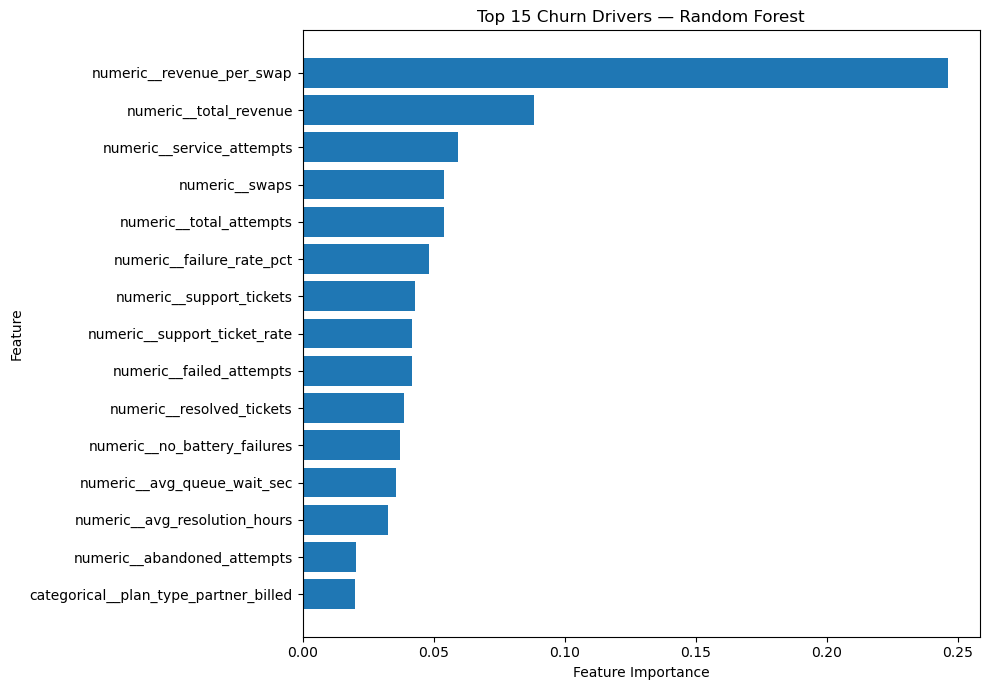

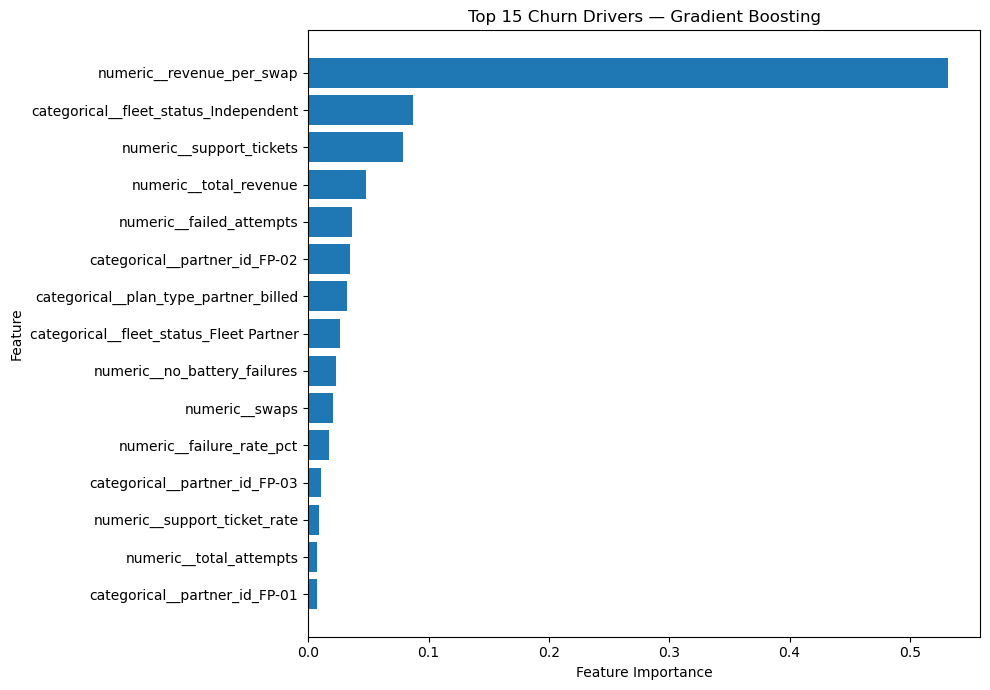



STEP 42 COMPLETE


In [101]:
# ============================================================
# STEP 42 — FEATURE IMPORTANCE / CHURN DRIVERS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 100)
print("STEP 42 — FEATURE IMPORTANCE / CHURN DRIVERS")
print("=" * 100)


# ------------------------------------------------------------
# 1. GET FEATURE NAMES
# ------------------------------------------------------------

feature_names = preprocessor.get_feature_names_out()

print("\nTotal processed features:", len(feature_names))


# ------------------------------------------------------------
# 2. RANDOM FOREST FEATURE IMPORTANCE
# ------------------------------------------------------------

rf_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    "importance",
    ascending=False
).reset_index(drop=True)


print("\nRANDOM FOREST — TOP 20 CHURN DRIVERS")
print("-" * 100)

display(
    rf_importance.head(20)
)


# ------------------------------------------------------------
# 3. GRADIENT BOOSTING FEATURE IMPORTANCE
# ------------------------------------------------------------

gb_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": gb_model.feature_importances_
})

gb_importance = gb_importance.sort_values(
    "importance",
    ascending=False
).reset_index(drop=True)


print("\nGRADIENT BOOSTING — TOP 20 CHURN DRIVERS")
print("-" * 100)

display(
    gb_importance.head(20)
)


# ------------------------------------------------------------
# 4. LOGISTIC REGRESSION COEFFICIENTS
# ------------------------------------------------------------

lr_coefficients = pd.DataFrame({
    "feature": feature_names,
    "coefficient": logistic_model.coef_[0]
})

lr_coefficients["abs_coefficient"] = (
    lr_coefficients["coefficient"].abs()
)

lr_coefficients = lr_coefficients.sort_values(
    "abs_coefficient",
    ascending=False
).reset_index(drop=True)


print("\nLOGISTIC REGRESSION — STRONGEST FEATURES")
print("-" * 100)

display(
    lr_coefficients.head(20)
)


# ------------------------------------------------------------
# 5. PLOT RANDOM FOREST TOP 15
# ------------------------------------------------------------

top_rf = rf_importance.head(15).sort_values(
    "importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_rf["feature"],
    top_rf["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Churn Drivers — Random Forest")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6. PLOT GRADIENT BOOSTING TOP 15
# ------------------------------------------------------------

top_gb = gb_importance.head(15).sort_values(
    "importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_gb["feature"],
    top_gb["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Churn Drivers — Gradient Boosting")

plt.tight_layout()
plt.show()


print("\n")
print("STEP 42 COMPLETE")
print("=" * 100)

In [103]:
# ============================================================
# STEP 43 — CHURN RISK SCORING
# ============================================================

import pandas as pd
import numpy as np

print("=" * 100)
print("STEP 43 — CHURN RISK SCORING")
print("=" * 100)


# ------------------------------------------------------------
# 1. GENERATE CHURN PROBABILITIES
# ------------------------------------------------------------

gb_churn_probability = gb_model.predict_proba(
    X_test_processed
)[:, 1]


# ------------------------------------------------------------
# 2. CREATE RISK DATAFRAME
# ------------------------------------------------------------

risk_df = X_test.copy()

risk_df = risk_df.reset_index(drop=True)

risk_df["churn_probability"] = gb_churn_probability


# ------------------------------------------------------------
# 3. CREATE RISK BANDS
# ------------------------------------------------------------

risk_df["risk_band"] = pd.cut(
    risk_df["churn_probability"],
    bins=[-0.01, 0.30, 0.60, 1.00],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)


# ------------------------------------------------------------
# 4. RISK DISTRIBUTION
# ------------------------------------------------------------

print("\nCHURN RISK DISTRIBUTION")
print("-" * 100)

risk_summary = (
    risk_df["risk_band"]
    .value_counts()
    .sort_index()
    .reset_index()
)

risk_summary.columns = [
    "risk_band",
    "riders"
]

risk_summary["percentage"] = (
    risk_summary["riders"] /
    len(risk_df) * 100
).round(2)

display(risk_summary)


# ------------------------------------------------------------
# 5. PROBABILITY SUMMARY
# ------------------------------------------------------------

print("\nCHURN PROBABILITY SUMMARY")
print("-" * 100)

print(
    risk_df["churn_probability"].describe()
)


# ------------------------------------------------------------
# 6. HIGH-RISK RIDERS
# ------------------------------------------------------------

print("\nTOP 20 HIGH-RISK RIDERS")
print("-" * 100)

high_risk = (
    risk_df
    .sort_values(
        "churn_probability",
        ascending=False
    )
    .head(20)
)

display(
    high_risk[
        [
            "churn_probability",
            "risk_band"
        ]
    ]
)


# ------------------------------------------------------------
# 7. HIGH-RISK SUMMARY
# ------------------------------------------------------------

high_risk_count = (
    risk_df["risk_band"] == "High Risk"
).sum()

print(
    f"\nHigh-risk riders: {high_risk_count}"
)

print(
    f"High-risk percentage: "
    f"{high_risk_count / len(risk_df) * 100:.2f}%"
)


print("\n")
print("STEP 43 COMPLETE")
print("=" * 100)

STEP 43 — CHURN RISK SCORING

CHURN RISK DISTRIBUTION
----------------------------------------------------------------------------------------------------


,risk_band,riders,percentage
0,Low Risk,2262,56.69
1,Medium Risk,1072,26.87
2,High Risk,656,16.44



CHURN PROBABILITY SUMMARY
----------------------------------------------------------------------------------------------------
count    3990.000000
mean        0.339450
std         0.260751
min         0.021684
25%         0.146440
50%         0.269190
75%         0.414435
max         0.978019
Name: churn_probability, dtype: float64

TOP 20 HIGH-RISK RIDERS
----------------------------------------------------------------------------------------------------


,churn_probability,risk_band
2398,0.978019,High Risk
400,0.977791,High Risk
3965,0.977648,High Risk
1858,0.976696,High Risk
1559,0.976696,High Risk
1786,0.976696,High Risk
671,0.976470,High Risk
730,0.976470,High Risk
1088,0.976447,High Risk
954,0.976273,High Risk



High-risk riders: 656
High-risk percentage: 16.44%


STEP 43 COMPLETE


In [107]:
# ====================================================================================================
# STEP 44 — HIGH-RISK RIDER IDENTIFICATION
# ====================================================================================================

import pandas as pd
import numpy as np

print("=" * 100)
print("STEP 44 — HIGH-RISK RIDER IDENTIFICATION")
print("=" * 100)

# ------------------------------------------------------------
# 1. GET RIDER IDs USING ORIGINAL MODEL DATA
# ------------------------------------------------------------
# model_data still contains rider_id.
# X_test retains the original row indices from the train/test split.

test_rider_ids = model_data.loc[X_test.index, "rider_id"].reset_index(drop=True)

# ------------------------------------------------------------
# 2. CREATE RISK TABLE
# ------------------------------------------------------------

risk_riders = pd.DataFrame({
    "rider_id": test_rider_ids,
    "churn_probability": gb_churn_probability
})

# ------------------------------------------------------------
# 3. ASSIGN RISK BAND
# ------------------------------------------------------------

risk_riders["risk_band"] = pd.cut(
    risk_riders["churn_probability"],
    bins=[-0.01, 0.30, 0.60, 1.00],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

# ------------------------------------------------------------
# 4. GET RIDER FEATURES FROM MODEL DATA
# ------------------------------------------------------------

rider_features = model_data[
    [
        "rider_id",
        "total_attempts",
        "failure_rate_pct",
        "avg_queue_wait_sec",
        "support_tickets",
        "unresolved_tickets",
        "high_priority_tickets",
        "swaps",
        "total_revenue",
        "vehicle_class",
        "plan_type",
        "fleet_status"
    ]
].copy()

# ------------------------------------------------------------
# 5. CALCULATE DERIVED FEATURES
# ------------------------------------------------------------

rider_features["revenue_per_swap"] = (
    rider_features["total_revenue"] /
    rider_features["swaps"].replace(0, np.nan)
)

rider_features["support_ticket_rate"] = (
    rider_features["support_tickets"] /
    rider_features["total_attempts"].replace(0, np.nan)
)

# ------------------------------------------------------------
# 6. MERGE FEATURES WITH RISK SCORES
# ------------------------------------------------------------

risk_riders = risk_riders.merge(
    rider_features,
    on="rider_id",
    how="left"
)

# ------------------------------------------------------------
# 7. SORT BY CHURN PROBABILITY
# ------------------------------------------------------------

risk_riders = risk_riders.sort_values(
    "churn_probability",
    ascending=False
).reset_index(drop=True)

# ------------------------------------------------------------
# 8. DISPLAY HIGH-RISK RIDERS
# ------------------------------------------------------------

high_risk_riders = risk_riders[
    risk_riders["risk_band"] == "High Risk"
].copy()

print("\nHIGH-RISK RIDER SUMMARY")
print("-" * 100)

print(f"Total test riders: {len(risk_riders)}")
print(f"High-risk riders: {len(high_risk_riders)}")
print(
    f"High-risk percentage: "
    f"{len(high_risk_riders) / len(risk_riders) * 100:.2f}%"
)

print("\nTOP 20 HIGH-RISK RIDERS")
print("-" * 100)

print(
    high_risk_riders[
        [
            "rider_id",
            "churn_probability",
            "risk_band",
            "failure_rate_pct",
            "avg_queue_wait_sec",
            "support_tickets",
            "unresolved_tickets",
            "swaps",
            "total_revenue",
            "revenue_per_swap",
            "vehicle_class",
            "plan_type",
            "fleet_status"
        ]
    ].head(20).to_string(index=False)
)

print("\nSTEP 44 COMPLETE")
print("=" * 100)

STEP 44 — HIGH-RISK RIDER IDENTIFICATION

HIGH-RISK RIDER SUMMARY
----------------------------------------------------------------------------------------------------
Total test riders: 3990
High-risk riders: 656
High-risk percentage: 16.44%

TOP 20 HIGH-RISK RIDERS
----------------------------------------------------------------------------------------------------
  rider_id  churn_probability risk_band  failure_rate_pct  avg_queue_wait_sec  support_tickets  unresolved_tickets  swaps  total_revenue  revenue_per_swap vehicle_class      plan_type  fleet_status
RD-1001341           0.978019 High Risk          3.937008          256.897638              1.0                 0.0  122.0         6588.0         54.000000            2W partner_billed Fleet Partner
RD-1004232           0.977791 High Risk          4.950495          241.613861              NaN                 NaN   96.0         5184.0         54.000000            2W partner_billed Fleet Partner
RD-1003756           0.977648 High Ris

In [108]:
# ====================================================================================================
# STEP 45 — HIGH-RISK RIDER PROFILING
# ====================================================================================================

import pandas as pd
import numpy as np

print("=" * 100)
print("STEP 45 — HIGH-RISK RIDER PROFILING")
print("=" * 100)

# ------------------------------------------------------------
# 1. HIGH-RISK RIDERS
# ------------------------------------------------------------

high_risk = risk_riders[
    risk_riders["risk_band"] == "High Risk"
].copy()

print("\nHIGH-RISK RIDER COUNT")
print("-" * 100)
print(f"High-risk riders: {len(high_risk)}")

# ------------------------------------------------------------
# 2. NUMERIC PROFILE
# ------------------------------------------------------------

numeric_profile_cols = [
    "churn_probability",
    "failure_rate_pct",
    "avg_queue_wait_sec",
    "support_tickets",
    "unresolved_tickets",
    "high_priority_tickets",
    "swaps",
    "total_revenue",
    "revenue_per_swap"
]

print("\nHIGH-RISK RIDER NUMERIC PROFILE")
print("-" * 100)

high_risk_numeric = high_risk[numeric_profile_cols].describe().T

print(high_risk_numeric.to_string())

# ------------------------------------------------------------
# 3. HIGH-RISK BY VEHICLE CLASS
# ------------------------------------------------------------

print("\nHIGH-RISK BY VEHICLE CLASS")
print("-" * 100)

vehicle_risk = (
    high_risk
    .groupby("vehicle_class", dropna=False)
    .agg(
        high_risk_riders=("rider_id", "count"),
        avg_churn_probability=("churn_probability", "mean"),
        avg_failure_rate=("failure_rate_pct", "mean"),
        avg_queue_wait_sec=("avg_queue_wait_sec", "mean"),
        avg_revenue=("total_revenue", "mean")
    )
    .reset_index()
)

vehicle_risk["risk_share_pct"] = (
    vehicle_risk["high_risk_riders"] /
    len(high_risk) * 100
)

print(vehicle_risk.to_string(index=False))

# ------------------------------------------------------------
# 4. HIGH-RISK BY PLAN TYPE
# ------------------------------------------------------------

print("\nHIGH-RISK BY PLAN TYPE")
print("-" * 100)

plan_risk = (
    high_risk
    .groupby("plan_type", dropna=False)
    .agg(
        high_risk_riders=("rider_id", "count"),
        avg_churn_probability=("churn_probability", "mean"),
        avg_failure_rate=("failure_rate_pct", "mean"),
        avg_support_tickets=("support_tickets", "mean"),
        avg_revenue=("total_revenue", "mean")
    )
    .reset_index()
)

plan_risk["risk_share_pct"] = (
    plan_risk["high_risk_riders"] /
    len(high_risk) * 100
)

print(plan_risk.to_string(index=False))

# ------------------------------------------------------------
# 5. HIGH-RISK BY FLEET STATUS
# ------------------------------------------------------------

print("\nHIGH-RISK BY FLEET STATUS")
print("-" * 100)

fleet_risk = (
    high_risk
    .groupby("fleet_status", dropna=False)
    .agg(
        high_risk_riders=("rider_id", "count"),
        avg_churn_probability=("churn_probability", "mean"),
        avg_failure_rate=("failure_rate_pct", "mean"),
        avg_queue_wait_sec=("avg_queue_wait_sec", "mean"),
        avg_revenue=("total_revenue", "mean")
    )
    .reset_index()
)

fleet_risk["risk_share_pct"] = (
    fleet_risk["high_risk_riders"] /
    len(high_risk) * 100
)

print(fleet_risk.to_string(index=False))

# ------------------------------------------------------------
# 6. HIGH-RISK BY PARTNER
# ------------------------------------------------------------

print("\nHIGH-RISK BY FLEET PARTNER")
print("-" * 100)

partner_risk = (
    high_risk
    .groupby("fleet_status", dropna=False)
    .size()
)

# Only analyze actual partner IDs where available
partner_column = "partner_id"

if partner_column in high_risk.columns:

    partner_risk = (
        high_risk
        .groupby(partner_column, dropna=False)
        .agg(
            high_risk_riders=("rider_id", "count"),
            avg_churn_probability=("churn_probability", "mean"),
            avg_failure_rate=("failure_rate_pct", "mean"),
            avg_revenue=("total_revenue", "mean")
        )
        .reset_index()
        .sort_values("high_risk_riders", ascending=False)
    )

    partner_risk["risk_share_pct"] = (
        partner_risk["high_risk_riders"] /
        len(high_risk) * 100
    )

    print(partner_risk.to_string(index=False))

# ------------------------------------------------------------
# 7. REVENUE AT RISK
# ------------------------------------------------------------

print("\nHIGH-RISK REVENUE AT RISK")
print("-" * 100)

high_risk_revenue = high_risk["total_revenue"].sum()
total_test_revenue = risk_riders["total_revenue"].sum()

revenue_at_risk_pct = (
    high_risk_revenue /
    total_test_revenue * 100
)

print(f"High-risk rider revenue: ₹{high_risk_revenue:,.2f}")
print(f"Test-set rider revenue:   ₹{total_test_revenue:,.2f}")
print(f"Revenue represented by high-risk riders: {revenue_at_risk_pct:.2f}%")

# ------------------------------------------------------------
# 8. TOP HIGH-RISK RIDERS BY REVENUE
# ------------------------------------------------------------

print("\nTOP 20 HIGH-RISK RIDERS BY REVENUE")
print("-" * 100)

top_revenue_risk = (
    high_risk
    .sort_values("total_revenue", ascending=False)
    [
        [
            "rider_id",
            "churn_probability",
            "total_revenue",
            "swaps",
            "failure_rate_pct",
            "avg_queue_wait_sec",
            "support_tickets",
            "vehicle_class",
            "plan_type",
            "fleet_status"
        ]
    ]
    .head(20)
)

print(top_revenue_risk.to_string(index=False))

# ------------------------------------------------------------
# 9. SAVE STEP 45 OUTPUTS FOR LATER STEPS
# ------------------------------------------------------------

step45_high_risk = high_risk.copy()
step45_vehicle_risk = vehicle_risk.copy()
step45_plan_risk = plan_risk.copy()
step45_fleet_risk = fleet_risk.copy()
step45_partner_risk = partner_risk.copy()
step45_top_revenue_risk = top_revenue_risk.copy()

print("\nSTEP 45 COMPLETE")
print("=" * 100)

STEP 45 — HIGH-RISK RIDER PROFILING

HIGH-RISK RIDER COUNT
----------------------------------------------------------------------------------------------------
High-risk riders: 656

HIGH-RISK RIDER NUMERIC PROFILE
----------------------------------------------------------------------------------------------------
                       count         mean          std        min          25%          50%           75%           max
churn_probability      656.0     0.854271     0.106626   0.600786     0.768174     0.893157      0.947372      0.978019
failure_rate_pct       656.0     6.358037     5.667745   0.000000     3.182186     5.139860      7.826087     50.000000
avg_queue_wait_sec     656.0   242.221699    28.352679  72.000000   230.993304   241.706410    251.938967    456.000000
support_tickets        353.0     2.005666     1.383741   1.000000     1.000000     1.000000      3.000000      8.000000
unresolved_tickets     353.0     0.240793     0.472339   0.000000     0.000000     0

In [109]:
# ====================================================================================================
# STEP 46 — HIGH-RISK SEGMENT ANALYSIS
# ====================================================================================================

import pandas as pd
import numpy as np

print("=" * 100)
print("STEP 46 — HIGH-RISK SEGMENT ANALYSIS")
print("=" * 100)

# ------------------------------------------------------------
# 1. VEHICLE × PLAN SEGMENT
# ------------------------------------------------------------

print("\nHIGH-RISK RIDERS BY VEHICLE CLASS × PLAN TYPE")
print("-" * 100)

vehicle_plan_risk = (
    step45_high_risk
    .groupby(
        ["vehicle_class", "plan_type"],
        dropna=False
    )
    .agg(
        high_risk_riders=("rider_id", "count"),
        avg_churn_probability=("churn_probability", "mean"),
        avg_failure_rate=("failure_rate_pct", "mean"),
        avg_queue_wait_sec=("avg_queue_wait_sec", "mean"),
        total_revenue=("total_revenue", "sum"),
        avg_revenue=("total_revenue", "mean")
    )
    .reset_index()
)

vehicle_plan_risk["risk_share_pct"] = (
    vehicle_plan_risk["high_risk_riders"] /
    len(step45_high_risk) * 100
)

vehicle_plan_risk = vehicle_plan_risk.sort_values(
    "high_risk_riders",
    ascending=False
)

print(vehicle_plan_risk.to_string(index=False))

# ------------------------------------------------------------
# 2. VEHICLE × FLEET STATUS
# ------------------------------------------------------------

print("\nHIGH-RISK RIDERS BY VEHICLE CLASS × FLEET STATUS")
print("-" * 100)

vehicle_fleet_risk = (
    step45_high_risk
    .groupby(
        ["vehicle_class", "fleet_status"],
        dropna=False
    )
    .agg(
        high_risk_riders=("rider_id", "count"),
        avg_churn_probability=("churn_probability", "mean"),
        avg_failure_rate=("failure_rate_pct", "mean"),
        avg_queue_wait_sec=("avg_queue_wait_sec", "mean"),
        total_revenue=("total_revenue", "sum"),
        avg_revenue=("total_revenue", "mean")
    )
    .reset_index()
)

vehicle_fleet_risk["risk_share_pct"] = (
    vehicle_fleet_risk["high_risk_riders"] /
    len(step45_high_risk) * 100
)

vehicle_fleet_risk = vehicle_fleet_risk.sort_values(
    "high_risk_riders",
    ascending=False
)

print(vehicle_fleet_risk.to_string(index=False))

# ------------------------------------------------------------
# 3. PLAN × FLEET STATUS
# ------------------------------------------------------------

print("\nHIGH-RISK RIDERS BY PLAN TYPE × FLEET STATUS")
print("-" * 100)

plan_fleet_risk = (
    step45_high_risk
    .groupby(
        ["plan_type", "fleet_status"],
        dropna=False
    )
    .agg(
        high_risk_riders=("rider_id", "count"),
        avg_churn_probability=("churn_probability", "mean"),
        avg_failure_rate=("failure_rate_pct", "mean"),
        avg_queue_wait_sec=("avg_queue_wait_sec", "mean"),
        total_revenue=("total_revenue", "sum"),
        avg_revenue=("total_revenue", "mean")
    )
    .reset_index()
)

plan_fleet_risk["risk_share_pct"] = (
    plan_fleet_risk["high_risk_riders"] /
    len(step45_high_risk) * 100
)

plan_fleet_risk = plan_fleet_risk.sort_values(
    "high_risk_riders",
    ascending=False
)

print(plan_fleet_risk.to_string(index=False))

# ------------------------------------------------------------
# 4. REVENUE CONCENTRATION BY SEGMENT
# ------------------------------------------------------------

print("\nHIGH-RISK REVENUE BY VEHICLE CLASS")
print("-" * 100)

vehicle_revenue = (
    step45_high_risk
    .groupby("vehicle_class", dropna=False)
    .agg(
        high_risk_riders=("rider_id", "count"),
        total_revenue=("total_revenue", "sum")
    )
    .reset_index()
)

vehicle_revenue["revenue_share_pct"] = (
    vehicle_revenue["total_revenue"] /
    step45_high_risk["total_revenue"].sum() * 100
)

print(vehicle_revenue.to_string(index=False))

print("\nHIGH-RISK REVENUE BY PLAN TYPE")
print("-" * 100)

plan_revenue = (
    step45_high_risk
    .groupby("plan_type", dropna=False)
    .agg(
        high_risk_riders=("rider_id", "count"),
        total_revenue=("total_revenue", "sum")
    )
    .reset_index()
)

plan_revenue["revenue_share_pct"] = (
    plan_revenue["total_revenue"] /
    step45_high_risk["total_revenue"].sum() * 100
)

print(plan_revenue.to_string(index=False))

# ------------------------------------------------------------
# 5. HIGH-RISK RIDERS WITH BOTH HIGH REVENUE AND HIGH RISK
# ------------------------------------------------------------

print("\nHIGH-RISK + HIGH-REVENUE RIDERS")
print("-" * 100)

revenue_threshold = step45_high_risk["total_revenue"].quantile(0.75)

high_value_high_risk = step45_high_risk[
    step45_high_risk["total_revenue"] >= revenue_threshold
].copy()

print(f"High-revenue threshold: ₹{revenue_threshold:,.2f}")
print(f"High-risk + high-revenue riders: {len(high_value_high_risk)}")
print(
    f"Revenue represented: "
    f"₹{high_value_high_risk['total_revenue'].sum():,.2f}"
)

# ------------------------------------------------------------
# 6. TOP SEGMENTS BY REVENUE
# ------------------------------------------------------------

print("\nTOP SEGMENTS BY HIGH-RISK REVENUE")
print("-" * 100)

segment_revenue = (
    step45_high_risk
    .groupby(
        ["vehicle_class", "plan_type", "fleet_status"],
        dropna=False
    )
    .agg(
        high_risk_riders=("rider_id", "count"),
        total_revenue=("total_revenue", "sum"),
        avg_churn_probability=("churn_probability", "mean"),
        avg_failure_rate=("failure_rate_pct", "mean")
    )
    .reset_index()
    .sort_values("total_revenue", ascending=False)
)

segment_revenue["revenue_share_pct"] = (
    segment_revenue["total_revenue"] /
    step45_high_risk["total_revenue"].sum() * 100
)

print(segment_revenue.to_string(index=False))

# ------------------------------------------------------------
# 7. SAVE STEP 46 OUTPUTS
# ------------------------------------------------------------

step46_vehicle_plan = vehicle_plan_risk.copy()
step46_vehicle_fleet = vehicle_fleet_risk.copy()
step46_plan_fleet = plan_fleet_risk.copy()
step46_vehicle_revenue = vehicle_revenue.copy()
step46_plan_revenue = plan_revenue.copy()
step46_high_value_high_risk = high_value_high_risk.copy()
step46_segment_revenue = segment_revenue.copy()

print("\nSTEP 46 COMPLETE")
print("=" * 100)

STEP 46 — HIGH-RISK SEGMENT ANALYSIS

HIGH-RISK RIDERS BY VEHICLE CLASS × PLAN TYPE
----------------------------------------------------------------------------------------------------
vehicle_class      plan_type  high_risk_riders  avg_churn_probability  avg_failure_rate  avg_queue_wait_sec  total_revenue  avg_revenue  risk_share_pct
           2W partner_billed               359               0.864993          5.658716          241.555214      2796182.1  7788.808078       54.725610
           2W  pay_as_you_go               149               0.882701          5.687082          241.574974      1004387.0  6740.852349       22.713415
           3W partner_billed                73               0.739154         10.498583          241.726124       462307.6  6332.980822       11.128049
           2W   prepaid_pack                71               0.868583          6.469783          244.071199       509557.0  7176.859155       10.823171
           3W  pay_as_you_go                 3         

In [110]:
# ====================================================================================================
# STEP 47 — REVENUE AT RISK ANALYSIS
# ====================================================================================================

import pandas as pd
import numpy as np

print("=" * 100)
print("STEP 47 — REVENUE AT RISK ANALYSIS")
print("=" * 100)

# ------------------------------------------------------------
# 1. TOTAL REVENUE EXPOSURE
# ------------------------------------------------------------

total_high_risk_revenue = step45_high_risk["total_revenue"].sum()
total_test_revenue = risk_riders["total_revenue"].sum()

print("\nTOTAL HIGH-RISK REVENUE EXPOSURE")
print("-" * 100)

print(f"High-risk riders: {len(step45_high_risk):,}")
print(f"High-risk revenue: ₹{total_high_risk_revenue:,.2f}")
print(f"Total test-set revenue: ₹{total_test_revenue:,.2f}")

print(
    f"High-risk revenue share: "
    f"{total_high_risk_revenue / total_test_revenue * 100:.2f}%"
)

print(
    f"Average revenue per high-risk rider: "
    f"₹{step45_high_risk['total_revenue'].mean():,.2f}"
)

# ------------------------------------------------------------
# 2. REVENUE BANDS
# ------------------------------------------------------------

print("\nHIGH-RISK RIDERS BY REVENUE BAND")
print("-" * 100)

revenue_bins = [
    -np.inf,
    5000,
    10000,
    15000,
    20000,
    np.inf
]

revenue_labels = [
    "Below ₹5K",
    "₹5K–₹10K",
    "₹10K–₹15K",
    "₹15K–₹20K",
    "Above ₹20K"
]

step47_revenue = step45_high_risk.copy()

step47_revenue["revenue_band"] = pd.cut(
    step47_revenue["total_revenue"],
    bins=revenue_bins,
    labels=revenue_labels
)

revenue_band_summary = (
    step47_revenue
    .groupby("revenue_band", observed=False)
    .agg(
        riders=("rider_id", "count"),
        total_revenue=("total_revenue", "sum"),
        avg_churn_probability=("churn_probability", "mean")
    )
    .reset_index()
)

revenue_band_summary["rider_share_pct"] = (
    revenue_band_summary["riders"] /
    len(step45_high_risk) * 100
)

revenue_band_summary["revenue_share_pct"] = (
    revenue_band_summary["total_revenue"] /
    total_high_risk_revenue * 100
)

print(revenue_band_summary.to_string(index=False))

# ------------------------------------------------------------
# 3. HIGH-RISK RIDERS ABOVE KEY REVENUE THRESHOLDS
# ------------------------------------------------------------

print("\nHIGH-RISK REVENUE THRESHOLDS")
print("-" * 100)

thresholds = [5000, 10000, 15000, 20000]

threshold_results = []

for threshold in thresholds:

    subset = step45_high_risk[
        step45_high_risk["total_revenue"] >= threshold
    ]

    threshold_results.append({
        "revenue_threshold": threshold,
        "riders": len(subset),
        "rider_share_pct": len(subset) / len(step45_high_risk) * 100,
        "revenue": subset["total_revenue"].sum(),
        "revenue_share_pct":
            subset["total_revenue"].sum() /
            total_high_risk_revenue * 100
    })

threshold_summary = pd.DataFrame(threshold_results)

print(threshold_summary.to_string(index=False))

# ------------------------------------------------------------
# 4. TOP 10% HIGH-RISK RIDERS BY REVENUE
# ------------------------------------------------------------

print("\nTOP 10% HIGH-RISK RIDERS BY REVENUE")
print("-" * 100)

revenue_90th = step45_high_risk["total_revenue"].quantile(0.90)

top_10_revenue_risk = step45_high_risk[
    step45_high_risk["total_revenue"] >= revenue_90th
].copy()

print(f"90th percentile revenue threshold: ₹{revenue_90th:,.2f}")
print(f"Riders: {len(top_10_revenue_risk)}")
print(
    f"Revenue represented: "
    f"₹{top_10_revenue_risk['total_revenue'].sum():,.2f}"
)
print(
    f"Share of high-risk revenue: "
    f"{top_10_revenue_risk['total_revenue'].sum() / total_high_risk_revenue * 100:.2f}%"
)

# ------------------------------------------------------------
# 5. TOP 20 HIGH-RISK RIDERS BY REVENUE
# ------------------------------------------------------------

print("\nTOP 20 HIGH-RISK RIDERS BY REVENUE")
print("-" * 100)

top20_revenue_risk = (
    step45_high_risk
    .sort_values("total_revenue", ascending=False)
    [[
        "rider_id",
        "churn_probability",
        "risk_band",
        "total_revenue",
        "swaps",
        "failure_rate_pct",
        "avg_queue_wait_sec",
        "vehicle_class",
        "plan_type",
        "fleet_status"
    ]]
    .head(20)
)

print(top20_revenue_risk.to_string(index=False))

# ------------------------------------------------------------
# 6. REVENUE × CHURN PROBABILITY
# ------------------------------------------------------------

print("\nHIGH-RISK REVENUE SEGMENTS")
print("-" * 100)

step47_revenue["risk_revenue_segment"] = np.select(
    [
        (
            step47_revenue["churn_probability"] >= 0.80
        ) &
        (
            step47_revenue["total_revenue"] >= revenue_90th
        ),

        (
            step47_revenue["churn_probability"] >= 0.80
        ) &
        (
            step47_revenue["total_revenue"] < revenue_90th
        )
    ],
    [
        "Very High Risk + High Revenue",
        "Very High Risk + Lower Revenue"
    ],
    default="High Risk + Lower Probability"
)

risk_revenue_summary = (
    step47_revenue
    .groupby("risk_revenue_segment")
    .agg(
        riders=("rider_id", "count"),
        total_revenue=("total_revenue", "sum"),
        avg_revenue=("total_revenue", "mean"),
        avg_churn_probability=("churn_probability", "mean")
    )
    .reset_index()
)

risk_revenue_summary["revenue_share_pct"] = (
    risk_revenue_summary["total_revenue"] /
    total_high_risk_revenue * 100
)

print(risk_revenue_summary.to_string(index=False))

# ------------------------------------------------------------
# 7. SAVE STEP 47 OUTPUTS
# ------------------------------------------------------------

step47_revenue_band_summary = revenue_band_summary.copy()
step47_threshold_summary = threshold_summary.copy()
step47_top10_revenue_risk = top_10_revenue_risk.copy()
step47_top20_revenue_risk = top20_revenue_risk.copy()
step47_risk_revenue_summary = risk_revenue_summary.copy()

print("\nSTEP 47 COMPLETE")
print("=" * 100)

STEP 47 — REVENUE AT RISK ANALYSIS

TOTAL HIGH-RISK REVENUE EXPOSURE
----------------------------------------------------------------------------------------------------
High-risk riders: 656
High-risk revenue: ₹4,779,133.70
Total test-set revenue: ₹45,916,065.75
High-risk revenue share: 10.41%
Average revenue per high-risk rider: ₹7,285.26

HIGH-RISK RIDERS BY REVENUE BAND
----------------------------------------------------------------------------------------------------
revenue_band  riders  total_revenue  avg_churn_probability  rider_share_pct  revenue_share_pct
   Below ₹5K     292      662388.45               0.888420        44.512195          13.860011
    ₹5K–₹10K     175     1288218.95               0.863389        26.676829          26.955072
   ₹10K–₹15K     116     1433230.15               0.826769        17.682927          29.989329
   ₹15K–₹20K      50      867614.65               0.765116         7.621951          18.154224
  Above ₹20K      23      527681.50            